## MENG 21200 Repository

## External Links:

- https://www.python.org
- https://matplotlib.org
- https://scipy.org
- https://numpy.org

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
import math
from scipy import special
from scipy.stats import linregress
from scipy.optimize import curve_fit
from scipy.interpolate import CubicSpline
from scipy.optimize import linprog
from scipy.integrate import solve_ivp
from scipy.integrate import solve_bvp


### Table of Contents:

## Navigation
- [Debugging Help](#debugging-checklist)
- [Essential Terms](#essential-terms-and-identifiable-characteristics)

### Core Methods

- [Numerical Differentiation Methods](#numerical-differentiation-methods)
- [Richardson Extrapolation](#richardson-extrapolation)
- [Ch. 17 - Linear Regression](#linearleast-squares-regression)
- [Ch.4 - Truncation Errors and Taylor Series](#truncation-errors-and-taylor-series-ch-4---error-comparisons)
- [Ch.5 - Bracketing Methods(Bisection, FP)](#bracketing-methods-ch-5---bisectionfalse-position-methods)
- [Ch.6 - Open Methods (N-R, Secant, Fixed-Point)](#open-root-finding-methods-ch-6---newton-raphsonsecantfixed-point-iteration-methods)
- [Ch.18 - Interpolation (Newton/Lagrange, Splines)](#interpolation---ch18)
- [Ch.21/Ch.22 - Numerical Integration (N-C, Simpson, Trapezoidal, Romberg, Guass Quadrature)](#numerical-integration----ch2122)
- [Ch.25 - IVPs and Solving Systems of Equations](#solving-initial-value-problems-ivps---ch25)
- [Ch.26 - Stiffness (Non-Self-Strating Heun, Explicit vs Implicit)](#stiffness-and-multistep-methods---ch26)
- [Solving BVPs](#solving-boundary-value-problems-bvps)
- [Ch.9 - Solving Systems of Linear Equations](#solving-systems-of-linear-equations----ch9)
- [Ch.13/Ch.14 - Unconstrained Optimization](#optimization-methods-unconstrained-optimization----ch1314)
- [Ch.15 - Linear Programming/Constrained Optimization](#linear-programming-constrained-optimization----ch15)
- [Contour Plots](#contour-plots)

### Practice

- [Previous PSET Problems](#previous-psets)
- [Textbook Practice Problems](#practice-problems)
- [Doing Methods By Hand](#methods-by-hand)




<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

$$\textbf{Review Chapters: Ch.4 (Truncation Errors and the Taylor Series),}$$ $$\textbf{Ch.5 (Bracketing Methods), Ch.6 (Open Methods), Ch.17 (Least Squares Regression), Ch.23 (Numerical Differentiation).}$$

<a id="numerical-differentiation"></a>
## Numerical Differentiation Methods

In [5]:
# Example Function: 
def f(x):
    f = -((7*np.cos(x))/ x) + np.log(x)
    return(f)

def f_prime(x):
    f_prime = (7*x * np.sin(x) + 7 * np.cos(x) + x) / x**2
    return(f_prime)
# ------------------------------------------------------------------

# First Order Forward FDD Formula - Error = O(dx)
# Approximation for first derivative
def first_FFD(f, x, dx):
    ffd1 = (f(x + dx) - f(x)) / (dx)
    return(ffd1)

# Second Order Forward FDD Formula - Error = O(dx^2)
# Approximation for first derivative
def second_FFD(f, x, dx):
    ffd2 = (-f(x + 2*dx) + 4*f(x + dx) - 3*f(x)) / (2*dx)
    return(ffd2)

# SECOND DERIVATIVES

# First Order Forward FDD Formula - Error = O(dx)
# Approximation for second derivative
def first_FFD2(f, x, dx):
    ffd_order1_deriv2 = (f(x + 2*dx) - 2*f(x + dx) + f(x)) / (dx**2)
    return(ffd_order1_deriv2)

# Second Order Forward FDD Formula - Error = O(dx^2)
# Approximation for second derivative
def second_FFD2(f, x, dx):
    ffd_order2_deriv2 = (-f(x + 3*dx) + 4*f(x + 2*dx) - 5*f(x + dx) + 2*f(x)) / (dx**2)
    return(ffd_order2_deriv2)


# ------------------------------------------------------------------


# First Order Backward FDD Formula - Error = O(dx)
# Approximation for first derivative
def first_BFD(f, x, dx):
    bfd1 = (f(x) - f(x - dx)) / (dx)
    return(bfd1)

# Second Order Backward FDD Formula - Error = O(dx^2)
# Approximation for first derivative
def second_BFD(f, x, dx):
    bfd2 = (3*f(x) - 4*f(x - dx) + f(x - 2*dx)) / (2*dx)
    return(bfd2)

# SECOND DERIVATIVE

# First Order Backward FDD Formula - Error = O(dx)
# Approximation for second derivative
def first_BFD2(f, x, dx):
    bfd_order1_deriv2 = (f(x) - 2*f(x - dx) + f(x-2*dx)) / (dx**2)
    return(bfd_order1_deriv2)


# ------------------------------------------------------------------


# Second Order Center FDD Formula - Error = O(dx^2)
# Approximation for first derivative
def second_CFD1(f, x, dx):
    cfd2 = (f(x + dx) - f(x - dx)) / (2*dx)
    return(cfd2)

# Fourth Order Center FDD Formula - Error = O(dx^4)
# Approximation for first derivative
def fourth_CFD1(f, x, dx):
    cfd4 = (-1*f(x + 2*dx) + 8*f(x + dx) - 8* f(x - dx) + f(x - 2*dx)) / (12*dx)
    return(cfd4)

# SECOND DERIVATIVE

# Second Order Center FDD Formula - Error = O(dx^2)
# Approximation for second derivative
def second_CFD2(f, x, dx):
    cfd_order2_deriv2 = (f(x + dx) - 2*f(x) + f(x - dx)) / (dx**2)
    return(cfd_order2_deriv2)

Array Slicing Form:

In [6]:
# ------------------------------------------------------------------
# When given a list of experimental values rather than a function, the derivatives can be approximated through array slicing.
# ------------------------------------------------------------------

# IMPORTANT: deriv1_forward and deriv1_backward,
# as well as deriv2_forward and deriv2_backward
# both use the same stencil. 
# *Difference comes from the x-location they start at.

# FORWARD METHOD: -------------------------------------------------------------------

# First Derivative, First Order (O(h) error)
def deriv1_forward(x, y):
    h = x[1] - x[0] #stepsize
    x_dydx = x[:-1] # Forward method lives on all x values except the last one
    # (f(x_i+1) - f(x_i))/h
    return ((y[1:] - y[:-1]) / h)

# Second Derivative, First Order (O(h) error)
def deriv2_forward(x, y):
    h = x[1] - x[0] #stepsize
    x_d2ydx2 = x[:-1] # Forward method lives on all x values except the last one
    # (f(x_i+2) - 2*f(x_i+1) + f(x_i))/h^2
    return ((y[2:] - 2*y[1:-1] + y[:-2]) / h**2)


# BACKWARD METHOD -------------------------------------------------------------------


# First Derivative, First Order (O(h) error)
def deriv1_backward(x, y):
    h = x[1] - x[0] #stepsize
    x_dydx = x[1:] # Backward method lives on all x values except the first one
    # (f(x_i) - f(x_i-1))/h
    return ((y[1:] - y[:-1]) / h)

# Second Derivative, First Order (O(h) error)
def deriv2_backward(x, y):
    h = x[1] - x[0] #stepsize
    x_d2ydx2 = x[1:] # Backward method lives on all x values except the first one
    # (f(x_i) - 2*f(x_i-1) + f(x_i-2))/h^2
    return ((y[2:] - 2*y[1:-1] + y[:-2]) / h**2)


# CENTRAL METHOD -------------------------------------------------------------------


# First Derivative, Second Order (O(h^2) error)
def deriv1_central(x, y):
    h = x[1] - x[0] #stepsize
    x_dydx = x[1:-1] # Central Method lives on all x values except the first and last one
    # (f(x_i+1) - f(x_i-1))/2h
    return ((y[2:] - y[:-2]) / (2*h))

# Second Derivative, Second Order (O(h^2) error)
def deriv2_central(x, y):
    h = x[1] - x[0] #stepsize
    x_d2ydx2 = x[1:-1] # Central Method lives on all x values except the first and last one
    # (f(x_i+1) - 2f(x_i)+f(x_i-1))/h^2
    return ((y[2:] - 2*y[1:-1] + y[:-2]) / h**2)

Standard Finite Method Convergence Rates:

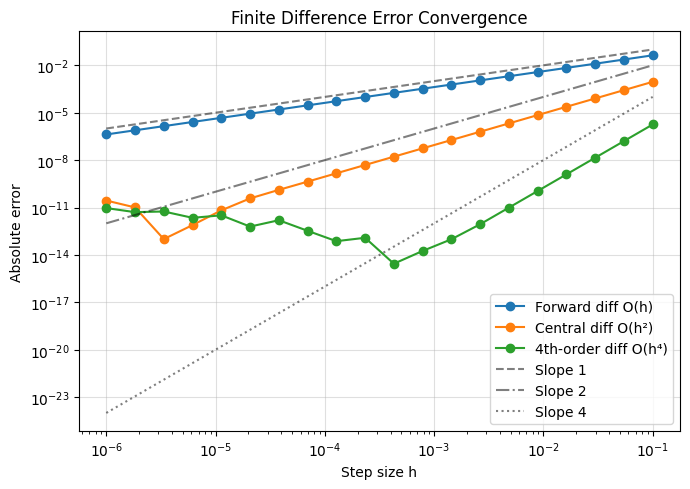

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Test function and exact derivative
def f(x):
    return np.sin(x)

def df_exact(x):
    return np.cos(x)

# Point where we differentiate
x0 = 1.0

# Step sizes
hs = np.logspace(-6, -1, 20)

# Error arrays
err_forward = []
err_central = []
err_fourth = []

for h in hs:
    # O(h): forward difference
    df_forward = (f(x0 + h) - f(x0)) / h

    # O(h^2): central difference
    df_central = (f(x0 + h) - f(x0 - h)) / (2 * h)

    # O(h^4): fourth-order central difference
    df_fourth = (-f(x0 + 2*h) + 8*f(x0 + h)
                 - 8*f(x0 - h) + f(x0 - 2*h)) / (12 * h)

    exact = df_exact(x0)

    err_forward.append(abs(df_forward - exact))
    err_central.append(abs(df_central - exact))
    err_fourth.append(abs(df_fourth - exact))

# Convert to arrays
err_forward = np.array(err_forward)
err_central = np.array(err_central)
err_fourth = np.array(err_fourth)

# Plot
plt.figure(figsize=(7,5))
plt.loglog(hs, err_forward, 'o-', label='Forward diff O(h)')
plt.loglog(hs, err_central, 'o-', label='Central diff O(h²)')
plt.loglog(hs, err_fourth, 'o-', label='4th-order diff O(h⁴)')

# Reference slopes
plt.loglog(hs, hs, 'k--', alpha=0.5, label='Slope 1')
plt.loglog(hs, hs**2, 'k-.', alpha=0.5, label='Slope 2')
plt.loglog(hs, hs**4, 'k:', alpha=0.5, label='Slope 4')

plt.xlabel('Step size h')
plt.ylabel('Absolute error')
plt.title('Finite Difference Error Convergence')
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

## Richardson Extrapolation
$$ D = D(h_2) + \frac{1}{(\frac{h_1}{h_2})^2 - 1} * [D(h_2) - D(h_1)] $$

$ \text{(For second order error)} $

In [8]:
# Example function and exact derivative
def f(x):
    return np.sin(x)

def df_exact(x):
    return np.cos(x)

# Second Order Center FDD Formula - Error = O(dx^2)
# Approximation for first derivative
def second_CFD1(f, x, dx):
    cfd2 = (f(x + dx) - f(x - dx)) / (2*dx)
    return(cfd2)

# Richardson-extrapolated derivative
def richardson_derivative(f, x, h):
    D_h = second_CFD1(f, x, h)
    D_h2 = second_CFD2(f, x, h / 2)
    return (4 * D_h2 - D_h) / 3

# ---- demonstration ----
x0 = 1.0
h = 1e-2

D2 = second_CFD2(f, x0, h)
D4 = richardson_derivative(f, x0, h)
exact = df_exact(x0)

print("Derivative estimates at x =", x0)
print(f"  Central difference (O(h^2)):      {D2:.10f}")
print(f"  Richardson extrapolated (O(h^4)): {D4:.10f}")
print(f"  Exact derivative:                 {exact:.10f}")

print("\nErrors:")
print(f"  Central diff error:      {abs(D2 - exact):.2e}")
print(f"  Richardson error:        {abs(D4 - exact):.2e}")


Derivative estimates at x = 1.0
  Central difference (O(h^2)):      -0.8414639726
  Richardson extrapolated (O(h^4)): -1.3020567426
  Exact derivative:                 0.5403023059

Errors:
  Central diff error:      1.38e+00
  Richardson error:        1.84e+00


<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

## Linear/Least Squares Regression

$$ a_1 = \frac{n \sum_{i=1}^{n} x_i y_i - \sum_{i=1}^{n} x_i \sum_{i=1}^{n} y_i}{n \sum_{i=1}^{n} x_i^2 - \left(\sum_{i=1}^{n} x_i\right)^2} $$

$$ a_0 = \bar{y} - a_1 \bar{x} $$

$$ \bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i, \quad
\bar{y} = \frac{1}{n}\sum_{i=1}^{n} y_i $$

$$ \hat{y} = a_0 + a_1 x $$


Method 1: (Standard Function Definition)

Intercept of Regression: 81.43914081145584
Slope of Regression: -5.241050119331742
Standard Error: 23.72725641319229
Coefficient of Determination: 0.5054831596491945


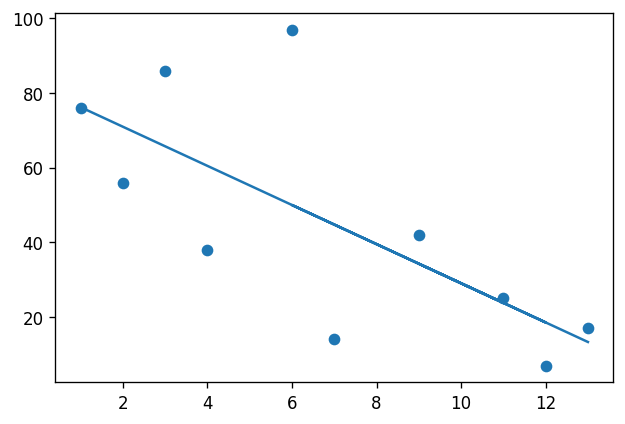

In [48]:
def least_squares_regression(x_data, y_data):
    n = len(x_data) # Number of total data points
    sumx = 0 # Σ x_i
    sumy = 0 # Σ y_i
    sumxy = 0 # Σ (x_i y_i)
    sumx2 = 0 # Σ (x_i^2)
    st = 0 # Total sum of squares
    sr = 0 # Residual sum of squares


    #Summations of data
    for i in range(len(x_data)):
        sumx = sumx + x_data[i]
        sumy = sumy + y_data[i]
        sumxy = sumxy + x_data[i] * y_data[i]
        sumx2 = sumx2 + (x_data[i] * x_data[i])

    #Mean values for x and y data
    xm = sumx/n
    ym = sumy/n

    #Regression Coefficients
    #a1 = slope
    #a0 = y-intercept
    a1 = (n*sumxy - (sumx * sumy)) / ((n*sumx2) 
                                    - (sumx * sumx))
    a0 = ym - a1 * xm

    #Calculating error values
    for i in range(len(x_data)):
        st = st + (y_data[i] - ym)**2
        sr = sr + (y_data[i] - a1*x_data[i] - a0)**2

    #Calculating Standard error and R^2 values
    standard_error = (sr / (n-2))**(0.5)
    r_2 = (st - sr) / st
    return(a0, a1, standard_error, r_2)

# CALLING LEAST SQUARES FUNCTION ------------------------------------------------------------------

# For two experimental data set lists, we can find the regression terms by calling this function.
x = [1, 2, 3, 4, 11, 6, 7, 12, 9, 13]
y = [76, 56, 86, 38, 25, 97, 14, 7, 42, 17]
x = np.array(x)
y = np.array(y)

a0, a1, standard_error, r_2 = least_squares_regression(x, y)
print(f"Intercept of Regression: {a0}")
print(f"Slope of Regression: {a1}")
print(f"Standard Error: {standard_error}")
print(f"Coefficient of Determination: {r_2}")
      
regression_func = a0 + a1 * x

fig, ax = plt.subplots(figsize=(6, 4), dpi = 120)
ax.scatter(x, y)
ax.plot(x, regression_func, label = f"y={np.round(a1, 5)}*x + {np.round(a0, 2)}, $r^{2}$ = {np.round(r_2, 2)}");

Method 2: (scipy.linregress)

a0:  81.43914081145584
a1:  -5.241050119331743
Standard Error:  23.72725641319229
R^2 Value:  0.5054831596491944


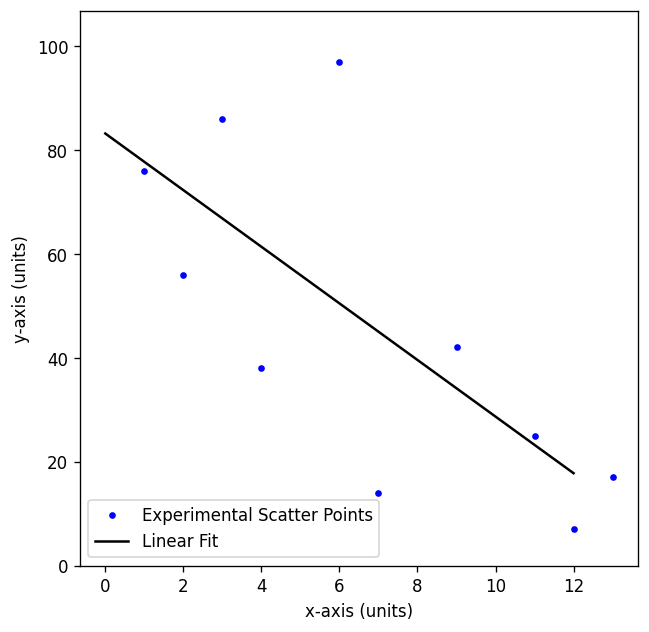

In [ ]:
from scipy.stats import linregress

x = [1, 2, 3, 4, 11, 6, 7, 12, 9, 13]
y = [76, 56, 86, 38, 25, 97, 14, 7, 42, 17]
x = np.array(x)
y = np.array(y)

# METHOD 1: Concatenate Data ------------------------------------------------------------------

# Given a list of x values (x-axis) and a list of y values (y-axis)
# Define start and end values in the data to create a better linear fit
start_data = min(1, len(x)) # Example start point
end_data = min(3, len(x) - start_data) # Example end point
x_subsample = np.concatenate([x[:start_data], x[-1*end_data:]])
y_subsample = np.concatenate([y[:start_data], y[-1*end_data:]])

background_regression = linregress(x_subsample, y_subsample)
#print(background_regression)

def linear_model(fn, t):
    return fn.slope * t + fn.intercept

# Plotting the linear regression
fig, ax = plt.subplots(figsize = (6, 6), dpi=120)
t_background = np.linspace(0, 12, 100)
I_background = linear_model(background_regression, t_background)
ax.plot(x, y, "b.", label = "Experimental Scatter Points")
ax.plot(t_background, I_background, "k-", label = "Linear Fit")
ax.set_ylim([0, 1.1*y.max()])
ax.set_xlabel("x-axis (units)")
ax.set_ylabel("y-axis (units)")
ax.legend();


# METHOD 2: Most Basic linregress ------------------------------------------------------------------


def least_squares_regression2(x_data, y_data):

    regression = linregress(x_data, y_data)
    
    # Regression Variables
    a1 = regression.slope
    a0 = regression.intercept
    r_2 = regression.rvalue**2

    # Standard Error calculation
    n = len(x_data)
    y_hat = a0 + a1*x_data
    sr = np.sum((y_data-y_hat)**2)
    standard_error = np.sqrt(sr / (n-2))

    return a0, a1, standard_error, r_2

# EXAMPLE DATA ---------------------------------------------------------------------------

a0, a1, error, r_2 = least_squares_regression2(x, y)
print("a0: ", a0)
print("a1: ", a1)
print("Standard Error: ", error)
print("R^2 Value: ", r_2)


Method 3: Curve-Fitting and Guessing Parameters

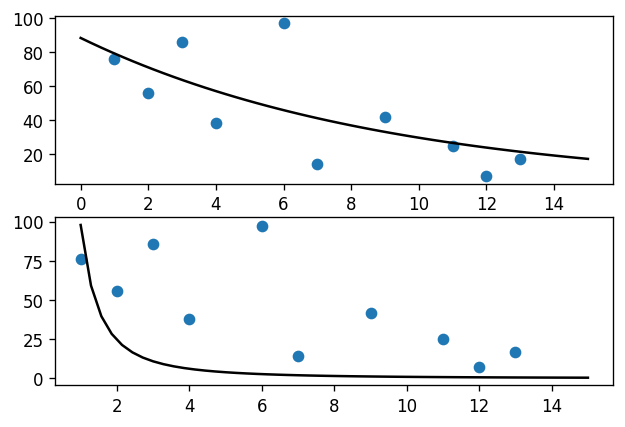

In [50]:
# ----------------------------------------------------------------------------------
# The outcome you get highly depends on what theoretical function you expect your data to follow
# Could be really inaccurate if you curve fit your data to the incorrect function
# However, of the three methods of fitting, this is the best because scipy has optimized this code (least standard error)
# ----------------------------------------------------------------------------------
# Example Data
x = [1, 2, 3, 4, 11, 6, 7, 12, 9, 13]
y = [76, 56, 86, 38, 25, 97, 14, 7, 42, 17]
x = np.array(x)
y = np.array(y)

def function1(x_axis1, f1var1, f1var2):
    # EXAMPLE: Exponential Function
    return f1var1 * np.exp(-f1var2 * x_axis1)

def function2(x_axis2, f2var1):
    # EXAMPLE: Inverse Squared Function
    return f2var1 / x_axis2**2

#Define range for regression line to go to
x_reg = np.linspace(0, 15)
d_reg = np.linspace(1, 15)

# Put reasonable guesses into p0
popt_I, pcov_I = sp.optimize.curve_fit(function1, x, y, p0 = [0, 1])
popt_B, pcov_B = sp.optimize.curve_fit(function2, x, y, p0 = [2])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), dpi=120)
ax1.scatter(x, y)
ax2.scatter(x, y)
ax1.plot(x_reg, function1(x_reg, *popt_I), color = "black") # Exponential function Fit
ax2.plot(d_reg, function2(d_reg, *popt_B), color = "black") # Inverse Square function Fit

Linearizing Nonlinear Functions and Applying Regression:

Measured Intensity (W) vs. Glass Layers Least Squares Regression: 

Intercept of Regression: 6.881307602375785
Slope of Regression: -0.34439901000297773
Standard Error: 0.05139317092565348
Coefficient of Determination: 0.9981813617530159

Measured Brightness (lumens) vs. Distance (m) Least Squares Regression: 

Intercept of Regression: -1.925676890713234
Slope of Regression: 1199.2133921247714
Standard Error: 3.738774042419974
Coefficient of Determination: 0.9998620286711787


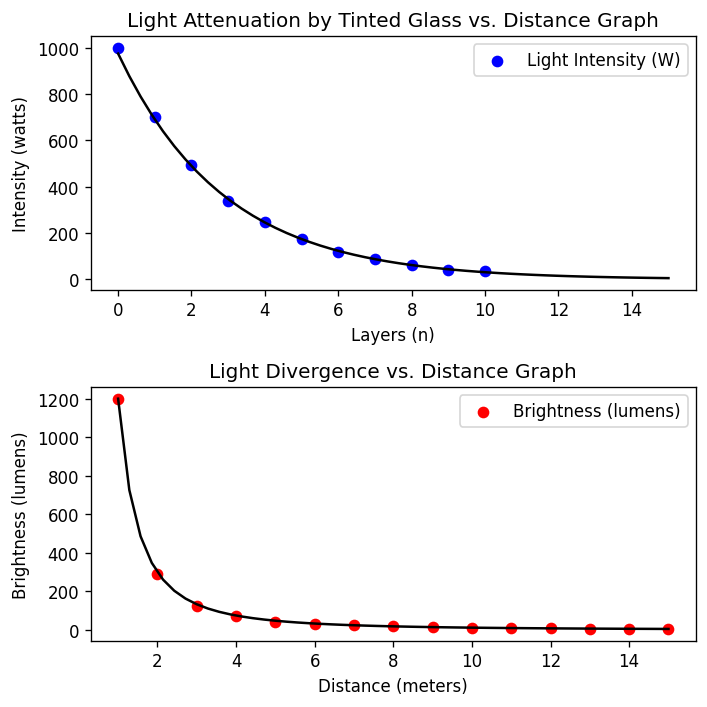

In [51]:
# Modeled by Exponential Function I = I0e^-kx
layers = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
intensity = [1000.0, 700.7, 492.6, 339.9, 246.5, 
173.5, 118.2, 86.1, 60.7, 40.8, 35.1] # Watts
# Modeled by Inverse Square Function I = A/d^2
distance = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 
13, 14, 15] # meters
brightness = [1200.0, 290.0, 123.3, 75.0, 42.0, 33.3, 
24.5, 18.8, 12.8, 11.0, 9.9, 8.3, 7.1, 6.1, 4.3] # lumens

# Turned into arrays in order to apply math operations
layers = np.array(layers)
intensity = np.array(intensity)
distance = np.array(distance)
brightness = np.array(brightness)

# Must first linearize the data sets.
linear_intensity = np.log(intensity) #y-axis linearized logarithmically
linear_distance = 1 / distance **2 #x-axis linearized using inverse square

I_a0, I_a1, I_standard_error, I_r_2 = least_squares_regression(layers, linear_intensity)
print("Measured Intensity (W) vs. Glass Layers \
Least Squares Regression: ")
print(f"\nIntercept of Regression: {I_a0}")
print(f"Slope of Regression: {I_a1}")
print(f"Standard Error: {I_standard_error}")
print(f"Coefficient of Determination: {I_r_2}")
B_a0, B_a1, B_standard_error, B_r_2 = least_squares_regression(linear_distance, brightness)
print(f"\nMeasured Brightness (lumens) vs. \
Distance (m) Least Squares Regression: ")
print(f"\nIntercept of Regression: {B_a0}")
print(f"Slope of Regression: {B_a1}")
print(f"Standard Error: {B_standard_error}")
print(f"Coefficient of Determination: {B_r_2}")

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6), 
                                                dpi=120)
ax1.scatter(layers, intensity, color = 'b', 
label = "Light Intensity (W)")
ax2.scatter(distance, brightness, color = 'r', 
label = "Brightness (lumens)")

# Fit parameters for regression to look linear
I_0 = np.exp(I_a0)
k = - I_a1
A = B_a1

x_reg = np.linspace(0, 15)
#I = I_0 * exp(-k*x)
I_reg = I_0 * np.exp(-k * x_reg)
ax1.plot(x_reg, I_reg, color = 'black')

d_reg = np.linspace(1, 15)
#I = A / d**2
B_reg = A / d_reg**2
ax2.plot(d_reg, B_reg, color = 'black')

ax1.set_xlabel("Layers (n)")
ax1.set_ylabel("Intensity (watts)")
ax1.set_title("Light Attenuation by Tinted Glass \
vs. Distance Graph")
ax2.set_xlabel("Distance (meters)")
ax2.set_ylabel("Brightness (lumens)")
ax2.set_title("Light Divergence vs. Distance Graph")
ax1.legend()
ax2.legend()
plt.tight_layout()

<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

## Bracketing Methods (Ch. 5) - Bisection/False-Position Methods

$$ \textbf{Bisection Method Estimate of Root x: }$$ $$ x_r = \frac{x_{lower} + x_{upper}}{2}$$

In [52]:
# METHOD 1: Bisection Method for a Defined Function ------------------------------------------------------------------

def bisection_method1(f, lower, upper, tol=1e-6, max_iter=100):

    # Checking to see if a function passes through zeros within the specified bounds
    # For there to be a zero, according to Intermediate Value Theorem, f(lower) and f(upper) must have opposite signs.
    if f(lower)*f(upper) >= 0:
        return("No roots found within bounds!")
    
    for i in range(max_iter):
        x_r = (lower + upper)/2 # Bisection
        # test checks which subinterval contains the root

        if np.abs(f(x_r)) < tol:
            return x_r
        
        # Bracketed Method Condition
        test = f(lower) * f(x_r)
        if test < 0:
            upper = x_r
        else:
            lower = x_r

    return x_r
# -----------------------------------------------------------------------------------------------------------------------------
# Must define a function for it to look through

def function(x):
    return x**2 + 5*x - 6

print(f"Version 1 Bisection Root Prediction:", bisection_method1(function, -10, 0)) # Expected roots: x = -6, 1

# -----------------------------------------------------------------------------------------------------------------------------




# METHOD 2: Bisection Method for a list of Experimental Data ------------------------------------------------------------------

def bisection_method2(x_data, y_data, tol=1e-6, max_iter=100):
    x_data = np.array(x_data)
    y_data = np.array(y_data)

    for i in range(len(y_data) - 1):
        if y_data[i] * y_data[i+1] < 0:
            lower_index = i
            upper_index = i+1
            break

    else:
        return("No roots found in data")
    
    x_lower = x_data[lower_index] # x value of current index
    x_upper = x_data[upper_index] # x value of index right after
    y_lower = y_data[lower_index] # y value of current index
    y_upper = y_data[upper_index] # y value of index right after

    for j in range(max_iter):
        # Linear interpolation
        # Interpolation for x: x = x_low - (y_low(x_high - x_low)) / (y_high - y_low)
        x_r = x_lower - (y_lower * (x_upper - x_lower)) / (y_upper - y_lower)
        # Interpolation for y: y = y_low + ((y_high - y_low)*(x_r - x_low)) / (x_high - x_low)
        y_r = y_lower + (y_upper - y_lower) * (x_r - x_lower) / (x_upper - x_lower)

        if np.abs(y_r) < tol:
            return x_r
        
        # Bracketed Method Condition
        test = y_lower * y_r
        if test < 0:
            x_upper = x_r
            y_upper = y_r
        else:
            x_lower = x_r
            y_lower = y_r

    return x_r

# -----------------------------------------------------------------------------------------------------------------------------

x = [0, 0.5, 1.0, 1.5, 2.0]
y = [1, 0.3, -0.2, -1.0, -2.0]

root = bisection_method2(x, y) # Expected root: 0.8
print("Version 2 Bisection Depth Prediction: ", root)

# -----------------------------------------------------------------------------------------------------------------------------

Version 1 Bisection Root Prediction: -5.999999940395355
Version 2 Bisection Depth Prediction:  0.8


$$ \textbf{False Position Method Estimate of Root x: }$$ $$ x_r = upper - \frac{f(upper) * (lower - upper)}{f(lower) - f(upper)}$$

In [53]:
# METHOD 1: False Position Method for a single-root, smooth, continuous, "agreeable" function ---------

# FP Method can only work on certain functions - sometimes FP Method diverges on shallow or one-sided functions.
def false_position_method1(f, lower, upper, tol=1e-6, max_iter=100):
    for i in range(max_iter):
        x_r = upper - (f(upper) * (lower - upper)) / (f(lower) - f(upper))

        if np.abs(f(x_r)) < tol:
            return x_r
        
        # Bracketed Method Condition
        test = f(lower) * f(x_r)
        if test < 0:
            upper = x_r
        else:
            lower = x_r
    
    return x_r

# EXAMPLE FUNCTION: ------------------------------------------------------------------------------------------------------------

def f(x):
    return x**2 + 5*x - 6   # roots at x = 1 and x = -6

root = false_position_method1(f, 0, 3)
print("False Position Method 1 Root:", root)


# -----------------------------------------------------------------------------------------------------------------------------





# METHOD 2: Modified False Position Method w/check for a "valid" function -------------------------------------

def false_position_method2(f, lower, upper, tol = 1e-6, max_iter=100):

    #Counters to track repeated use of endpoints
    lower_reused_count = 0
    upper_reused_count = 0

    f_lower = f(lower)
    f_upper = f(upper)

    # Initial Root Estimate
    x_r = lower
    approx_rel_error = 100

    if f(lower) * f(upper) > 0:
        return("There are either multiple roots or no roots within these bounds!")

    for count in range(max_iter):
        prev_xr = x_r

        #False Position Formula
        x_r = upper - (f_upper * (lower - upper)) / (f_lower - f_upper)
        f_root = f(x_r)
        # Calculate Approximate Relative Percent Error
        if x_r != 0: 
            approx_rel_error = np.abs((x_r - prev_xr) / x_r) * 100

        # Bracketed Method Condition
        test = f_lower * f_root
        if test < 0:
            upper = x_r
            f_upper = f_root

            upper_reused_count = 0
            lower_reused_count += 1

            if lower_reused_count >= 2:
                f_lower = f_lower / 2

        elif test > 0:
            lower = x_r
            f_lower = f_root

            lower_reused_count = 0
            upper_reused_count += 1

            if upper_reused_count >= 2:
                f_upper = f_upper / 2
        else:
            approx_rel_error = 0

        if approx_rel_error < tol:
            break

    return x_r

# EXAMPLE FUNCTION: ------------------------------------------------------------------------------------------------------------

def f(x):
    return x**2 + 5*x - 6   # roots at x = 1 and x = -6

root = false_position_method2(f, -9, 6)
print("False Position Method 2 Root:", root)


# -----------------------------------------------------------------------------------------------------------------------------




# ***NOT DONE*** METHOD 3: False Position Method that Finds Multiple Roots at Once -------------------------------------


False Position Method 1 Root: 0.9999999238606558
False Position Method 2 Root: There are either multiple roots or no roots within these bounds!


$$ \textbf{Linear Interpolation Bracketed Method Estimate of Root x (My Own Idea) }$$

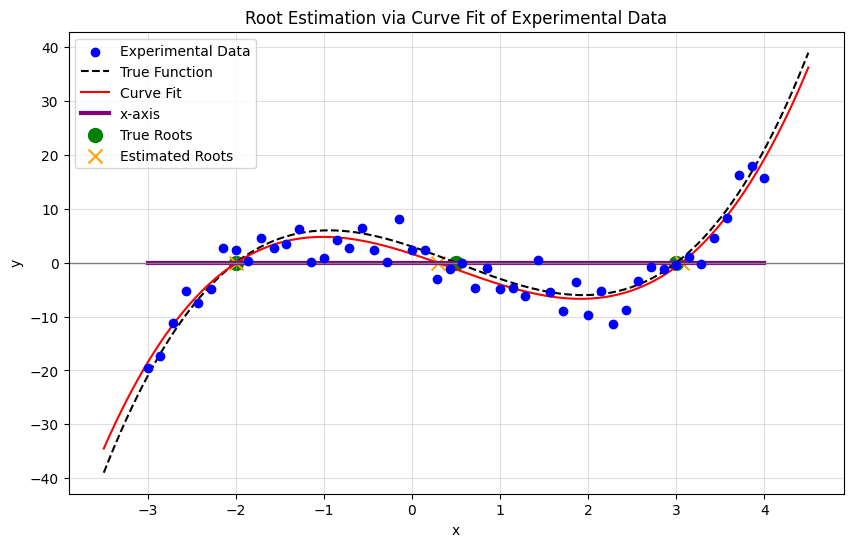

In [54]:
from scipy.optimize import curve_fit

# A bracketed root-finding method that uses linear 
# interpolation between two consecutive data points 
# with opposite signs to approximate a root. It guarantees
#  convergence if the data accurately bracket a root, 
# similar to the False Position method for functions.

def theoretical_func(x):
    return (x + 2) * (x - 0.5) * (x - 3)  # roots at x=-2, 0.5, 3

# Would be real experimental data
np.random.seed(42)
x_data = np.linspace(-3, 4, 50)
y_data = theoretical_func(x_data) + np.random.normal(0, 3, x_data.size)  # add noise

# Fitting cubic function as an example
def cubic_func(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

# Curve fitting
params, _ = curve_fit(cubic_func, x_data, y_data)
a, b, c, d = params

# Solve for roots of fitted curve
coeffs = [a, b, c, d]
roots_estimated = np.roots(coeffs)
roots_estimated = roots_estimated[np.isreal(roots_estimated)].real

# True roots
true_roots = np.array([-2, 0.5, 3])


# Plotting
x_smooth = np.linspace(-3.5, 4.5, 500)
y_true = theoretical_func(x_smooth)
y_fit = cubic_func(x_smooth, *params)

plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color='blue', label='Experimental Data', zorder=5)
plt.plot(x_smooth, y_true, 'k--', label='True Function')
plt.plot(x_smooth, y_fit, 'r-', label='Curve Fit')

# Plot x-axis
axis = [0] * len(x_data)
plt.plot(x_data, axis, color = "purple", label= "x-axis", linewidth = '3')
# Plot roots
plt.scatter(true_roots, np.zeros_like(true_roots), color='green', s=100, marker='o', label='True Roots')
plt.scatter(roots_estimated, np.zeros_like(roots_estimated), color='orange', s=100, marker='x', label='Estimated Roots')

plt.axhline(0, color='gray', linewidth=1)
plt.xlabel('x')
plt.ylabel('y')
plt.title('Root Estimation via Curve Fit of Experimental Data')
plt.legend()
plt.grid(alpha=0.4)
plt.show()

<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

## Open Root Finding Methods (Ch. 6) - Newton-Raphson/Secant/Fixed-Point Iteration Methods

Open Methods do not require an upper and lower bound that brackets the root within. The open method relies on an approximate guess as to where the root is and iterates until the root is found. Unlike the bracketed method, there is no guarentee that f(a) * f(b) < 0 (opposite signs).

$$ \textbf{Newton-Raphson Method to Estimate Root x: }$$ $$ x^* = x_r - \frac{f(x_{r})}{\frac{df(x_{r})}{dx}}$$

N-R method has no well-defined convergence criteria, but converges much quicker than any other method. Must consider whether the function we are using converges or diverges.

In [55]:
def newton_raphson_method(A, guess, max_iter):

    # Example Function
    def f(x, A):
        return A*x**2 + 3*x - 6
    
    def f_prime(x, A):
        return 2*A*x + 3

    count = 0
    iterable_guess = []
    while count < max_iter:
        #oldguess is x_i in terms of the N_R Equation, stores previous guess
        oldguess = guess
        new = oldguess - (f(oldguess, A) / f_prime(oldguess, A)) #Newton-Raphson Formula
        guess = new
        iterable_guess.append(new) #storing current guess
        count += 1 #update iteration counter

    return guess, iterable_guess

# -----------------------------------------------------------------------------------------------------------------------------
    
print("Newton-Raphson Method Example Root 1: ", newton_raphson_method(3, 5, 100)[0]) # Expected Roots: -2, 1
print("Newton-Raphson Method Example Root 2: ", newton_raphson_method(3, -3, 100)[0]) # Expected Roots: -2, 1

# -----------------------------------------------------------------------------------------------------------------------------
# Can only find one root per guess

Newton-Raphson Method Example Root 1:  1.0
Newton-Raphson Method Example Root 2:  -2.0


$$ \textbf{Fixed-Point Iteration Method to Estimate Root x: }$$

In [56]:
# NOTES -----------------------------------------------------------------------------------------------------------------------
# Will only work if the function obeys the rule: |f'(x*)| < 1 at and near the solution x*
# Essentially, it works only for functions that converge onto a point.
# METHOD 1: Given a function --------------------------------------------------------------------------------------------------------------
def fixed_point_iteration1(f, guess, tol, max_iter):
    
    x_previous = guess
    for i in range(1, max_iter+1):
        x_next = f(x_previous)
        
        if np.abs((x_next - x_previous)) < tol:
            #print("Converged!")
            return x_next
        
        x_previous = x_next
    #print(f"{max_iter} iterations reached.")
    return x_next

# EXAMPLE FUNCTION ------------------------------------------------------------------------------------------------------------------------
def func(x):
        example_function = 0.4*x - 5
        return example_function

print("Method 1 Approximate root value for f(x):", fixed_point_iteration1(func, 1.3, 1e-6, 100))

# -----------------------------------------------------------------------------------------------------------------------------------------

# METHOD 2: Given a list of data to iterate through ????---------------------------------------------------------------------------------------

    

Method 1 Approximate root value for f(x): -8.333332671335707


$$ \textbf{Secant Method to Estimate Root x: }$$ $$ x_{i+1} = x_i - \frac{f(x_i)(x_{i-1} - x_i)}{f(x_{i-1}) - f(x_i)}$$

In [57]:
# NOTES -----------------------------------------------------------------------------------------------------------------------
# Useful for functions whose derivatives are extremely difficult to calculate
# Requires 2 guesses instead of 1
# Worse than the previous methods because it is only an approximation of the slope, so it doesnt perfectly describe function behavior 
# Still efficient and works about as well as the N-R Method. 
# -----------------------------------------------------------------------------------------------------------------------------

def secant_method(f, x0, x1, tol, max_iter):
    for i in range(max_iter):
        f0 = f(x0)
        f1 = f(x1)
        x2 = x1 - (f1*(x1 - x0)) / (f1 - f0)

        if np.abs(x2 - x1) < tol:
            return x2
        x0 = x1
        x1 = x2

    return x2


# EXAMPLE FUNCTION -------------------------------------------------------------------------------------------------------------

def func(x):
    return x**2 - 2*x + 1

print(secant_method(func, 1, 4, 1e-6, 100)) # Expected roots: 1

# -----------------------------------------------------------------------------------------------------------------------------

1.0


<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

## Truncation Errors and Taylor Series (Ch. 4) - Error Comparisons

/var/folders/lx/5c1y1s9170s2gm725ndxdpzr0000gn/T/ipykernel_92879/1207716403.py:66: RuntimeWarning: divide by zero encountered in scalar divide
  errors.append(np.abs(curr - prev) / np.abs(curr))


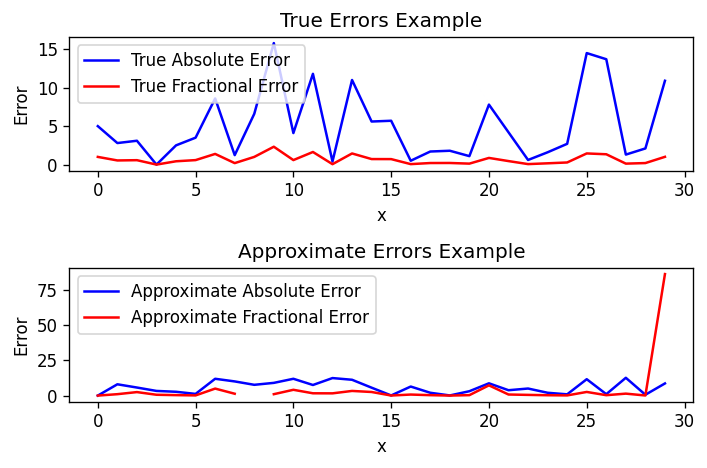

In [58]:
# NOTES -----------------------------------------------------------------------------------------------------------------------
# Functions to compute the six types of error if given a list of experimental data
# -----------------------------------------------------------------------------------------------------------------------------

# METHOD 1: Given two lists of experimental data and theoretical data ---------------------------------------------------------

def true_error(true_values, approx_values):
    return np.abs(np.array(true_values) - np.array(approx_values))

def true_fractional_error(true_values, approx_values):
    return np.abs(np.array(true_values) - np.array(approx_values)) / np.abs(true_values)

def true_percent_error(true_values, approx_values):
    return 100 * np.abs(np.array(true_values) - np.array(approx_values)) / np.abs(true_values)

def approximate_error(curr_values, prev_values):
    return np.abs(np.array(curr_values) - np.array(prev_values))

def approximate_fractional_error(curr_values, prev_values):
    return np.abs(np.array(curr_values) - np.array(prev_values)) / np.abs(curr_values)

def approximate_percent_error(curr_values, prev_values):
    return 100 * np.abs(np.array(curr_values) - np.array(prev_values)) / np.abs(curr_values)




# METHOD 2: Given a list of experimental data and a theoretical function -------------------------------------------------------

#True Error Functions
def true_error(experimental_list, x_val_list, true_func):
    experimental_list = np.array(experimental_list)
    true_vals = []
    for x in range(len(x_val_list)):
        true_vals.append(true_func(x))
    true_vals = np.array(true_vals)
    return np.abs(true_vals - experimental_list)

def true_fractional_error(experimental_list, x_val_list, true_func):
    true_vals = []
    experimental_list = np.array(experimental_list)
    for x in range(len(x_val_list)):
        true_vals.append(true_func(x))
    true_vals = np.array(true_vals)
    return np.abs(true_vals - experimental_list) / np.abs(true_vals)
    
def true_percent_error(experimental_list, x_val_list, true_func):
    return 100 * true_fractional_error(experimental_list, x_val_list, true_func)



# Approximate Error Functions
def approximate_error(experimental_list):
    experimental_list = np.array(experimental_list)
    errors = [0]
    for i in range(1, len(experimental_list)):
        errors.append(np.abs(experimental_list[i] - experimental_list[i-1]))
    return np.array(errors)

def approximate_fractional_error(experimental_list):
    experimental_list = np.array(experimental_list)
    errors = [0]
    for i in range(1, len(experimental_list)):
        curr = experimental_list[i]
        prev = experimental_list[i-1]
        errors.append(np.abs(curr - prev) / np.abs(curr))
    return np.array(errors)

def approximate_percent_error(experimental_list):
    return 100 * approximate_fractional_error(experimental_list)

# EXAMPLE DATASET AND FUNCTION ------------------------------------------------------------------------------------------------
data_set = [0, 8, 2.3, 5.6, 8.3, 9.5, 
            -2.4, 7.63, 0, -9, 2.9, -4.6, 
            7.8, -3.4, 2.2, 2.3, 8.7, 6.7, 6.8, 
            9.9, 1.2, 5, 10, 8.0, 7.1, -4.5, 
            -3.5, 9.1, 8.5, -0.1]

x_values = np.arange(len(data_set))

def true_func(x):
    return 5 + 0.2*x

true_abs = true_error(data_set, x_values, true_func)
true_frac = true_fractional_error(data_set, x_values, true_func)
true_percent = true_percent_error(data_set, x_values, true_func)

approx_abs = approximate_error(data_set)
approx_frac = approximate_fractional_error(data_set)
approx_percent = approximate_percent_error(data_set)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 4), dpi=120)
#ax1.scatter(x_values, data_set)
ax1.plot(x_values, true_abs, color = 'blue', label = "True Absolute Error")
ax1.plot(x_values, true_frac, color = 'red', label = "True Fractional Error")
#ax1.plot(x_values, true_percent, color = 'green', label = "True Percent Error")
ax1.set_title("True Errors Example")
ax1.set_xlabel("x")
ax1.set_ylabel("Error")
ax1.legend()

#ax2.scatter(x_values, data_set)
ax2.plot(x_values, approx_abs, color = 'blue', label = "Approximate Absolute Error")
ax2.plot(x_values, approx_frac, color = 'red', label = "Approximate Fractional Error")
#ax2.plot(x_values, approx_percent, color = 'green', label = "Approximate Percent Error")
ax2.set_title("Approximate Errors Example")
ax2.set_xlabel("x")
ax2.set_ylabel("Error")
ax2.legend()

plt.tight_layout()

# -----------------------------------------------------------------------------------------------------------------------------


<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

## Interpolation - Ch.18
- Newton's Divided Difference Interpolating Polynomials
- Lagrange Interpolating Polynomials
- Splines
- scipy.CubicSpline

$ \text{Newton's Interpolating Polynomials:} $

$$ \text{Linear Interpolation:} $$
$$ f(x) = f(x_0) + (x-x_0)\frac{f(x_1) - f(x_0)}{x_1 - x_0} $$

$$ \text{Quadratic Interpolation:} $$
$$ f(x) = b_0 + b_1(x-x_0) + b_2(x-x_0)(x-x_1) $$
$$ \text{where } b_0 = f(x_0),\ b_1 = \frac{f(x_1) - f(x_0)}{x_1 - x_0}, \ b_2 = \frac{\frac{f(x_2)-f(x_1)}{x_2 - x_1}-\frac{f(x_1)-f(x_0)}{x_1 - x_0}}{x_2 - x_0} \ etc... $$


$ \text{General Form:} $


$$ b_0 + b_1(x-x_0) +...+ b_n(x-x_0)(x-x_1)...(x-x_{a-1}) $$

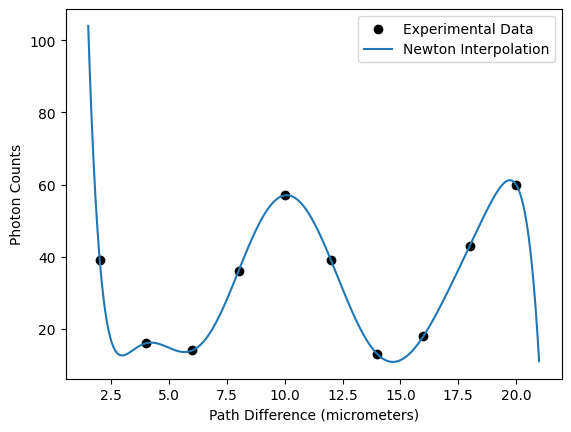

In [ ]:
# NOTES -----------------------------------------------------------------------------------------------------------------------
# The general version of Newton's Interpolating Polynomials 
# deals with both linear and quadratic interpolation.
# Good for low-order polynomials. 
# Error depends on the derivatives of the function
# bad for noisy data or high-degree polynomials as it leads to oscillations
# not very compact, lots of hand-calculation for higher and higher orders

# -----------------------------------------------------------------------------------------------------------------------------

# X and Y Data Sets with Iterative divided-differences -------------------------------------------------------
def newton_poly(xd, yd, Xvec):

    if len(xd) == len(yd):
        n = len(xd)
    else:
        return("x and y data have different lengths!")
    
    # Calculate all finite divided differences required + storing it
    # Nested loop 
    # f[xi​,xi+1​] = (f(xi+1)​−f(xi)​)/(xi+1​−xi​)... etc.
    fdd = np.zeros((n, n))
    fdd[:, 0] = yd
    for j in range(1, n):
        for i in range(0, n-j):
            # stores the jth order divided difference starting at index i
            fdd[i, j] = (fdd[i+1, j-1] - fdd[i, j-1]) / (xd[i+j] - xd[i])

    # Apply finite divided differences to calculate interpolating polynomial
    # xterm builds (x-x0)(x-x1)... etc term by term
    xterm = 1
    yint = np.zeros((n, len(Xvec)))
    # fdd[0, 0] is the first y value
    yint[0] = fdd[0, 0]
    for order in range(1, n):
        xterm *= (Xvec - xd[order-1])
        yint[order, :] = yint[order-1] + fdd[0, order] * xterm
    # returns the last row of y_int
    return(yint[-1, :])

# Plotting w/Example data

xdata = np.array([2, 4, 6, 8, 10, 12, 14, 16, 18, 20]) 
ydata = np.array([39, 16, 14, 36, 57, 39, 13, 18, 43, 60]) 
Xvec = np.linspace(1.5, 21, 1000)
Y_newt = newton_poly(xdata, ydata, Xvec)

plt.scatter(xdata, ydata, color='k', label="Experimental Data")
plt.plot(Xvec, Y_newt, label="Newton Interpolation")
plt.xlabel("Path Difference (micrometers)")
plt.ylabel("Photon Counts")
plt.legend();

$ \text{Lagrange Interpolating Polynomials:} $

$$ f_n (x) = \sum^n_{i=0} L_i (x) f(x_i) $$

$ \text{where} $
$$ L_i (x) = \prod _{j=0}^n \frac{x-x_j}{x_i - x_j} $$

In [ ]:
# NOTES -----------------------------------------------------------------------------------------------------------------------
# Problems: 
# Interpolation goes through every point, so it
# could do a poor job describing data behavior if there are a lot of data points.
# -----------------------------------------------------------------------------------------------------------------------------

def Li(i, xd, yd, Xvec):
    product = 1
    for j in range(0, len(xd)):
        if j != i:
            product *= (Xvec - xd[j])/(xd[i]-xd[j])
    return product

def lagrange_poly(xd, yd, Xvec):
    answer = 0
    for i in range(0, len(xd)):
        answer += Li(i, xd, yd, Xvec) * yd[i]
    return answer

$ \text{Splines} $

$ \text{First order function (linear splines), 2nd order function (quadratic splines), and 3rd order function (cubic splines)} $

$ \text{Necessary Conditions (for a cubic spline):} $

$$ f_i (x) = a_i x^3 + b_i x^2 + c_i x + d_i $$

1. *The function values must be equal at the interior knots (2n-2 conditions).*

 $$ a_{i-1}x_{i-1}^3  + b_{i-1}x_{i-1}^2 + c_{i-1}x_{i-1} + d_{i-1} = f(x_{i-1})$$
 $$ a_ix_{i-1}^3  + b_ix_{i-1}^2 + c_ix_{i-1} + d_i = f(x_{i-1}), \text{ for } i\in[2,n]$$

2. *The first and last functions must pass through the end points (2 conditions).*

$$ a_1x_0^3  + b_1x_0^2 + c_1x_0 + d_1 = f(x_0)$$
 $$ a_nx_n^3  + b_nx_n^2 + c_nx_n + d_n = f(x_n)$$

3. *The first derivatives at the interior knots must be equal (n-1 conditions).*

 $$ 3a_{i-1}x_{i-1}^2  + 2b_{i-1}x_{i-1} + c_{i-1} = 3a_ix_{i-1}^2  + 2b_ix_{i-1} + c_i, \text{ for } i\in[2,n]$$

4. *The second derivatives at the interior knots must be equal (n-1 conditions).*

$$ 6a_{i-1}x_{i-1}  + 2b_{i-1} = 6a_ix_{i-1}  + 2b_i, \text{ for } i\in[2,n]$$

5. *The second derivatives at the end knots must be zero (2 conditions).*

$$6a_1x_0 + 2b_1 = 0$$
$$6a_nx_n +2b_n =0$$




In [ ]:
# NOTES -----------------------------------------------------------------------------------------------------------------------
# -----------------------------------------------------------------------------------------------------------------------------

# Method 1: 4n x 4n approach using numeric iterations on a dataset -------------------------------------------------------
# (slower and must be careful with numeric iteration)
# Can easily modify constraints
# O(n^3) computational complexity

def cubicspline_system(x, y):
    n = len(x) - 1
    M = np.zeros((4*n, 4*n), dtype=float)
    V = np.zeros(4*n, dtype=float)

    # Interior knots: i = 2..n, at knot x_{i-1}
    for i in range(2, n + 1): # i = 2..n, iterating over all of the interior knots
        # 1) Function values at interior knot x_{i-1} (two equations)
        # S_{i-1}(x_{i-1}) = f(x_{i-1}), note: S -> "spline"
        M[4*(i-2), 4*(i-2):4*(i-2)+4] = [x[i-1]**3, x[i-1]**2, x[i-1], 1.0]
        V[4*(i-2)] = y[i-1]

        # S_i(x_{i-1}) = f(x_{i-1})
        M[4*(i-2)+1, 4*(i-1):4*(i-1)+4] = [x[i-1]**3, x[i-1]**2, x[i-1], 1.0]
        V[4*(i-2)+1] = y[i-1]

        # 3) First derivative continuity at x_{i-1}
        # (3a_{i-1} x_{i-1}^2 + 2b_{i-1} x_{i-1} + c_{i-1}) - (3a_i x_{i-1}^2 + 2b_i x_{i-1} + c_i) = 0
        M[4*(i-2)+2, 4*(i-2):4*(i-2)+3] = [3*x[i-1]**2, 2*x[i-1], 1.0]
        M[4*(i-2)+2, 4*(i-1):4*(i-1)+3] = [-3*x[i-1]**2, -2*x[i-1], -1.0]

        # 4) Second derivative continuity at x_{i-1}
        # (6a_{i-1} x_{i-1} + 2b_{i-1}) - (6a_i x_{i-1} + 2b_i) = 0
        M[4*(i-2)+3, 4*(i-2):4*(i-2)+2] = [6*x[i-1], 2.0]
        M[4*(i-2)+3, 4*(i-1):4*(i-1)+2] = [-6*x[i-1], -2.0]

    # Last 4 rows: endpoint interpolation (2) + natural BCs (2)

    # 2) S_1(x_0) = f(x_0)
    M[-4, 0:4] = [x[0]**3, x[0]**2, x[0], 1.0]
    V[-4] = y[0]

    # 2) S_n(x_n) = f(x_n)
    M[-3, -4:] = [x[-1]**3, x[-1]**2, x[-1], 1.0]
    V[-3] = y[-1]

    # 5) Natural boundary: S''_1(x_0) = 0  -> 6 a1 x0 + 2 b1 = 0
    M[-2, 0] = 6 * x[0]
    M[-2, 1] = 2.0

    # 5) Natural boundary: S''_n(x_n) = 0  -> 6 an xn + 2 bn = 0
    M[-1, -4] = 6 * x[-1]
    M[-1, -3] = 2.0



# Method 2: Tridiagonalization -------------------------------------------------------
# faster and less risky - smarter technique, more efficient.
# solves only for second derivative conditions, avoids indexing mistakes
# Creates a tridiagonal matrix of O(n) computational complexity
# Second Order Error Accuracy O(h^2)


# --- Cubic Spline Function ---
def cubic_spline(x, y):

    x = np.array(x)
    y = np.array(y)
    n = len(x) - 1  # number of intervals
    
    h = x[1:] - x[:-1]
    a = y.copy()
    
    # Tridiagonal system for c
    A = np.zeros((n-1, n-1))
    rhs = np.zeros(n-1)
    
    for i in range(1, n):
        if i > 1:
            A[i-1, i-2] = h[i-1]
        A[i-1, i-1] = 2*(h[i-1] + h[i])
        if i < n-1:
            A[i-1, i] = h[i]
        # modified finite divided difference derivative calculation
        # with uniform spacing, equals to the central FDD for 2nd derivatives O(h^2)
        rhs[i-1] = 3*((y[i+1]-y[i])/h[i] - (y[i]-y[i-1])/h[i-1])
    
    c = np.zeros(n+1)
    if n > 1:
        c[1:n] = np.linalg.solve(A, rhs)
    
    # Compute b and d
    b = np.zeros(n)
    d = np.zeros(n)
    for i in range(n):
        d[i] = (c[i+1] - c[i]) / (3*h[i])
        b[i] = (y[i+1] - y[i])/h[i] - h[i]*(2*c[i] + c[i+1])/3
    
    return a, b, c[:-1], d

# evaluates the spline
def evaluate_spline(x, a, b, c, d, Xvec):

    Xvec = np.array(Xvec, dtype=float)
    Y = np.zeros_like(Xvec)
    
    for i, xi in enumerate(Xvec):
        # Find the interval
        idx = np.searchsorted(x, xi) - 1
        if idx < 0:
            idx = 0
        elif idx >= len(a):
            idx = len(a) - 1
        dx = xi - x[idx]
        Y[i] = a[idx] + b[idx]*dx + c[idx]*dx**2 + d[idx]*dx**3
    return Y

# interpolation using original data input
# T = x dataset
# F = y dataset
Xvec = np.linspace(T.min(), T.max(), 1000)
a, b, c, d = cubic_spline(T, F)
Y_spline = evaluate_spline(T, a, b, c, d, Xvec)

# plotting
plt.figure(figsize=(6,5), dpi=120)
plt.scatter(T, F, color='blue', label='Heat Flow Data')
plt.plot(Xvec, Y_spline, color='red', label='Cubic Spline')
plt.xlabel("Temperature (C)")
plt.ylabel("Heat Flow (W/g)")
plt.title("Heat Flow vs Temperature in Glass")
plt.grid(alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


# Method 3:  Scipy CubicSpline Method -------------------------------------------------------
# Most simple method - easy for a time crunch

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
import pandas as pd

def evaluate_scipy_spline(x, y, Xvec, bc_type='natural'):

    x = np.array(x)
    y = np.array(y)
    Xvec = np.array(Xvec)

    # Construct the cubic spline
    spline = CubicSpline(x, y, bc_type=bc_type)

    # Evaluate the spline at desired points
    Y = spline(Xvec)
    return Y

#Example
array = [1, 2, 3, 4, 5] # dataset of my choosing
T = array[:, 2]
F = array[:, 3]

Xvec = np.linspace(T.min(), T.max(), 1000)
Y_spline = evaluate_scipy_spline(T, F, Xvec, bc_type='natural')

# Plotting
plt.figure(figsize=(6,5), dpi=120)
plt.scatter(T, F, color='blue', label='Heat Flow Data')
plt.plot(Xvec, Y_spline, color='red', label='SciPy Cubic Spline')
plt.xlabel("Temperature (C)")
plt.ylabel("Heat Flow (W/g)")
plt.title("Heat Flow vs Temperature in Glass")
plt.grid(alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

## Numerical Integration -- Ch.21/22
- Newton-Cotes Formulas (Trapezoidal Rule)
- Simpson's 1/3 and 3/8 Rules
- Romberg Integration (**)
- Gauss Quadrature
- scipy.integrate


$ \text{Trapezoidal Rule:} $
- Essentially a first degree Newton-Cotes formula

$$ I = \int^b_a [f(a)+ \frac{f(b)-f(a)}{b-a} (x-a)] \,dx $$

$ where $
$$ [f(a)+ \frac{f(b)-f(a)}{b-a} (x-a)] = f_1(x) $$


$$ I = \frac{1}{2}[f(a)+f(b)](b-a) $$

this shows the trapezoidal shape


$ Error: $

$$ E_t = -\frac{1}{12}f^{''}(\xi)(b-a)^3




In [ ]:
# NOTES -----------------------------------------------------------------------------------------------------------------------
# Error depends on the width of the interval. Smaller interval width = less error
# Error can be small or large depending on function curvature as well
# *1st Order accurate 
# Error can be reduced by subdividing the integration interval into smaller segments instead of a --> b
# -----------------------------------------------------------------------------------------------------------------------------

# Method 1: Method that takes in a function to be integrated and its 2nd derivative, as well as calculates error --------------


def trapezoidal_method1(f, f2, a, b, xi):

    # f is any function needed to have its integral approximated
    # xi is a point between a and b used for the error estimate
    # a and b are the integration bounds
    # f2 = second derivative of f

    fa = f(a)
    fb = f(b)

    I = 0.5 * (fa + fb) * (b - a)

    error = -(1/12) * f2(xi) * (b - a)**3

    return I, error

# Example function
def f(x):
  return x**2

# 2nd derivative
def f_d2dx2(x):
  return 2

I, E = trapezoidal_method1(f, f_d2dx2, 0, 2, 1)

print("Method 1 Integral:", I)
print("Method 1 Estimated error:", E)


# Method 2: Function and its integrand calculated, then trapezoidal rule used ----------------------


C0 = 0.08 # mL/(min * mm)
tau = 2.5 # min
lam = 0.6 #mm
rc = 0.01 #mm
R = 1.5 #mm
L = 30 #mm
global t #min
t = 6

def C(r, t):
  return C0 * (1-np.exp(-t/tau)) * np.exp(-r/lam)

def trapezoidal_method2(a, b, n):

  h = (b-a)/n # h in this case is step size
  integral = 0
  integral += 0.5*h * integrand(a)
  integral += 0.5*h * integrand(b)

  for i in range(1, n):
    x = i*h + a
    integral += h * integrand(x)
  return integral

def integrand(r):
  return C(r, t) * 2 * np.pi * r * L

val_trap = trapezoidal_method2(rc, R, 18)
print(f"Method 2 Trapezoidal result: {val_trap:.4f} mL O₂/min")


# Method 3: Version for tabulated data -------------------------------------------------------------


def trapezoidal_method_data(x, y):

    x = np.array(x)
    y = np.array(y)

    I = 0

    for i in range(len(x)-1):
        h = x[i+1] - x[i]
        I += 0.5 * (y[i] + y[i+1]) * h

    return I

# Example Data -------------------------------------------------------------------------------------

x = [0,1,2]
y = [0,1,4]   # f(x) = x^2

I = trapezoidal_method_data(x, y)

print("Method 3 Integral:", I)

Method 1 Integral: 4.0
Method 1 Estimated error: -1.3333333333333333
Method 2 Trapezoidal result: 3.5088 mL O₂/min
Method 3 Integral: 3.0


$ \text{Simpson's Rules:} $
$ \text{1/3 Rule: (2nd order accurate (quadratic) interpolating polynomial)} $
$$ I \approx \frac{h}{3} [f(a) + 4f(x_1)+f(b)] \ where \ h = \frac{b-a}{n} $$

$ \text{Can also be written iteratively as: } $
$$ \int^b_a f(x) \, dx \approx \frac{h}{3} [f(x_0) + 4 \sum _{odd \ i}f(x_i) + 2 \sum _{even \ i \neq 0} f(x_i) + f(x_n)] $$


$ \text{3/8 Rule: (3rd order accurate (cubic) interpolating polynomial)} $
$$ I \approx \frac{3h}{8} [f(a) + 3f(x_1)+3f(x_2)+f(b)] \ where \ h = \frac{b-a}{3} $$

In [ ]:
# NOTES -----------------------------------------------------------------------------------------------------------------------
#
# -----------------------------------------------------------------------------------------------------------------------------

# Method 1: Simpson 1/3 rule for a function f over [a,b] with n subintervals (even n). ----------------------------------------

def simpson_13_function(f, a, b, n):
    if n % 2 != 0:
        raise ValueError("n must be even for Simpson 1/3 rule")
    
    x = np.linspace(a, b, n+1)
    # define your function
    y = f(x)
    h = (b - a) / n
    
    I = y[0] + y[-1] + 4 * np.sum(y[1:-1:2]) + 2 * np.sum(y[2:-2:2])
    return I * h / 3


# Example Return: ---------------------------------------------------------

def f(x):
    return 2 + 3*x - 5*x**2 + 6*x**3

result = simpson_13_function(f, 0, 2, 4)
print("Simpson 1/3 function Method 1:", result)


# Method 2: Simpson 1/3 rule for numerical data arrays x and y. ----------------------------------------

def simpson_13_data(x, y):

    x = np.array(x)
    y = np.array(y)
    n = len(x) - 1
    if n % 2 != 0:
        raise ValueError("Number of subintervals must be even")
    
    I = 0
    for i in range(0, n, 2):
        # must cover 2 subintervals (or 3 data points) to be 2nd order accurate
        h = x[i+2] - x[i]
        I += (h/6) * (y[i] + 4*y[i+1] + y[i+2])
    return I




# Method 1: Simpson 3/8 rule over n subintervals for function f on [a,b]. ----------------------------------------

def simpson_38_function(f, a, b, n):

    if n % 3 != 0:
        raise ValueError("n must be a multiple of 3 for Simpson 3/8 rule")
    
    h = (b - a)/n
    x = np.linspace(a, b, n+1)
    # define function
    y = f(x)
    # 3/8 equation iteration
    I = y[0] + y[-1] + 3*np.sum(y[1:-1][(np.arange(1, n) % 3 != 0)]) \
                  + 2*np.sum(y[3:-1][::3])
    return I * 3*h/8


# Example Return: ---------------------------------------------------------

def f(x):
    return 2 + 3*x - 5*x**2 + 6*x**3
# n must be a multiple of 3
result = simpson_38_function(f, 0, 2, 9)
print("Simpson 3/8 function Method 1:", result)


# Method 2: Simpson 3/8 rule over n subintervals for data arrays x, y. ----------------------------------------


def simpson_38_data_n(x, y):

    x = np.array(x)
    y = np.array(y)
    n = len(x) - 1
    if n % 3 != 0:
        raise ValueError("Number of subintervals must be a multiple of 3")
    
    I = 0
    for i in range(0, n, 3):  # step by 3 subintervals
        h = x[i+3] - x[i]      # width over 3 intervals
        # 3/8 equation
        I += (3*h/8)*(y[i] + 3*y[i+1] + 3*y[i+2] + y[i+3])
    return I


Simpson 1/3 function Method 1: 20.666666666666668
Simpson 3/8 function Method 1: 20.66666666666666


$ \text{Romberg Integration:} $

In [100]:
def romberg(f, a, b, n=5):

    R = [[0.0]*n for _ in range(n)]

    # R[0][0] = trapezoidal rule with one interval
    R[0][0] = (b - a) * (f(a) + f(b)) / 2
    
    for i in range(1, n):
        h = (b - a) / (2**i)

        # sum of new points
        s = 0
        for k in range(1, 2**i, 2):
            s += f(a + k*h)

        # using trapezoidal rule to refine each iteration
        R[i][0] = 0.5 * R[i-1][0] + h * s

        # Richardson extrapolation
        for j in range(1, i+1):
            R[i][j] = R[i][j-1] + (R[i][j-1] - R[i-1][j-1]) / (4**j - 1)

    return R[n-1][n-1]

<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

## Solving Initial Value Problems (IVPs) - Ch.25
- Euler's Method
- Heun's Method (Improved Euler)
- Midpoint Method
- Runge-Kutta Methods

$ \text{Explicit Euler's Method:} $

- Approximates the solution of a differential equation step-by-step

$$ y_{i+1} \approx y_i + f(x_i, y_i) *h $$


$$ x_{i+1} = x_i - \lambda x_i h = (1- \lambda h)x_i $$

$$ |1- \lambda h| < 1 $$

#### Critical Stepsize h:
$$ 0 < h < 2/\lambda $$

$ \text{Directly calculates the future state using only the current state} $

In [ ]:
# NOTES -----------------------------------------------------------------------------------------------------------------------
# Explicit Method requires very small stepsizes under critical stepsize
# Rarely used in solving ODEs because it is very unstable.
# -----------------------------------------------------------------------------------------------------------------------------

def explicit_euler(h, N, x0, dx0):
    x1 = [x0]
    x2 = [dx0]

    for i in range(N):
        # x1_n+1 = x1_n + h*x2_n
        x1_next = x1[i] + h*x2[i]
        # x2_n+1 = x2_n + h*(-5002*x2_n - 10000*x1_n)
        x2_next = (x2[i] + h*(-5002*x2[i] - 10000*x1[i]))

        x1.append(x1_next)
        x2.append(x2_next)
    return x1, x2

hc = 2/5000 # Solved on paper
h = 0.0001 # A stepsize lower than hc
N = 200 # N = number of steps from 0 to 2 using stepsize 0.01
x0 = 3
dx0 = 4992
x1_vals, x2_vals = explicit_euler(h, N, x0, dx0)

print(f"Explicit Euler's Method ODE Solution: {x2_vals[-1]}")   
print(f"Critical Step Size: {hc:.4f}") 



# Method 2: More Default Version ----------------------------------------------------------------------------



def explicit_euler(f, x0, h, N):

    import numpy as np
    x = np.array(x0, dtype=float)
    xs = [x.copy()]
    
    for i in range(N):
        x = x + h * np.array(f(i*h, x))
        xs.append(x.copy())
    
    return xs

# Example Usage:

def system(t, x):
    x1, x2 = x
    dx1 = x2
    dx2 = -5002*x2 - 10000*x1
    return [dx1, dx2]

h = 0.0001
N = 200
x0 = [3, 4992]

solution = explicit_euler(system, x0, h, N)
x1_vals = [s[0] for s in solution]
x2_vals = [s[1] for s in solution]

print(f"Explicit Euler solution (last x2): {x2_vals[-1]}")

Explicit Euler's Method ODE Solution: -7.68628476391806
Critical Step Size: 0.0004
Explicit Euler solution (last x2): -7.68628476391806


$ \text{Implicit Euler Method:} $

- Approximates the solution of a differential equation step-by-step

$$ y_{i+1} \approx y_i + f(x_{i+1}, y_{i+1}) *h $$

$$  1 + \lambda h > 1 $$

$$ \text{ALWAYS} $$

$ \text{Solves an equation involving both the current and future state,} $
$ \text{making it much more stable for stiff systems.} $

In [ ]:
# NOTES -----------------------------------------------------------------------------------------------------------------------
# Much more stable and more widely used
# Unconditionally stable solutions regardless of stepsize
# More computationally expensive compared to explicit method.
# Derivative is evaluated at the next point, not the current point.
# -----------------------------------------------------------------------------------------------------------------------------

def implicit_euler(h, N, x0, dx0):
    x1 = [x0]
    x2 = [dx0]

    # Derived on paper
    c1 = 1 + 5002*h
    c2 = 1 + (10000*h**2) / c1

    for i in range(N):
        x1_next = (x1[i] + (x2[i]*h)/c1) / c2
        x2_next = (x2[i] - 10000*x1_next*h) / c1

        x1.append(x1_next)
        x2.append(x2_next)

    # x1 = position array, x2 = velocity array
    return(x1, x2)

h = 0.01
N = 200 # N = number of steps from 0 to 2 using stepsize 0.01
x0 = 3
dx0 = 4992
x1_vals, x2_vals = implicit_euler(h, N, x0, dx0)

print(f"Implicit Euler's Method ODE Solution (x1): {x1_vals[-1]}")
print(f"Implicit Euler's Method ODE Solution (x2): {x2_vals[-1]}")



# Method 2: More Default Version ----------------------------------------------------------------------------


# f = function 
# t0 = initial time 
# y0 = initial value
# h = stepsize
# N = number of time steps

def implicit_euler2(f, t0, y0, h, N, tol=1e-6, max_iter=100):

    t_values = np.zeros(N+1)
    y_values = np.zeros((N+1,) + np.shape(y0))
    
    t_values[0] = t0
    y_values[0] = y0
    
    y = y0
    t = t0
    
    for n in range(1, N+1):
        t_next = t + h
        
        # Initial guess for y_{n+1}
        y_next = y0
        
        # Fixed-point iteration
        for _ in range(max_iter):
            y_new = y + h * f(t_next, y_next)
            if np.linalg.norm(y_new - y_next) < tol:
                break
            y_next = y_new
        
        y = y_next
        t = t_next
        
        t_values[n] = t
        y_values[n] = y
    
    return t_values, y_values
    
# Example ODE:

def f(t, y):
    return -2 * y

# Initial condition
t0 = 0
y0 = 1
h = 0.1
N = 20

# Solve
t_vals, y_vals = implicit_euler2(f, t0, y0, h, N)

# Exact solution for comparison
y_exact = np.exp(-2 * t_vals)

# Print results
for t, y_num, y_ex in zip(t_vals, y_vals, y_exact):
    print(f"t={t:.2f}, y_num={y_num:.6f}, y_exact={y_ex:.6f}")

Implicit Euler's Method ODE Solution (x1): 0.07621240013365455
Implicit Euler's Method ODE Solution (x2): -0.1524248002673091
t=0.00, y_num=1.000000, y_exact=1.000000
t=0.10, y_num=0.833334, y_exact=0.818731
t=0.20, y_num=0.694446, y_exact=0.670320
t=0.30, y_num=0.578704, y_exact=0.548812
t=0.40, y_num=0.482253, y_exact=0.449329
t=0.50, y_num=0.401878, y_exact=0.367879
t=0.60, y_num=0.334898, y_exact=0.301194
t=0.70, y_num=0.279081, y_exact=0.246597
t=0.80, y_num=0.232567, y_exact=0.201897
t=0.90, y_num=0.193805, y_exact=0.165299
t=1.00, y_num=0.161504, y_exact=0.135335
t=1.10, y_num=0.134586, y_exact=0.110803
t=1.20, y_num=0.112155, y_exact=0.090718
t=1.30, y_num=0.093462, y_exact=0.074274
t=1.40, y_num=0.077884, y_exact=0.060810
t=1.50, y_num=0.064903, y_exact=0.049787
t=1.60, y_num=0.054086, y_exact=0.040762
t=1.70, y_num=0.045071, y_exact=0.033373
t=1.80, y_num=0.037559, y_exact=0.027324
t=1.90, y_num=0.031298, y_exact=0.022371
t=2.00, y_num=0.026081, y_exact=0.018316


$ \text{Runge-Kutta Methods:} $


### YOU CAN ALSO USE scipy.integrate WHICH EVALUATES USING RK45
- 4th order RK method while using a 5th order approx

# RK2: 

$$ y_{i+1} = y_i + (a_1k_1 + a_2k_2)*h $$

$ \text{where} $ $$ k_1 = \frac{dh}{dx} h $$
$$ \text{Or the slope at the beginning of the interval.} $$

$$ k_2 = \frac{dh}{dx} (h+(dx*k_1)) $$
$$ \text{Or the slope at the end of the interval.} $$


# RK4:

$$ y_{i+1} = y_i + \frac{1}{6}(k_1 + 2k_2 + 2k_3 + k_4)*h $$

$ \text{where} $ $$ k_1 = \frac{dh}{dx} h, \ k_2 = \frac{dh}{dx} (h + (\frac{dx}{2}*k_1)), \ k_3 = \frac{dh}{dx} (h + (\frac{dx}{2}*k_2)), k_4 = \frac{dh}{dx} (h + (dx*k_3)) $$

In [ ]:
# NOTES -----------------------------------------------------------------------------------------------------------------------
# 
# -----------------------------------------------------------------------------------------------------------------------------

r_tank = 2 # m
h0 = 5 # m
g = 10 # m/s^2
r_hole = 0.3 # m
A = np.pi * r_tank**2 # m^2

# dhdt = - (pi*r_hole**2*sqrt(2gh))/A
def dhdt(h):
    derivative = - (np.pi * r_hole**2 * np.sqrt(2*g*h)) / A
    return(derivative)

# RK2: y_i+1 = y_i + (a1*k1 + a2*k2)*h
def RK2(h0, t):
    h_vals = [h0]
    h = h0
    dt = t[1] - t[0] # time stepsize
    for i in range(1, len(t)):
        k1 = dhdt(h) # slope at beginning of interval
        k2 = dhdt(h + (dt*k1)) # slope at end of interval
        h = h + (dt*((k1+k2)/2)) # recalculate h values with avg slope
        h_vals.append(h)
    h_vals = np.array(h_vals)
    return h_vals


# ----------------------------------------------------------------------------------------------------------------------------------


# RK4: y_i+1 = y_i + 1/6(k1 + 2*k2 + 2*k3 + k4)*h
def RK4(h0, t):
    h_vals = [h0]
    h = h0
    dt = t[1] - t[0] # time stepsize
    for i in range(1, len(t)):
        k1 = dhdt(h) # slope at beginning of interval
        k2 = dhdt(h + (dt/2*k1))
        k3 = dhdt(h + (dt/2*k2))
        k4 = dhdt(h + (dt*k3)) # slope at end of interval
        h = h + (dt/6)*(k1 + 2*k2 + 2*k3 + k4) # recalculate h values with avg slope
        h_vals.append(h)
    h_vals = np.array(h_vals)
    return h_vals

### solve_ivp

$ \text{When to use:} $
- problem looks like this: 
$$ y'(t) = f(t, y), y(t_0) = y_0 $$

$ \text{You already know (or can find):} $

- the derivative
- the initial condition
- the solution over an interval

- solve_ivp(fun, t_span, y0, method='RK45', t_eval=None, dense_output=False, events=None, vectorized=False, args=None, **options) $$

<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

## Stiffness and Multistep Methods - Ch.26
- Non-Self-Starting Heun
- Implicit and Explicit Euler's Method

"Stiffness" is a characteristic of some ODEs that indicate a rapidly varying component in combination with a slowly varying component.

Rapid variations dictate choice of integration stepsize and causes inefficient solution to slowly varying component. Adaptive stepsizes do NOT resolve the issue.

Any stepsizes above the critical stepsizes will crash the system. For h = h_c, x_i+1 oscillates above and below the correct answer.

<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

## Solving Boundary Value Problems (BVPs)
- The Shooting Method
- Finite Difference Method

- Try to turn the BVP problem or the differential equation into a set of ODEs, and then you can use solve_ivp to quickly solve that.

$ \text{Shooting Method: } $

$$\frac{dx}{dt} = v_x$$
$$\frac{dy}{dt} = v_y$$
$$\frac{dv_x}{dt} = -\frac{c}{m} \sqrt{(v_x - w)^2 + v_y^2} \cdot (v_x - w)$$
$$\frac{dv_y}{dt} = -g - \frac{c}{m} \sqrt{(v_x - w)^2 + v_y^2} \cdot v_y$$

In [ ]:
# NOTES -----------------------------------------------------------------------------------------------------------------------
# Must first interpolate the beginning and end points, then apply a root-finding method to get a correct guess.
# -----------------------------------------------------------------------------------------------------------------------------


v0 = 29 # m/s
m = 0.42 #kg
c = 3e-3 # kg/m
g = 9.81 # m/s^2
H = 3.05 #meters
pos0 = [0, 0] # initial x,y
L = 36.5 #meters ~ 40yd

def kick_error(theta, w, L=L, pos0=pos0, v0=v0, h=5e-2, c=c, g=g, H=H, m=m):
    x, y = pos0
    vx = v0*np.cos(theta)
    vy = v0*np.sin(theta)
    pos_vec = [(x,y)]

    while x < L:
        x += vx * h
        y += vy * h
        vx, vy = [vx + h*((-c/m * np.sqrt((vx-w)**2 + vy**2)) * (vx-w)), vy + h*(-g + (-c/m * np.sqrt((vx-w)**2 + vy**2)) * vy)]
        pos_vec.append((x,y))

        if vx <= 1e-2:
            # print(f'lost too much speed :(')
            return _, _, None

    return (x, y), pos_vec, y-H

# implementing the bisection method to root find 
def bisection(f, w, xl, xu, L=L, v0=29, tol=1e-3, max_iter=200):
    it =0
    while (xu-xl) > tol:
        x = (xu + xl) / 2
        func_res = f(x, w, L=L, v0=v0)
        fx = func_res[2]

        if fx != None:
            if fx *  f(xl, w, L=L, v0=v0)[2] < 0:
                xu = x
            else: 
                xl = x
        else:
            xu -= 0.05

        it += 1

        if it > max_iter:
            print('No solution found :(')
            return None
    return (xu + xl) / 2, func_res[1]

### solve_bvp method:

- input: A system of ODEs and boundary conditions
- output: A solution y(x) that satisfies both the ODe and the boundary conditions.
- must guess a solution

- We will say we have a simple boundary value problem, such as the one below:

$$ y'' + y = 0, \ y(0) = 0, \ y(\frac{\pi}{2}) = 1 $$

- converting to a first order system:

- Ansatz:

$$ \alpha^2 + \alpha = 0 $$
$$ \alpha (\alpha + 1) = 0 $$
$$ \alpha = 0, -1 $$
- Because we want this to be a system of first derivative equations, lets say

$$ y_0 = y, \ y_1 = y' $$

- then we can create a system of ODEs:

$$ y_0' = y_1, \ y_1' = -y_0 $$

- this is implemented in python below:

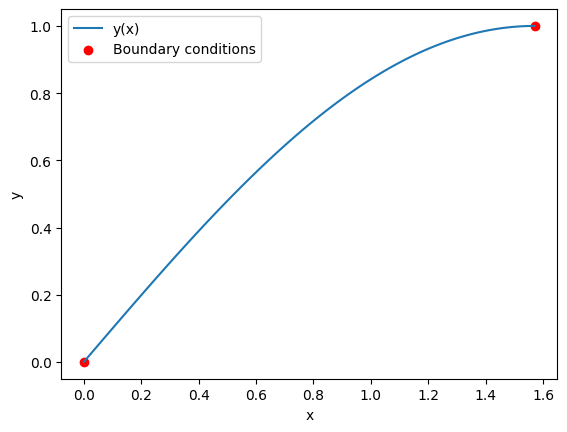

In [182]:
import numpy as np
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt

# 1. ODE system
def fun(x, y):
    # y[0] = y, y[1] = y'
    return np.vstack((y[1], -y[0]))

# 2. Define boundary conditions
def bc(ya, yb):
    # ya = y(0), yb = y(pi/2)
    return np.array([ya[0], yb[0]-1])

# 3. Provide an initial mesh and guess
x = np.linspace(0, np.pi/2, 5)
y_guess = np.zeros((2, x.size))  # 2 rows for y0, y1

# 4. Solve the BVP
sol = solve_bvp(fun, bc, x, y_guess)

# 5. Evaluate solution
x_plot = np.linspace(0, np.pi/2, 100)
y_plot = sol.sol(x_plot)[0]

# 6. Plot
plt.plot(x_plot, y_plot, label='y(x)')
plt.scatter([0, np.pi/2], [0, 1], color='red', label='Boundary conditions')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

## Solving Systems of Linear Equations -- Ch.9
- Augmented Matrix Method (Naive Gauss)
- Non-Naive Gauss Elimination
- Gauss-Jordan Elimination
- Jacobi Method
- Gauss-Seidel Method (Over- and Under-Relaxation)
- Solving Non-Linear Eqns


### Non-Naive Gauss Elimination:

- solves Ax = b
- uses scaling and pivoting that makes it diagonally dominant

$ \text{Diagonally dominant if:} $

$$ |a_{11}| > |a_{12}| > |a_{13}| +...+ |a_{1n}| $$
$$ |a_{21}| > |a_{22}| > |a_{23}| +...+ |a_{2n}| $$


In [191]:
# page 264 textbook
def pivot(A, b, s ,n, k):

    p = k
    big = abs(A[k,k] / s[k])
    for i in range(k+1, n):
        # Looking through rows to find if there is a better pivot
        # Searching for a pivot
        temp = abs(A[i,k] / s[i]) # s[i] is the largest value in the row i
        if temp > big:
            # update the best pivot
            big = temp
            p = i

    if p != k:
        temp = A[p, k:n]
        for j in range(k, n):
            # swapping elements of matrix
            A[p,  j], A[k, j] = A[k,  j], A[p, j]
        b[p], b[k] = b[k], b[p] # swap elements p and k in vector b
        s[p], s[k] = s[k], s[p] # swap elements p and k in vector s

def back_substitution(A, b):
    n = len(b)
    # vector to hold the values of x
    x = np.zeros(n)

    for i in range(n-1, -1, -1):
        sum_ax = 0
        for j in range(i+1, n):
            sum_ax += A[i,j] * x[j]
        # x_i is a leftover value
        x[i] = ((b[i] - sum_ax) / A[i,i]).item()
    return x


def gaussElim(A, b, tol=1e-9):
    # dtype of arrays and vectors must be floats
    A = A.astype(float, copy=True)
    b = b.astype(float, copy=True)

    # tolorance to checl for numerical singularity
    n = len(b)
    s = np.zeros(n)
    x = np.zeros(n)
    er = 0

    # create scale factors; biggest entry in each row
    for i in range(n):
        # pivot the matrix A at row k, using scaling
        s[i] = max(abs(A[i, :]))

    for k in range(n-1):
        # pivot matrix A at row k
        pivot(A, b, s, n, k)

        # check for numerical singularity at each row
        if abs(A[k, k] / s[k]) < tol:
            er = -1
            break

        # Gaussian Elimination operator
        for i in range(k+1, n):
            factor = A[i, k] / A[k, k]
            for j in range(k, n):
                A[i,j] -= factor * A[k, j]
            b[i] -= factor * b[k]

    if abs(A[n-1, n-1] / s[n-1]) < tol:
        er = -1

    if er != -1:
        x = back_substitution(A, b)
    
    return x, er


# Test: ----------------------------------------------------------------------------------------------------------------------------

# Test Gaussian Elimination

t_A_1 = np.array([[2, -1, 3], [4, 2, 1], [-2, 5, 7]])
t_b_1 = np.array([13, 3, 9])
# should be [1, -2, 3]
print(gaussElim(t_A_1, t_b_1)[0])

[ 1. -2.  3.]


$ \text{Gauss-Seidel Method:} $

- Solves systems of linear equations Ax = b
- works best when A is diagonally dominant
- ----------------------------------------
- Start with an initial guess x0
- Update each variable sequentially
- repeat until convergence, when the change in iterations is smaller than the convergence

Suppose we have 3 equations and 3 unknowns:


\begin{cases}
a_{11} x_1 + a_{12} x_2 + a_{13} x_3 = b_1 \\
a_{21} x_1 + a_{22} x_2 + a_{23} x_3 = b_2 \\
a_{31} x_1 + a_{32} x_2 + a_{33} x_3 = b_3
\end{cases}


Then the Gauss-Seidel updates are:


\begin{aligned}
x_1^{(k+1)} &= \frac{1}{a_{11}} \Big( b_1 - a_{12} x_2^{(k)} - a_{13} x_3^{(k)} \Big) \\
x_2^{(k+1)} &= \frac{1}{a_{22}} \Big( b_2 - a_{21} x_1^{(k+1)} - a_{23} x_3^{(k)} \Big) \\
x_3^{(k+1)} &= \frac{1}{a_{33}} \Big( b_3 - a_{31} x_1^{(k+1)} - a_{32} x_2^{(k+1)} \Big)
\end{aligned}


$\text{Successive Relaxation:} $

$$
x_i^{(k+1)} = (1 - \omega) x_i^{(k)} + \omega \left( \frac{1}{a_{ii}} \left( b_i - \sum_{j=1}^{i-1} a_{ij} x_j^{(k+1)} - \sum_{j=i+1}^{n} a_{ij} x_j^{(k)} \right) \right)
$$

$\text{where } $
\begin{cases}
0 < \omega < 1 & \text{under-relaxation (slower but stable)} \\
\omega = 1 & \text{classic Gauss-Seidel} \\
1 < \omega < 2 & \text{over-relaxation (faster if stable)}
\end{cases}

In [203]:
# A is coefficient matrix
# b is right-hand vector
# x0 is an initial guess
def gauss_seidel(A, b, x0, tol=1e-10, max_iterations=1000):

    n = len(A)
    x = x0[:]

    for iteration in range(max_iterations):
        x_new = x[:]
        for i in range(n):
            sum1 = sum(A[i][j] * x_new[j] for j in range(i))
            sum2 = sum(A[i][j] * x[j] for j in range(i + 1, n))
            x_new[i] = (b[i] - sum1 - sum2) / A[i][i]

        # Check for convergence
        if all(abs(x_new[i] - x[i]) < tol for i in range(n)):
            return x_new

        x = x_new

    return x  # Return last iteration if did not converge

# Example usage
A = [[4, 1, 2],
     [3, 5, 1],
     [1, 1, 3]]
b = [4, 7, 3]

solution = gauss_seidel(A, b, [0, 0, 0])
print("Method 1 Solution:", solution)



# Method 2: Successive Overrelaxation and Underrelaxation -----------------------------------------------------------------------------------------------------------------------------


def gauss_seidel_relaxed(A, b, x0, tol=1e-10, max_iterations=1000, omega=1.0):

    n = len(A)
    x = x0[:]

    for iteration in range(max_iterations):
        x_new = x[:]
        for i in range(n):
            # standard Gauss-Seidel update
            sum1 = sum(A[i][j] * x_new[j] for j in range(i))
            sum2 = sum(A[i][j] * x[j] for j in range(i+1, n))
            gs_value = (b[i] - sum1 - sum2) / A[i][i]

            # apply relaxation
            x_new[i] = (1 - omega) * x[i] + omega * gs_value

        # convergence check
        if all(abs(x_new[i] - x[i]) < tol for i in range(n)):
            return x_new

        x = x_new

    return x

solution2 = gauss_seidel(A, b, [0, 0, 0])
print("Method 2 Solution:", solution2)

Method 1 Solution: [0.500000000016384, 0.9999999999934465, 0.49999999999672323]
Method 2 Solution: [0.500000000016384, 0.9999999999934465, 0.49999999999672323]


<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

## Optimization Methods (Unconstrained Optimization) -- Ch.13/14
- Golden-Section Search Method
- Parabolic Interpolation
- Newton's Method
- scipy.optimize
- Powell's Method (Univariate Search)
- Gradient Methods (Steepest Ascent/Descent)
- Optimal Steepest Ascent Method





### Golden-Section Search Method

- Derivative-free
- works on unimodal functions (just 1 minimum in an interval)
- Iteratively narrows the search interval using the golden ratio
- bracketed method

### Process:

- Start with an interval
[a,b] where the minimum lies.
- Pick two points inside the interval, dividing it according to the golden ratio.
- Evaluate the function at these points.
- Keep the half that contains the smaller function value (because the minimum must be there).
- Repeat until the interval is sufficiently small.
- Why the golden ratio?
- It ensures that only one new function evaluation is needed per step, because the other point can be reused.
This makes the algorithm efficient.

In [190]:
def golden_section_search(fn, args=(), xl=0, 
                  xu=100, tol=1e-5):
    # Golden Ratio
    R = (5**0.5 -1)/2
    low = xl
    high = xu
    # initial interval width
    h = high - low
    iter = 1
    d = R*(high - low)
    # intermediate points
    x1 = low + d
    x2 = high - d
    # evaluating function at 
    # first/second intermediate points
    f1 = fn(x1, *args)
    f2 = fn(x2, *args)
    
    while h > tol:
        if f1 < f2:
            low = x2
            x2 = x1
            f2 = f1
            h = high - low
            x1 = low + R*h
            f1 = fn(x1, *args)
        else:
            high = x1
            x1 = x2
            f1 = f2
            h = high - low
            x2 = high - R*h
            f2 = fn(x2, *args)

    # Split the difference of the final interval
    x = 0.5*(low + high)
    return (x, fn(x, *args))


# Test: ----------------------------------------------------------------------------------------------------------------------------


# Function to minimize
def f(x):
    return (x - 2)**2 + 1

x_min, f_min = golden_section_search(f)
print("Minimum at x =", x_min)
print("Minimum value =", f_min)

Minimum at x = 1.9999979819300189
Minimum value = 1.0000000000040725


### Newton's Method for Optimization

- Uses Newton's root-finding method
- example is wanting to minimize a function f(x)
- figure out its derivative and second derivative

In [204]:
def newton_optimize(f_prime, f_double_prime, x0, tol=1e-10, max_iterations=1000):

    x = x0
    for iteration in range(max_iterations):
        f1 = f_prime(x)
        f2 = f_double_prime(x)
        
        if f2 == 0:
            print("Zero second derivative. Stopping.")
            return x
        
        x_new = x - f1 / f2
        
        if abs(x_new - x) < tol:
            return x_new
        
        x = x_new
    
    return x


# Test run -------------------------

# Derivatives
def f_prime(x):
    return 2*x - 4

def f_double_prime(x):
    return 2

# Initial guess
x0 = 0

minimum = newton_optimize(f_prime, f_double_prime, x0)
print("Local optimum at x =", minimum)

Local optimum at x = 2.0


$ \text{Univariate Search / Powell's Method: } $

In [ ]:
from scipy.optimize import minimize_scalar


def univariate_search(fn, x0, tol=1e-6, 
                      maxiter=1000):
    x, y = x0
    path = [(x, y)]
    fn_min = fn(x, y)
    error = 999

    for i in range(maxiter):

        if error < tol:
            break

        # Optimize along x while keeping y fixed
        res = minimize_scalar(fun = lambda z: fn(z, y))
        x = res.x
        path.append((x, y))

        fn_new = fn(x, y)
        error = np.abs((fn_new - fn_min) / fn_new)
        fn_min = fn_new

        if error < tol:
            break
        
        # Optimize along y while keeping x fixed
        res = minimize_scalar(fun = lambda z: fn(x, z))
        y = res.x
        path.append((x, y))

        fn_new = fn(x, y)
        error = np.abs((fn_new - fn_min) / fn_new)
        fn_min = fn_new

    return np.array([x, y]), len(path), np.array(path)

initial = np.array([-2, -2])
univariate_result, univariate_iters, \
univariate_path = univariate_search(streamfn, initial)

print("Result at Minimum:")
print("[x, y] = ", univariate_result)
print("Ψ(x, y) = ", streamfn(univariate_result[0], 
                             univariate_result[1]))
print("Path taken: ", univariate_path)

$ \text{Steepest Descent and Optimal Steepest Descent Methods:} $

In [ ]:
# Steepest Descent Method

# Second Order Center FDD Formula - Error = O(dx^2)
# Approximation for first derivative
def second_CFD1(f, x, y, dx=1e-2, method='x'):
    if method == 'x':
        cfd2_x = (f(x + dx, y) - f(x - dx, y)) / (2*dx)
        return(cfd2_x)
    
    else:
        cfd2_y = (f(x, y + dx) - f(x, y - dx)) / (2*dx)
        return(cfd2_y)


def gradient_method(f, p0, h = 2e-2, tol=5e-6):
    x, y = p0
    coords = [(x, y)]
    while True:
        fdx = second_CFD1(f, x, y, method="x")
        fdy = second_CFD1(f, x, y, method="y")
        slope = np.sqrt(fdx**2 + fdy**2)
        if slope < tol:
            return (x, y), f(x, y), coords
        x += h * fdx
        y += h * fdy
        coords.append((x, y))


# Optimal Steepest Descent Method

def optimal_gradient_method(f, p0, h = 2e-2, tol=5e-6):
    # initial declaration
    x, y = p0
    coords = [(x, y)]

    # finding slope and size
    while True:
        fdx = second_CFD1(f, x, y, method="x")
        fdy = second_CFD1(f, x, y, method="y")
        slope = np.sqrt(fdx**2 + fdy**2)
        if slope < tol:
            return (x, y), f(x, y), coords
        hx = h * fdx
        hy = h * fdy

        # choosing highest point in direction of the gradient
        while True:
            fx = f(x, y)
            x_temp = x + hx
            y_temp = y + hy
            if f(x_temp, y_temp) > fx:
                x = x_temp
                y = y_temp
            # needed to break out of infinite while loop
            else:
                break
        coords.append((x, y))

# could also implement a Hessian version of this, but not super necessary, unless there is a saddle point.

# Another Way to do Steepest Descent ------------------------------------------------------------------------------------------------------------------------------------------

def streamfn(x, y):
    return(-np.exp(-(x-1)**2-(y-0.5)**2) 
           + 0.5*x**2 + y**2 - 0.5*(x-1)*(y-0.5))

# defining the gradient function I calculated before
def gradient(x, y):
    dpsi_dx = 2*(x-1)*np.exp(-(x-1)**2 
                        -(y-0.5)**2) + x -0.5*y + 0.25
    dpsi_dy = 2*(y-0.5)*np.exp(-(x-1)**2 
                        -(y-0.5)**2) + 2*y -0.5*x + 0.5
    return np.array([dpsi_dx, dpsi_dy])

# Method to get from one point to the next
def psi_point_iterations(x, h, g):
    return streamfn(x[0] - h*g[0], x[1] - h*g[1])

# Steepest descent method
def steepest_descent(fn, gradient, x0, 
                     max_iter=1000, tol=1e-6):
    x = np.array(x0, dtype=float)
    history=[x.copy()]
    iter_count = 0
    error = tol + 1
    g = gradient(x[0], x[1])
    while iter_count < max_iter and error > tol:
        res = minimize_scalar(psi_point_iterations, 
                              args=(x, g))
        h = res.x

        x_new = x - (h*g)
        history.append(x_new)

        error = max(np.abs(x_new[0]-x[0]), np.abs(x_new[1]-x[1])) / (max(np.abs(x_new[0]), np.abs(x_new[1]))+1e-20) 

        x=x_new
        iter_count +=1
    return x, fn(x[0], x[1]), iter_count, np.array(history)


x0 = [-2, -2]
x_final, psi_min, iterations, history = steepest_descent(streamfn, gradient, x0)


print("Final Position:", x)
print("Minimum: ", psi_min)
print("Number of Iterations: ", iterations)

<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

## Linear Programming (Constrained Optimization) -- Ch.15
- The Simplex Method
- optimize.minimize_scalar
- Stochastic Methods (Random Search, Simulated Annealing)

$ \text{The Simplex Method: } $

- Follows a selective path through extreme points to determine optimum. 
- Assumes the optimal solution is an extreme point. 
- Find extreme using constraint equations
- Apply slack variables to reformulate constraint equations as inequalities

### Example:
Og is the leader of the surprisingly mathematically advanced, though technologically run-of-the-mill, Calm Waters caveman tribe.  He must decide on the number of stone clubs and stone axes to be produced for the upcoming battle against the neighboring Peaceful Sunset tribe.  Experience has taught him that each club is good for, on the average, 0.45 kills and 0.65 maims, while each axe produces 0.70 kills and 0.35 maims.  Production of a club requires 5.1 lb of stone and 2.1 man-hours of labor while an axe requires 3.2 lb of stone and 4.3 man-hours of labor.  Og’s tribe has 240 lb of stone available for weapons production, and a total of 200 man-hours of labor available before the expected time of this battle (that Og is sure will end war for all time).  Og values a kill as worth 2 maims in quantifying the damage inflicted on the enemy, and he wishes to produce that mix of weapons that will maximize damage.

#### Maximizing Function:

x_1 is the number of clubs, and x_2 is the number of axes

$$ Z = 1.75 x_1 + 1.40 x_2 $$

### Constraints: 

$$ 5.11 x_1 + 3.2 x_2 \leq 240 $$
$$ 2.1 x_1 + 4.3 x_2 \leq 200 $$

$$ x_1 \geq 0 $$
$$ x_2 \geq 0 $$

$ \text{Tableau:} $

| Basis   | x1   | x2   | S1  | S2  | Solns |
|---------|------|------|-----|-----|-------|
| S1      | 5.1  | 3.2  | 1   | 0   | 240   |
| S2      | 2.1  | 4.3  | 0   | 1   | 200   |
| Damage  | -1.75| -1.40| 0   | 0   | 0     |

### Linear Programming Problem – Step-by-Step Simplex Tableaus

**Initial Tableau:**

$$
\begin{array}{c|cc|cc|c}
\text{Basis} & x_1 & x_2 & S_1 & S_2 & \text{Solns} \\
\hline
S_1 & 5.1 & 3.2 & 1 & 0 & 240 \\
S_2 & 2.1 & 4.3 & 0 & 1 & 200 \\
\hline
\text{Damage} & -1.75 & -1.40 & 0 & 0 & 0
\end{array}
$$

---

### Step 1: Pivot on \(x_1\) (most negative in Damage row)

$ \text{Determine Pivot Row:} $

$$ 240 / 5.1 \approx 47$$
$$ 200 / 2.1 \approx 95 $$

- **Entering variable:** \(x_1\)  
- **Leaving variable:** \(S_1\) (smallest ratio \(240/5.1 \approx 47.06\))  
- **Pivot element:** 5.1  

**New Tableau after pivoting on \(x_1\):**

$$
\begin{array}{c|cc|cc|c}
\text{Basis} & x_1 & x_2 & S_1 & S_2 & \text{Solns} \\
\hline
x_1 & 1 & 0.627 & 0.196 & 0 & 47.06 \\
S_2 & 0 & 2.983 & -0.412 & 1 & 101.17 \\
\hline
\text{Damage} & 0 & -0.304 & 0.343 & 0 & 82.36
\end{array}
$$

---

### Step 2: Pivot on \(x_2\) (next most negative in Damage row)

$ \text{Determine Next Pivot Row:} $

$$ 47.06 / 0.627 \approx 75.0$$
$$ 101.17 / 2.983 \approx 33.9 $$

- **Entering variable:** \(x_2\)  
- **Leaving variable:** \(S_2\) (smallest ratio \(101.17/2.983 \approx 33.92\))  
- **Pivot element:** 2.983  

**New Tableau after pivoting on \(x_2\):**

$$
\begin{array}{c|cc|cc|c}
\text{Basis} & x_1 & x_2 & S_1 & S_2 & \text{Solns} \\
\hline
x_1 & 1 & 0 & 0.283 & -0.210 & 25.79 \\
x_2 & 0 & 1 & -0.138 & 0.335 & 33.92 \\
\hline
\text{Damage} & 0 & 0 & 0.301 & 0.102 & 92.63
\end{array}
$$

---

### Step 3: Check for optimality

- All entries in Damage row \(\ge 0\) ✅  
- No further pivots required.

---

### Optimal Solution:

$$
x_1 = 25.79 \text{ clubs}, \quad x_2 = 33.92 \text{ axes}, \quad \text{Total Damage} = 92.63
$$


In [98]:
# NOTES -----------------------------------------------------------------------------------------------------------------------
# 
# -----------------------------------------------------------------------------------------------------------------------------

#linprog(c, A_ub=None, b_ub=None, A_eq=None, b_eq=None, bounds=(0, None), method='highs')
# Maximizing Function (c)
Z = [-1.75, -1.40]
# A_ub
A = [[5.1, 3.2], [2.1, 4.3]]
# b_ub
b = [240, 200]
solve = linprog(Z, A, b, bounds = (0, None), method='highs')


# I use math.floor to return a physical integer value of clubs and axes needed
# A decimal value of these tools does not make sense
# clubs
# print(solve.x[0]) = 25.77
print(f"Number of Clubs Needed: {math.floor(solve.x[0])}")
# axes
# print(solve.x[1]) = 33.93
print(f"Number of Axes Needed: {math.floor(solve.x[1])}")
# damage
num_clubs = math.floor(solve.x[0])
num_axes = math.floor(solve.x[1])
damage = 1.75*num_clubs + 1.40*num_axes
print(f"Total Damage: {damage:.2f} damage units")

Number of Clubs Needed: 25
Number of Axes Needed: 33
Total Damage: 89.95 damage units


$ \text{Calculate Feasible Corner Points and Graph:} $

### Feasible Corner Points – Linear Programming

**Step 1: Solve for the intersection of the two constraints**

Constraints:

$$
\begin{cases}
5.1 x_1 + 3.2 x_2 = 240 \\
2.1 x_1 + 4.3 x_2 = 200
\end{cases}
$$

Solve the system for \(x_1\) and \(x_2\):

$$
\text{From first equation: } x_1 = \frac{240 - 3.2 x_2}{5.1}
$$

Substitute into second equation:

$$
2.1 \left(\frac{240 - 3.2 x_2}{5.1}\right) + 4.3 x_2 = 200
$$

Simplify:

$$
\frac{2.1 \cdot 240 - 2.1 \cdot 3.2 x_2}{5.1} + 4.3 x_2 = 200
$$

$$
\frac{504 - 6.72 x_2}{5.1} + 4.3 x_2 = 200
$$

$$
98.82 - 1.318 x_2 + 4.3 x_2 = 200
$$

$$
2.982 x_2 = 101.18
$$

$$
x_2 \approx 33.96
$$

Substitute back to find \(x_1\):

$$
x_1 = \frac{240 - 3.2 \cdot 33.96}{5.1} \approx 25.70
$$

**Intersection point (optimal corner):**

$$
x_1 = 25.70, \quad x_2 = 33.96
$$

---

### Step 2: Find other feasible corner points (axes intersections)

**Constraint 1:** 

\(5.1 x_1 + 3.2 x_2 = 240\)

$$ x_2 = 0 \Rightarrow x_1 = \frac{240}{5.1} \approx 46.97 
$$

$$ x_1 = 0 \Rightarrow x_2 = \frac{240}{3.2} \approx 75.00 
$$

**Constraint 2:** 
\(2.1 x_1 + 4.3 x_2 = 200\)

$$ x_2 = 0 \Rightarrow x_1 = \frac{200}{2.1} \approx 95.24
$$  

$$ x_1 = 0 \Rightarrow x_2 = \frac{200}{4.3} \approx 46.51 
$$

---

### Step 3: Summary Table of Feasible Corner Points

$$
\begin{array}{c|c|c}
\text{Corner Point} & x_1 & x_2 \\
\hline
\text{Intersection (optimal)} & 25.70 & 33.96 \\
\text{Constraint 1 on } x_1\text{-axis} & 46.97 & 0 \\
\text{Constraint 1 on } x_2\text{-axis} & 0 & 75.00 \\
\text{Constraint 2 on } x_1\text{-axis} & 95.24 & 0 \\
\text{Constraint 2 on } x_2\text{-axis} & 0 & 46.51 \\
\text{Constraint 3 on } \text{origin} & 0 & 0
\end{array}
$$


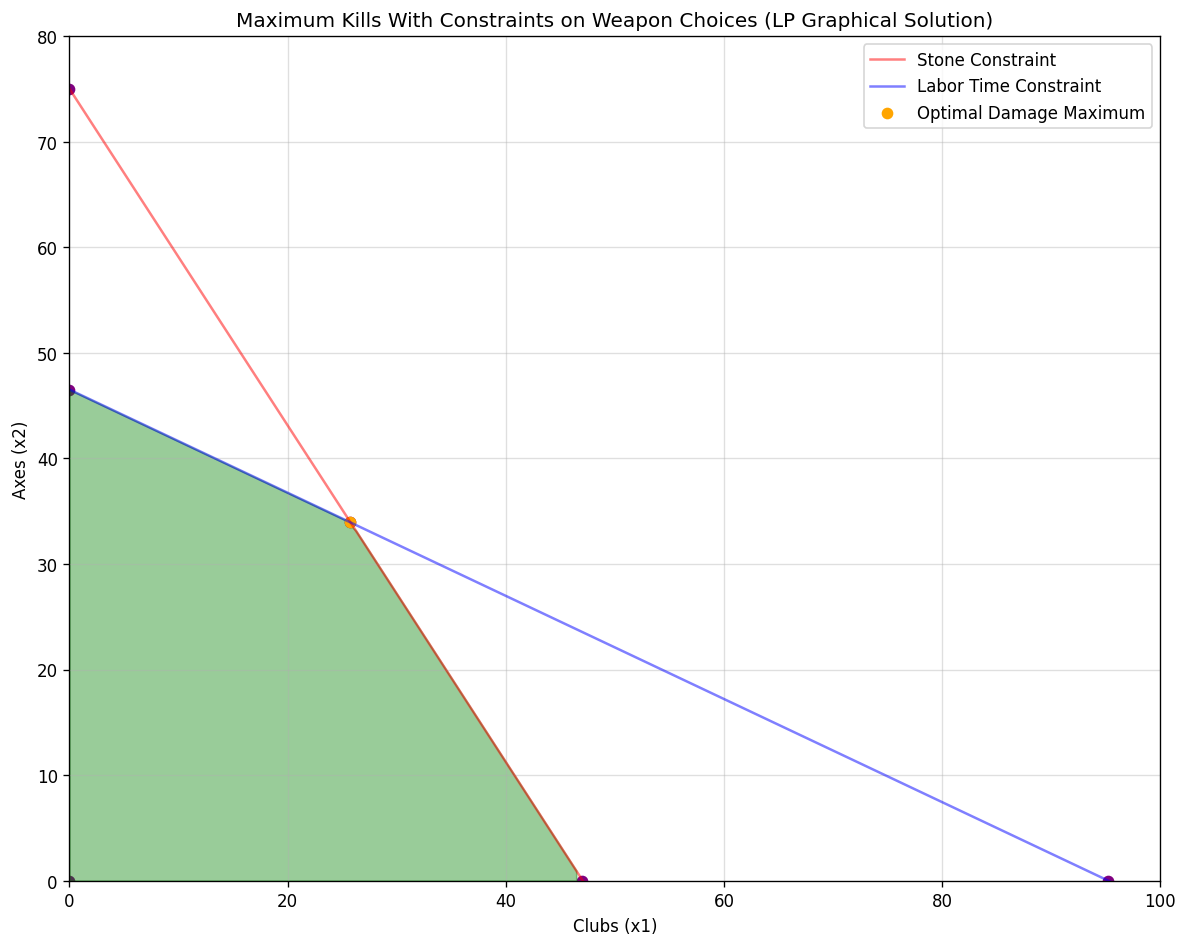

In [99]:
x = np.linspace(0, 100, 100)

# Constraint Equations
# stone constraint - solved for x2 (axes)
C1 = (240-(5.1 * x)) / 3.2
# labor constaint = solved for x2 (axes)
C2 = (200 - (2.1 * x)) / 4.3

# list of valuable coordinates
# Calculated on paper
x1_coords = [0, 46.97, 0, 95.24, 0, 25.70]
x2_coords = [0, 0, 75.00, 0, 46.51, 33.96]


plot = plt.figure(figsize=(10, 8), dpi=120)

for i in range(len(x1_coords)):
    plt.scatter(x1_coords[i], x2_coords[i], color="purple")

plt.plot(x, C1, color="red", alpha=0.5, label="Stone Constraint")
plt.plot(x, C2, color="blue", alpha=0.5, label="Labor Time Constraint")

# shading certain section of the plot for feasible regions
# Axes.fill_between(x, y1, y2=0, where=None, 
# interpolate=False, step=None, *, data=None, 
# **kwargs)
plt.fill_between(x, 0, np.minimum(C1, C2), 
                 where=(C2 >= 0) & (C1 >= 0), 
                 color="green", alpha=0.4)

plt.scatter(x1_coords[5], x2_coords[5], color="orange", label="Optimal Damage Maximum")

plt.xlabel("Clubs (x1)")
plt.ylabel("Axes (x2)")
plt.title("Maximum Kills With Constraints on Weapon Choices (LP Graphical Solution)")
plt.legend()
plt.xlim(0, 100)
plt.ylim(0, 80)
plt.grid(alpha=0.4)
plt.tight_layout()

<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

## PREVIOUS PSETS

$$ \textbf{PSET 1: }$$

Graphing Tools and Methods:

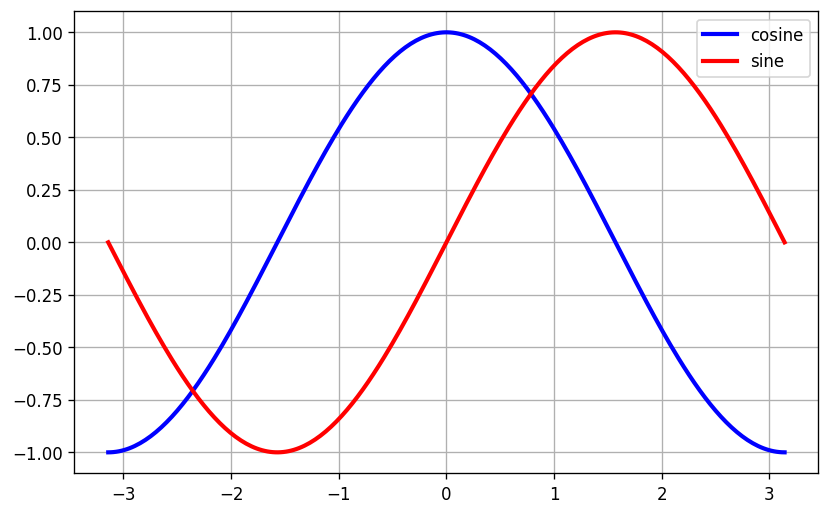

In [59]:
plt.figure(figsize=(8, 5), dpi=120)
plt.subplot(111)

X = np.linspace(-np.pi, np.pi, 256, endpoint=True)
C = np.cos(X)
S = np.sin(X)

plt.plot(X, C, color="blue", linewidth=2.5, linestyle="-", label="cosine")
plt.plot(X, S, color="red", linewidth=2.5, linestyle="-", label="sine")

plt.xlim(X.min() * 1.1, X.max() * 1.1)
plt.ylim(C.min() * 1.1, C.max() * 1.1)

plt.grid()
plt.legend()
plt.show()

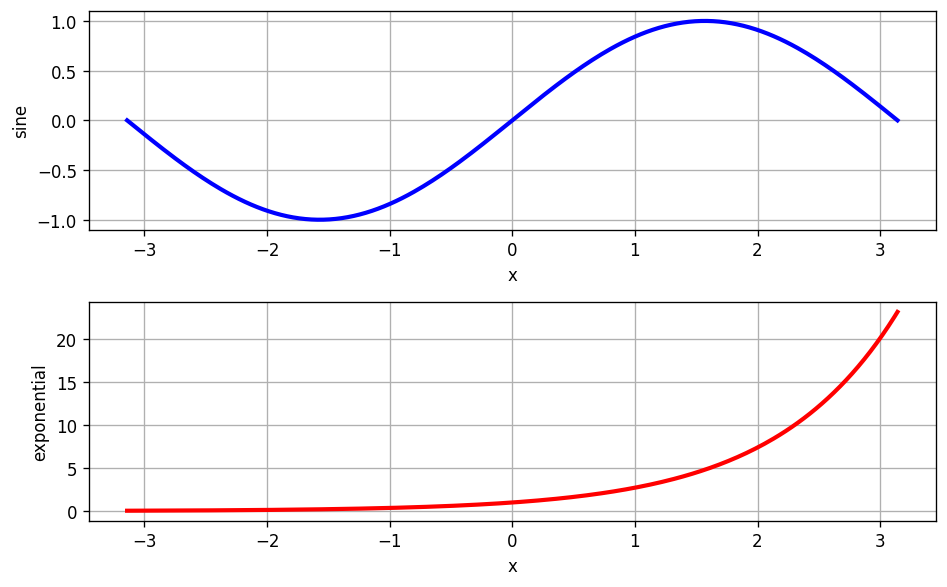

In [60]:
plt.figure(figsize=(8, 5), dpi=120)
ax = plt.subplot(2, 1, 1)

X = np.linspace(-np.pi, np.pi, 256, endpoint=True)
sin = np.sin(X)
exp = np.exp(X)

plt.plot(X, sin, color="blue", linewidth=2.5, linestyle="-")
ax.set_xlabel("x")
ax.set_ylabel("sine")

ax2 = plt.subplot(2, 1, 2)
plt.plot(X, exp, color="red", linewidth=2.5, linestyle="-")
ax2.set_xlabel("x")
ax2.set_ylabel("exponential")

ax.grid()
ax2.grid()
plt.tight_layout()
plt.show()

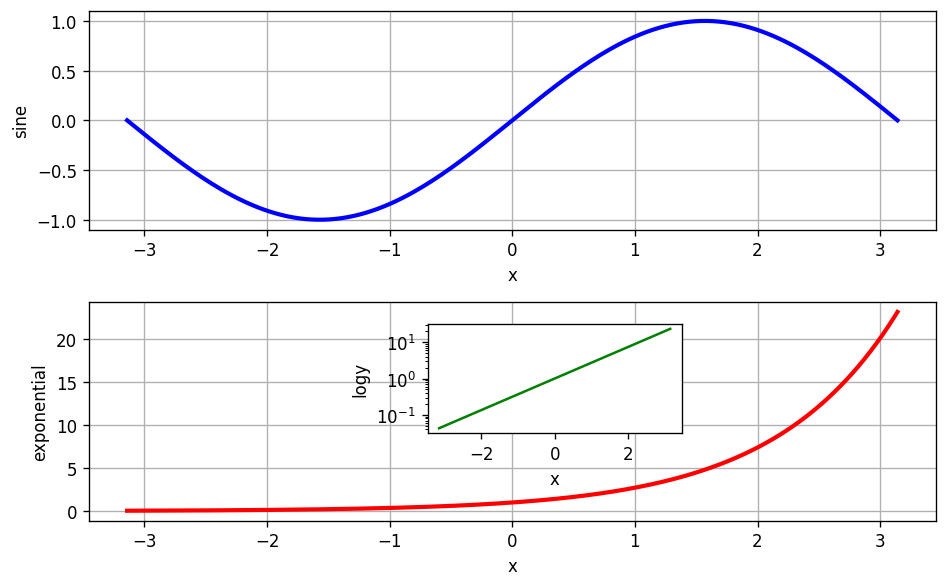

In [61]:
plt.figure(figsize=(8, 5), dpi=120)
ax = plt.subplot(2, 1, 1)

X = np.linspace(-np.pi, np.pi, 256, endpoint=True)
sin = np.sin(X)
exp = np.exp(X)

ax.plot(X, sin, color="blue", linewidth=2.5, linestyle="-", label="sine")
ax.set_xlabel("x")
ax.set_ylabel("sine")

ax2 = plt.subplot(2, 1, 2)
ax2.plot(X, exp, color="red", linewidth=2.5, linestyle="-")
ax2.set_xlabel("x")
ax2.set_ylabel("exponential")
inset = ax2.inset_axes([0.4, 0.4, 0.3, 0.5])
inset.semilogy(X, exp, color="green")
inset.set_xlabel("x")
inset.set_ylabel("logy")

ax.grid()
ax2.grid()
plt.tight_layout()
plt.show()

Array Comparisons:

In [62]:
# Write an efficient function that compares two 2D arrays A and B,
# and returns a True value if the arrays are identical and a False 
# value if the arrays are not identical.  

def compare_array(A, B):
    if len(A) != len(B):
        return False
    for i in range(len(A)):
        if len(A[i]) != len(B[i]):
            return False
        for j in range(len(A[i])):
            if A[i][j] != B[i][j]:
                return False
    return True

In [63]:
# Test Method above on two arrays:
M = 32
N = 64
xmin = ymin = 0.0
xmax = ymax = 1.0
x = np.linspace(xmin, xmax, M, endpoint=False)
y = np.linspace(ymin, ymax, N, endpoint=False)

g = np.zeros((M, N))
for i in range(M):
    for j in range(N):
        g[i,j] = np.sin(2.0*np.pi*x[i]*y[j])
        
x2d, y2d = np.meshgrid(x, y, indexing="ij")
g2 = np.sin(2.0*np.pi*x2d*y2d)

def compare_array(g, g2):
    if len(g) != len(g2):
        return False
    for i in range(len(g)):
        if len(g[i]) != len(g2[i]):
            return False
        for j in range(len(g[i])):
            if g[i][j] != g2[i][j]:
                return False
    return True

print(compare_array(g, g2))

True


$$ \textbf{PSET 2: }$$

Bisection Depth Prediction: 0.9735260009765625 meters
False Position Depth Prediction: 0.9735307209755165 meters


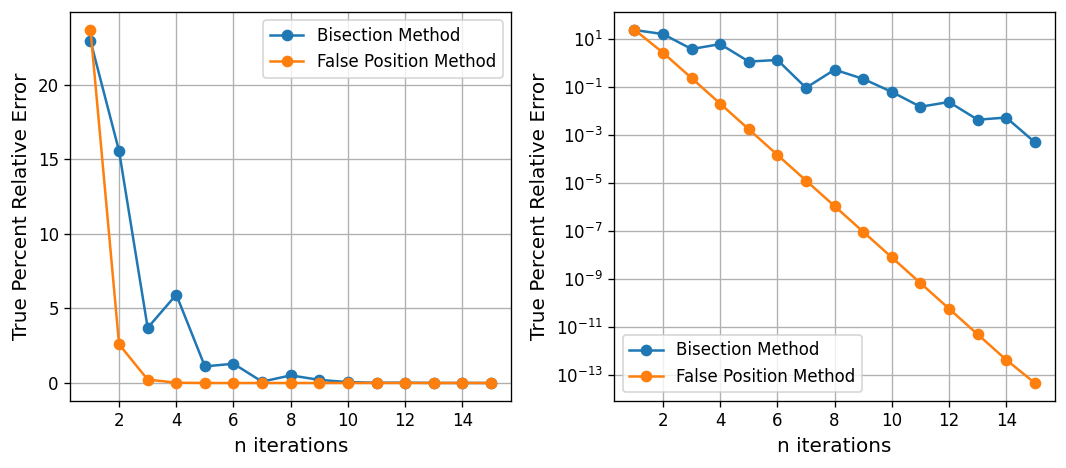

In [64]:
# QUESTION 1 ------------------------------------------------------------------------------------------
# (a)	Write a function `V(h)` to compute the container volume as a function of depth.

def V(h):
    R = 1.5
    return (np.pi*h**2)*((3*R-h)/3)

# (b)	Write a function `depth_solve_bisect(V_fill, lower, upper, n)` to determine the depth
# of liquid in the container when it holds a volume of $V$_$fill$.  This function should use
# the bisect method with initial bounds $[lower, upper]$ and $n$ iterations.  What minimum depth
# of liquid do you calculate, using 15 iterations and initial bounds of $0$ and $R$, is required
# for the student to have sufficient liquid nitrogen?

def depth_solve_bisect(V_fill, lower, upper, n):
    def desired_volume(h):
        return V(h) - V_fill
    
    if desired_volume(lower)*desired_volume(upper) > 0:
       print("No roots identified in domain [{:}, {:}]".format(lower, 
                                                               upper))
       return()
       
    iterable_guess = []
    for i in range(n):
        bisection = (lower + upper) / 2 #root bisection 
        iterable_guess.append(bisection) 
        
        test = desired_volume(lower) * desired_volume(bisection)
        if test < 0:
            upper = bisection
        else:
            lower = bisection
    
    return(bisection, iterable_guess)

print(f"Bisection Depth Prediction:", 
      depth_solve_bisect(3.5, 0, 1.5, 15)[0], "meters") 

# (c)	Write a function `depth_solve_fp(V_fill, lower, upper, n)` to determine the minimum depth such
# that there is sufficient liquid available.  This function should use the false-position method with
# initial bounds $[lower, upper]$ and $n$ iterations.  What minimum depth do you get using 15 iterations
# and initial bounds of $0$ and $R$?

def depth_solve_fp(V_fill, lower, upper, n):
    def desired_volume(h):
        return V(h) - V_fill
    
    if desired_volume(lower)*desired_volume(upper) > 0:
       print("No roots identified in domain [{:}, {:}]".format(lower, 
                                                               upper))
       return()
    
    iterable_guess = []
    for i in range(n):
        fp = upper - ((desired_volume(upper)*(lower - upper))/
                      (desired_volume(lower)
                     - desired_volume(upper))) #False-Position formula
        iterable_guess.append(fp)  
        test = desired_volume(lower) * desired_volume(fp)
        if test < 0:
            upper = fp
        else:
            lower = fp
    
    return(fp, iterable_guess)

print(f"False Position Depth Prediction:", 
      depth_solve_fp(3.5, 0, 1.5, 15)[0], "meters") 

# **(d)	Plot on the same axes the true percent relative error of both methods as a function of $n$ over the 
# interval $[1, 15]$ to compare their rates of convergence.  Provide two plots as your solution using (i) 
# linear and (ii) semilog-y (*i.e.*, x-axis is linear, y-axis is logarithmic base 10) scales for plotting.

#Value acquired from methods
true_value = 0.97353072097551696106876306657795794308185577392578125
R = 1.5
bisect_tpre = (np.abs(np.array(depth_solve_bisect(3.5, 0, R, 15)[1]) 
                      - true_value)/(true_value)) * 100
false_position_tpre = (np.abs(np.array(depth_solve_fp(3.5, 0, R, 15)[1]) 
                      - true_value)/(true_value)) * 100

#Plotting - initializing the plot/subplots and formatting
#linear plot
fig, (ax1, ax2) = plt.subplots(figsize = (9, 4), ncols = 2, 
                               nrows = 1, dpi = 120)
iterations = np.arange(1, 16)
ax1.plot(iterations, bisect_tpre, "o-", label = "Bisection Method")
ax1.plot(iterations, false_position_tpre, "o-", 
        label = "False Position Method")
ax1.set_ylabel("True Percent Relative Error", fontsize = 12)
ax1.set_xlabel("n iterations", fontsize = 12)
ax1.grid()
ax1.legend()

#logarithmic plot
ax2.plot(iterations, bisect_tpre, "o-", label = "Bisection Method")
ax2.plot(iterations, false_position_tpre, "o-", 
         label = "False Position Method")
ax2.set_ylabel("True Percent Relative Error", fontsize = 12)
ax2.set_xlabel("n iterations", fontsize = 12)
ax2.set_yscale("log")
ax2.grid()
ax2.legend()

plt.tight_layout()


$$ \textbf{PSET 3: }$$

<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
<>:28: SyntaxWarning: invalid escape sequence '\p'
<>:31: SyntaxWarning: invalid escape sequence '\p'
/var/folders/lx/5c1y1s9170s2gm725ndxdpzr0000gn/T/ipykernel_92879/3929041147.py:28: SyntaxWarning: invalid escape sequence '\p'
  ax.set_ylabel(f"$f^\prime(\pi / 2)$")
/var/folders/lx/5c1y1s9170s2gm725ndxdpzr0000gn/T/ipykernel_92879/3929041147.py:31: SyntaxWarning: invalid escape sequence '\p'
  plt.grid()


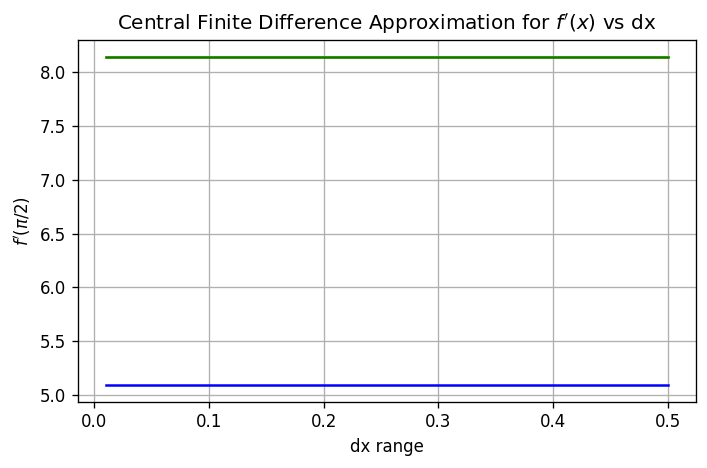

In [65]:
# Evaluate both central finite-difference approximations for $f'(\pi /2)$ for a range of $\Delta x \in [0.01, 0.5]$. 
# Plot both approximations as a function of $\Delta x$ on one plot. Include a horizontal line at the true value of $f'(x)$ 
# you computed in part (a).

dx_vals = np.linspace(0.01, 0.5, 200)

center_approx_2 = []
center_approx_4 = []

for i in dx_vals:
    center_approx_2.append(second_CFD1(f, np.pi/2, i))
    center_approx_4.append(fourth_CFD1(f, np.pi/2, i))

center_approx_2 = np.array(center_approx_2)
center_approx_4 = np.array(center_approx_4)
#print(approx)
true_val = f_prime(np.pi / 2)
# Make an array of true values the same length as the other 
# array to plot a straight line
true_array = [true_val] * len(dx_vals)

# Plotting the true value and the CFD approximated value
fig, ax = plt.subplots(figsize = (6,4), dpi = 120)
ax.plot(dx_vals, center_approx_2, color= "orange")
ax.plot(dx_vals, center_approx_4, color= "green")
ax.plot(dx_vals, true_array, color= "blue")
ax.set_xlabel("dx range")
ax.set_ylabel(f"$f^\prime(\pi / 2)$")
ax.set_title(f"Central Finite Difference Approximation \
for $f^\prime(x)$ vs dx")
plt.grid()
plt.tight_layout()

<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:35: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
<>:32: SyntaxWarning: invalid escape sequence '\p'
<>:34: SyntaxWarning: invalid escape sequence '\p'
<>:35: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\p'
/var/folders/lx/5c1y1s9170s2gm725ndxdpzr0000gn/T/ipykernel_92879/3602853691.py:32: SyntaxWarning: invalid escape sequence '\p'
  ax1.plot(dx_vals, true_array, color= "black", label = f"True Value of $f^\prime(\pi /2)$")
/var/folders/lx/5c1y1s9170s2gm725ndxdpzr0000gn/T/ipykernel_92879/3602853691.py:34: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_ylabel(f"$f^\prime(\pi / 2)$")


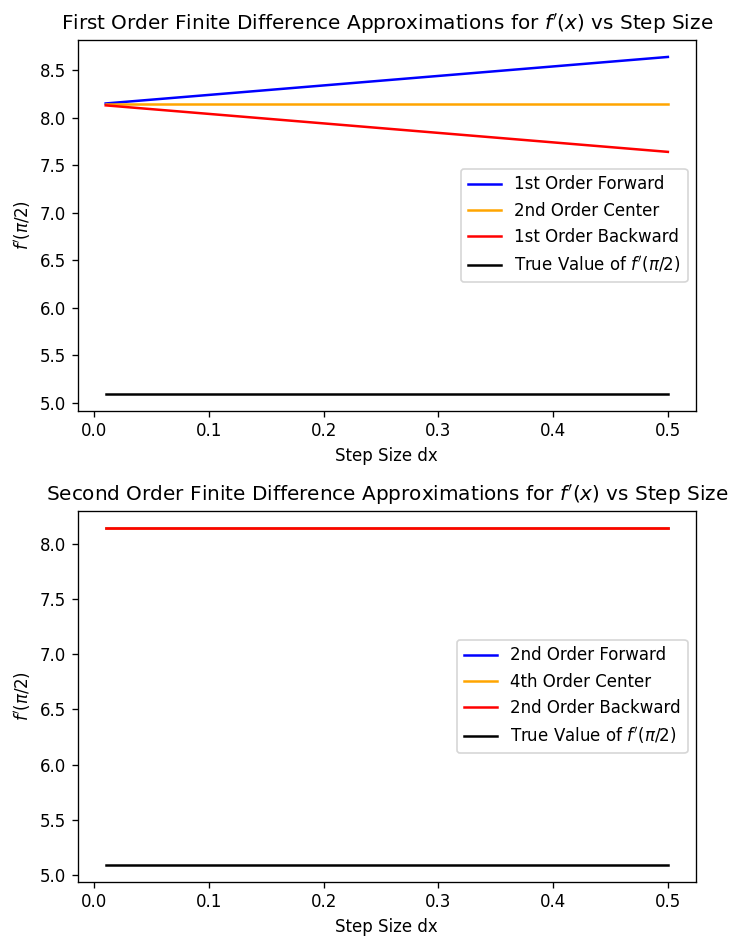

In [66]:
# Write a function/functions for the **forward** and **backward** finite-difference methods. 
# In a **single figure with two subplots**, plot the approximations for $f'(\pi /2)$ from the 
# three first-order methods (first subplot) and the three second-order methods over the same 
# range of $\Delta x \in [0.01, 0.5]$. Again, include a horizontal line with the true value of $f'(x)$.

dx_vals = np.linspace(0.01, 0.5, 200)
forward_approx1 = []
backward_approx1 = []
forward_approx2 = []
backward_approx2 = []

for i in dx_vals:
    forward_approx1.append(first_FFD(f, np.pi/2, i))
    backward_approx1.append(first_BFD(f, np.pi/2, i))
    forward_approx2.append(second_FFD(f, np.pi/2, i))
    backward_approx2.append(second_BFD(f, np.pi/2, i))

# True value
true_val = f_prime(np.pi / 2)
true_array = [true_val] * len(dx_vals)

forward_approx1 = np.array(forward_approx1)
backward_approx1 = np.array(backward_approx1)
forward_approx2 = np.array(forward_approx2)
backward_approx2 = np.array(backward_approx2)

# Plotting the true value and the CFD approximated value
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (6,8), dpi = 120)
ax1.plot(dx_vals, forward_approx1, color= "blue", label = "1st Order Forward")
ax1.plot(dx_vals, center_approx_2, color= "orange", label = "2nd Order Center")
ax1.plot(dx_vals, backward_approx1, color= "red", label = "1st Order Backward")
ax1.plot(dx_vals, true_array, color= "black", label = f"True Value of $f^\prime(\pi /2)$")
ax1.set_xlabel("Step Size dx")
ax1.set_ylabel(f"$f^\prime(\pi / 2)$")
ax1.set_title(f"First Order Finite Difference Approximations for $f^\prime(x)$ vs Step Size")
ax1.legend()

ax2.plot(dx_vals, forward_approx2, color= "blue", label = "2nd Order Forward")
ax2.plot(dx_vals, center_approx_4, color= "orange", label = "4th Order Center")
ax2.plot(dx_vals, backward_approx2, color= "red", label = "2nd Order Backward")
ax2.plot(dx_vals, true_array, color= "black", label = f"True Value of $f^\prime(\pi /2)$")
ax2.set_xlabel("Step Size dx")
ax2.set_ylabel(f"$f^\prime(\pi / 2)$")
ax2.set_title(f"Second Order Finite Difference Approximations for $f^\prime(x)$ vs Step Size")
ax2.legend()
plt.tight_layout()

<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
<>:25: SyntaxWarning: invalid escape sequence '\p'
<>:27: SyntaxWarning: invalid escape sequence '\p'
<>:30: SyntaxWarning: invalid escape sequence '\p'
/var/folders/lx/5c1y1s9170s2gm725ndxdpzr0000gn/T/ipykernel_92879/3805171110.py:25: SyntaxWarning: invalid escape sequence '\p'
  label = f"True Value of $f^\prime(\pi /2)$")
/var/folders/lx/5c1y1s9170s2gm725ndxdpzr0000gn/T/ipykernel_92879/3805171110.py:27: SyntaxWarning: invalid escape sequence '\p'
  ax1.set_ylabel(f"$f^\prime(\pi / 2)$")
/var/folders/lx/5c1y1s9170s2gm725ndxdpzr0000gn/T/ipykernel_92879/3805171110.py:30: SyntaxWarning: invalid escape sequence '\p'
  ax1.legend()


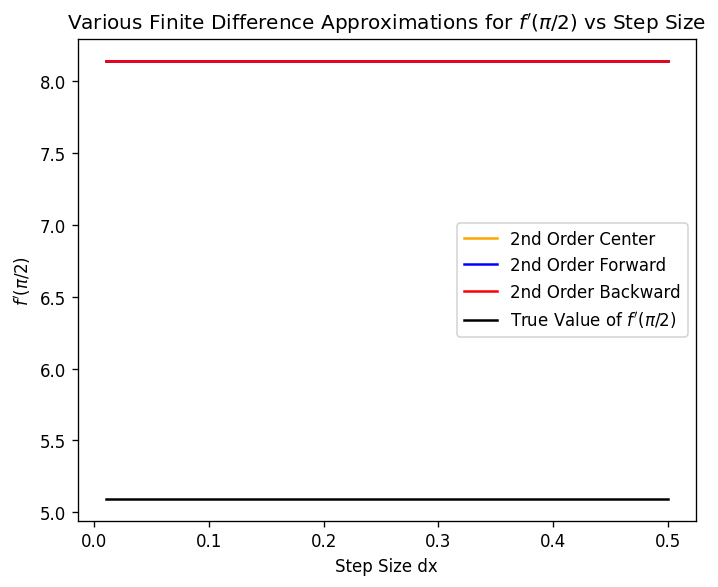

In [67]:
dx_vals = np.linspace(0.01, 0.5, 200)
forward_approx2 = []
backward_approx2 = []

for i in dx_vals:
    forward_approx2.append(second_FFD(f, np.pi/2, i))
    backward_approx2.append(second_BFD(f, np.pi/2, i))

# True value
true_val = f_prime(np.pi / 2)
true_array = [true_val] * len(dx_vals)

forward_approx2 = np.array(forward_approx2)
backward_approx2 = np.array(backward_approx2)

# Plotting the true value and the CFD approximated value
fig, ax1 = plt.subplots(figsize = (6,5), dpi = 120)
ax1.plot(dx_vals, center_approx_2, color= "orange", 
label = "2nd Order Center")
ax1.plot(dx_vals, forward_approx2, color= "blue", 
label = "2nd Order Forward")
ax1.plot(dx_vals, backward_approx2, color= "red", 
label = "2nd Order Backward")
ax1.plot(dx_vals, true_array, color= "black", 
label = f"True Value of $f^\prime(\pi /2)$")
ax1.set_xlabel("Step Size dx")
ax1.set_ylabel(f"$f^\prime(\pi / 2)$")
ax1.set_title(f"Various Finite Difference Approximations \
for $f^\prime(\pi / 2)$ vs Step Size")
ax1.legend()

plt.tight_layout()

The BFD approximation has performed the worst because of the way it cycles through values in its derivative approximation. Since the original function includes a cosine and a natural log (which, plotted on Desmos, is a very wavy function), the rapid curvature can cause the BFD to significantly over-or underestimate the derivatives. The more rapidly-changing the derivatives are, the weaker the forward and backward approximations are, because they are skewed specifically to one side. The central finite difference method is more reliable (visually, we can see that it deviates the least over large dx), because it takes the average of both sides and cancels out any truncation error. 

<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
<>:39: SyntaxWarning: invalid escape sequence '\p'
<>:57: SyntaxWarning: invalid escape sequence '\p'
/var/folders/lx/5c1y1s9170s2gm725ndxdpzr0000gn/T/ipykernel_92879/526933757.py:39: SyntaxWarning: invalid escape sequence '\p'
  
/var/folders/lx/5c1y1s9170s2gm725ndxdpzr0000gn/T/ipykernel_92879/526933757.py:57: SyntaxWarning: invalid escape sequence '\p'
  for $f^\prime(\pi/2)$ vs. Step Size")


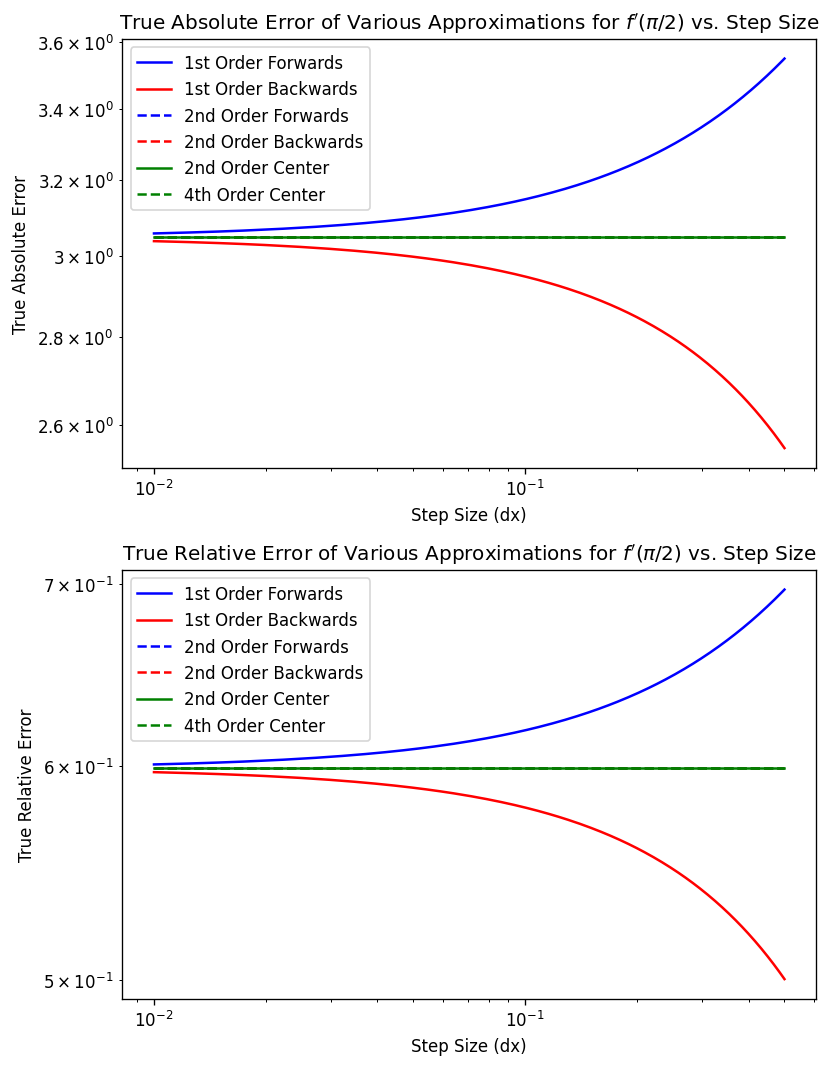

In [68]:
dx_vals = np.linspace(0.01, 0.5, 200)

tae_forwards_1 = true_array - forward_approx1
tae_backwards_1 = true_array - backward_approx1
tae_center_2 = true_array - center_approx_2
tae_forwards_2 = true_array - forward_approx2
tae_backwards_2 = true_array - backward_approx2
tae_center_4 = true_array - center_approx_4
tre_forwards_1 = tae_forwards_1 / true_array
tre_backwards_1 = tae_backwards_1 / true_array
tre_center_2 = tae_center_2 / true_array
tre_forwards_2 = tae_forwards_2 / true_array
tre_backwards_2 = tae_backwards_2 / true_array
tre_center_4 = tae_center_4 / true_array



fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (7,9), 
dpi = 120)

ax1.plot(dx_vals, np.abs(tae_forwards_1), color = "blue", 
label = "1st Order Forwards")
ax1.plot(dx_vals, np.abs(tae_backwards_1), color = "red", 
label = "1st Order Backwards")
ax1.plot(dx_vals, np.abs(tae_forwards_2), color = "blue", 
linestyle = '--', label = "2nd Order Forwards")
ax1.plot(dx_vals, np.abs(tae_backwards_2), color = "red", 
linestyle = '--', label = "2nd Order Backwards")
ax1.plot(dx_vals, np.abs(tae_center_2), color = "green", 
label = "2nd Order Center")
ax1.plot(dx_vals, np.abs(tae_center_4), color = "green", 
linestyle = '--', label = "4th Order Center")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Step Size (dx)")
ax1.set_ylabel("True Absolute Error")
ax1.set_title(f"True Absolute Error of Various Approximations \
for $f^\prime(\pi/2)$ vs. Step Size")

ax2.plot(dx_vals, np.abs(tre_forwards_1), color="blue", 
label = "1st Order Forwards")
ax2.plot(dx_vals, np.abs(tre_backwards_1), color="red", 
label = "1st Order Backwards")
ax2.plot(dx_vals, np.abs(tre_forwards_2), color="blue", 
linestyle = '--', label = "2nd Order Forwards")
ax2.plot(dx_vals, np.abs(tre_backwards_2), color="red", 
linestyle = '--', label = "2nd Order Backwards")
ax2.plot(dx_vals, np.abs(tre_center_2), color="green", 
label = "2nd Order Center")
ax2.plot(dx_vals, np.abs(tre_center_4), color="green", 
linestyle = '--', label = "4th Order Center")
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("Step Size (dx)")
ax2.set_ylabel("True Relative Error")
ax2.set_title("True Relative Error of Various Approximations \
for $f^\prime(\pi/2)$ vs. Step Size")

plt.tight_layout()
ax1.legend();
ax2.legend();

In [69]:
from scipy.stats import linregress

#Linear regression on true absolute error functions
log_dx = np.log(dx_vals)

log_tae_forward1 = np.log(np.abs(tae_forwards_1))
log_tae_backward1 = np.log(np.abs(tae_backwards_1))
log_tae_center2 = np.log(np.abs(tae_center_2))
log_tae_forward2 = np.log(np.abs(tae_forwards_2))
log_tae_backward2 = np.log(np.abs(tae_backwards_2))
log_tae_center4 = np.log(np.abs(tae_center_4))

# Need spaces because linregress returns four other 
# values that are unneeded
slope_forward1, _, _, _, _ = linregress(log_dx, 
log_tae_forward1)
slope_backward1, _, _, _, _ = linregress(log_dx, 
log_tae_backward1)
slope_center2, _, _, _, _ = linregress(log_dx, 
log_tae_center2)
slope_forward2, _, _, _, _ = linregress(log_dx, 
log_tae_forward2)
slope_backward2, _, _, _, _ = linregress(log_dx, 
log_tae_backward2)
slope_center4, _, _, _, _ = linregress(log_dx, 
log_tae_center4)

print(f"1st Order Forward Slope: {slope_forward1:.2f}")
print(f"1st Order Backward Slope: {slope_backward1:.2f}")
print(f"2nd Order Center Slope: {slope_center2:.2f}")
print(f"2nd Order Forward Slope: {slope_forward2:.2f}")
print(f"2nd Order Backward Slope: {slope_backward2:.2f}")
print(f"4th Order Center Slope: {slope_center4:.2f}")

1st Order Forward Slope: 0.05
1st Order Backward Slope: -0.06
2nd Order Center Slope: 0.00
2nd Order Forward Slope: -0.00
2nd Order Backward Slope: 0.00
4th Order Center Slope: 0.00


For the exponential function fit f(x) = A*e^(k*x),  A = 0.6218*10^3 bacteria counts and k = 0.06906 hr^(-1).
Standard Error: 0.6086
Coefficient of Determination: 0.805
Statistics of Linear Regression Residuals
Mean: 0.9993
Standard Deviation: 2.4349 

Statistics of Curve-Fit Residuals
Mean: 0.1542
Standard Deviation: 1.7188


Text(0.5, 1.0, 'Histogram of Residuals from Curve-Fit')

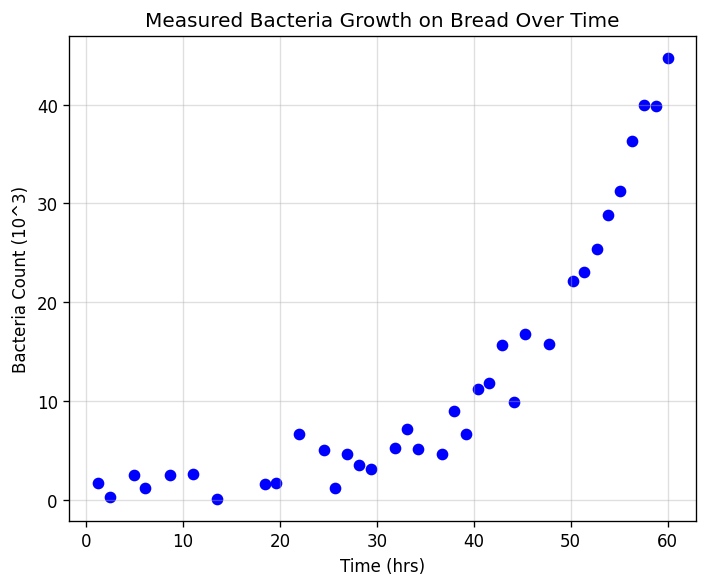

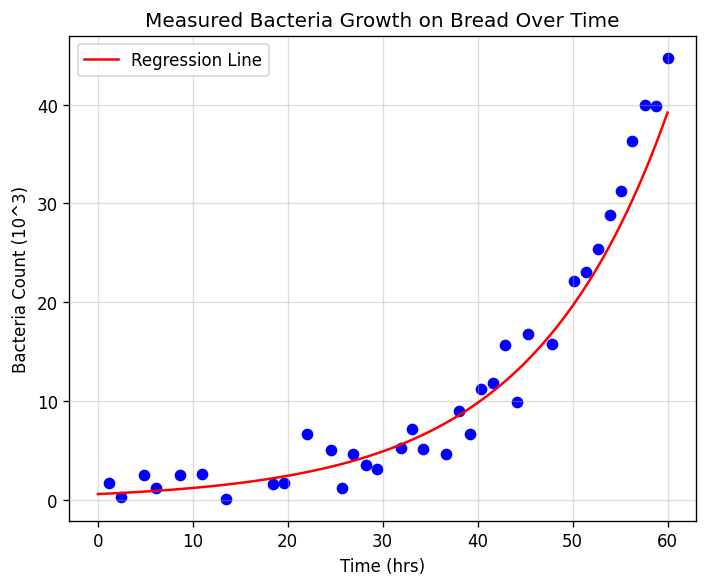

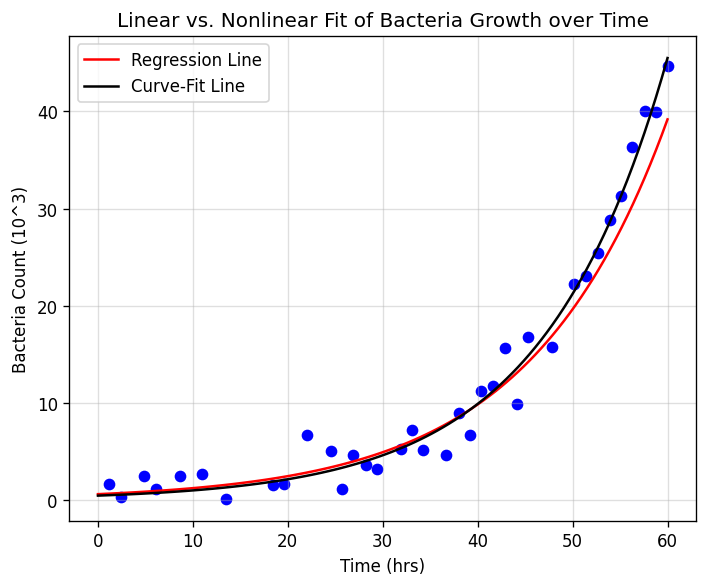

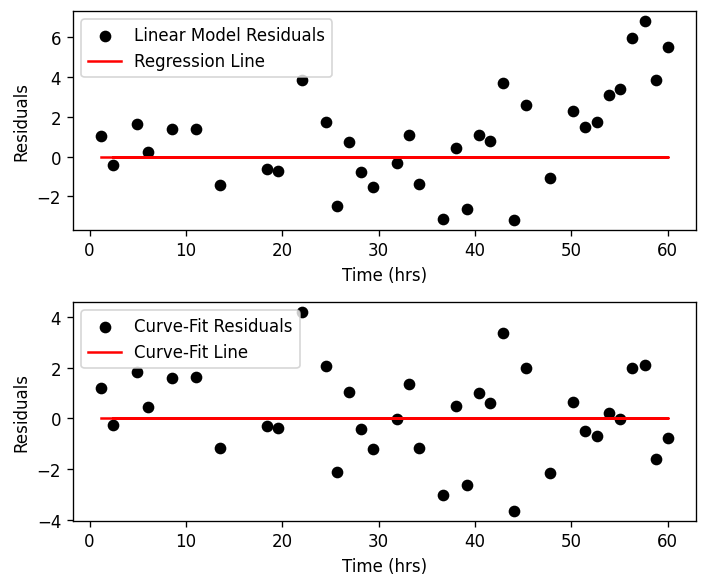

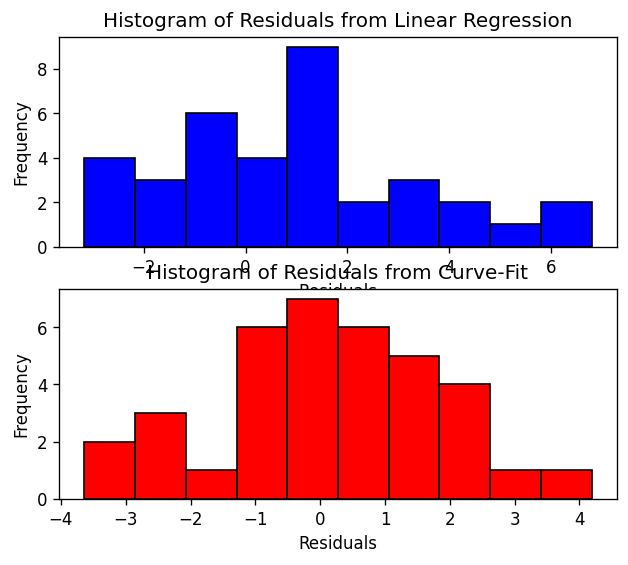

In [70]:
# PROBLEM 4 PSET 3 Residuals + Residual Bins
# -----------------------------------------------------------------------------------------------------------------------------

data = [(1.2, 1.7), (19.6, 1.7), (28.2, 3.6), (40.4, 11.2), (50.2, 22.2), (60.0, 44.7), (13.5, 0.16), (25.7, 1.2), (34.2, 5.2), \
          (44.1, 9.9), (55.1, 31.3), (58.8, 39.9), (4.9, 2.5), (11.0, 2.7), (26.9, 4.7), (36.7, 4.7), (47.8, 15.8), (53.9, 28.8), \
          (2.4, 0.3), (18.4, 1.6), (29.4, 3.2), (38.0, 9.0), (42.9, 15.7), (57.6, 40.0), (6.1, 1.2), (24.5, 5.1), (31.9, 5.3), \
          (39.2, 6.7), (45.3, 16.8), (52.7, 25.4), (8.6, 2.5), (22.0, 6.7), (33.1, 7.2), (41.6, 11.8), (51.4, 23.1), (56.3, 36.3)]

plt.figure(figsize=(6, 5), dpi=120)
for i in data:
    time = i[0]
    bacteria = i[1]
    plt.scatter(time, bacteria, color = 'blue')


plt.xlabel("Time (hrs)")
plt.ylabel("Bacteria Count (10^3)")
plt.title("Measured Bacteria Growth on Bread Over Time")
plt.grid(alpha=0.4)
plt.tight_layout()

# FITTED LINEAR REGRESSION CODE -----------------------------------------------------------------------------------------------------------------------------


data = np.array(data)
x_data = []
y_data = []

# Linearized exponential fxn: ln(y) = ln(A) + B*x 
#regression = a0 + a1 * x_data

for i in range(len(data)):
    x_data.append(data[i, 0])
    y_data.append(data[i, 1])

x_data = np.array(x_data)
y_data = np.array(y_data)

ln_y = np.log(y_data)

A, B, standard_error, r_2 = least_squares_regression(x_data, ln_y)

a0 = np.exp(A)
a1 = B

lin_x_data = np.linspace(0, 60, 100)
y_fit = a0 * np.exp(a1 * lin_x_data)
#print(y_fit)
print(f"For the exponential function fit f(x) = A*e^(k*x), \
 A = {a0:.4g}*10^3 bacteria counts and k = {a1:.4g} hr^(-1).")
print(f"Standard Error: {standard_error:.4g}")
print(f"Coefficient of Determination: {r_2:.4g}")

fig, ax1 = plt.subplots(figsize=(6, 5), dpi=120)
for i in data:
    time = i[0]
    bacteria = i[1]
    ax1.scatter(time, bacteria, color = 'blue')

ax1.plot(lin_x_data, y_fit, color="red", label = "Regression Line")
plt.xlabel("Time (hrs)")
plt.ylabel("Bacteria Count (10^3)")
plt.title("Measured Bacteria Growth on Bread Over Time")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()

# CURVE FIT CODE -----------------------------------------------------------------------------------------------------------------------------

data = np.array(data)
x_data = []
y_data = []

for i in range(len(data)):
    x_data.append(data[i, 0])
    y_data.append(data[i, 1])

x_data = np.array(x_data)
y_data = np.array(y_data)


def bacteria_func(x, A, B):
    return A * np.exp(B * x)

# curve_fit model
popt, pcov = sp.optimize.curve_fit(bacteria_func, x_data, 
y_data, p0 = [0.001, 1])

# Linearly regressed model + original data scatter plot from part b).
fig, ax1 = plt.subplots(figsize=(6, 5), dpi=120)
for i in data:
    time = i[0]
    bacteria = i[1]
    ax1.scatter(time, bacteria, color = 'blue')

# Plotted regression line
ax1.plot(lin_x_data, y_fit, color="red", label = "Regression Line")
# Plotted curve_fit line
ax1.plot(lin_x_data, bacteria_func(lin_x_data, *popt), color= "black", 
label = "Curve-Fit Line")

ax1.set_xlabel("Time (hrs)")
ax1.set_ylabel("Bacteria Count (10^3)")
ax1.set_title("Linear vs. Nonlinear Fit of Bacteria Growth over Time")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()

# PLOTTING RESIDUALS -----------------------------------------------------------------------------------------------------------------------------

# lin_x_data = np.linspace(0, 60, 100)
# y_fit = a0 * np.exp(a1 * lin_x_data)
modified_y_fit = a0 * np.exp(a1 * x_data)
curvefit = bacteria_func(x_data, *popt)

# Calculate residuals
linear_residual = y_data - modified_y_fit
curvefit_residual = y_data - curvefit

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), 
dpi=120)

ax1.scatter(x_data, linear_residual, color ="black", 
label="Linear Model Residuals");
# Plotting a straight line at 0 for some visual clarity
ax1.plot(x_data, [0]*len(x_data), color="red", 
label="Regression Line")
ax1.set_xlabel("Time (hrs)")
ax1.set_ylabel("Residuals")
ax1.set_title("")
ax1.legend()

ax2.scatter(x_data, curvefit_residual, color="black", 
label="Curve-Fit Residuals");
ax2.plot(x_data, [0]*len(x_data), color="red", 
label="Curve-Fit Line")
ax2.set_xlabel("Time (hrs)")
ax2.set_ylabel("Residuals")
ax2.set_title("")
ax2.legend()

plt.tight_layout()

# HISTOGRAM OF RESIDUALS -----------------------------------------------------------------------------------------------------------------------------

# Another way to calculate the mean:
#linear_res_sum = 0
#for i in range(len(linear_residual)):
    #linear_res_sum += linear_residual[i]
#linear_mean = linear_res_sum / len(linear_residual)

linear_mean = np.mean(linear_residual)
linear_std = np.std(linear_residual)
print("Statistics of Linear Regression Residuals")
print(f"Mean: {linear_mean:.4f}")
print(f"Standard Deviation: {linear_std:.4f} \n")

curvefit_mean = np.mean(curvefit_residual)
curvefit_std = np.std(curvefit_residual)
print("Statistics of Curve-Fit Residuals")
print(f"Mean: {curvefit_mean:.4f}")
print(f"Standard Deviation: {curvefit_std:.4f}")


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 5), dpi=120)
ax1.hist(linear_residual, bins=10, color="blue", 
edgecolor = "black")
ax1.set_xlabel("Residuals")
ax1.set_ylabel("Frequency")
ax1.set_title("Histogram of Residuals from Linear Regression")
ax2.hist(curvefit_residual, bins=10, color="red", 
edgecolor="black")
ax2.set_xlabel("Residuals")
ax2.set_ylabel("Frequency")
ax2.set_title("Histogram of Residuals from Curve-Fit")

<div style="background-color:#3399ff; padding:12px; border-radius:6px;">
</div>

## Practice Problems

Forward First Derivative Approximations:  [ 8.5625  5.9375  3.6875  1.8125  0.3125 -0.8125 -1.5625 -1.9375 -1.9375
 -1.5625 -0.8125  0.3125  1.8125  3.6875  5.9375  8.5625 11.5625]
Forward Second Derivative Approximations:  [-10.5  -9.   -7.5  -6.   -4.5  -3.   -1.5   0.    1.5   3.    4.5   6.
   7.5   9.   10.5  12.   13.5]
Backward First Derivative Approximations:  [11.5625  8.5625  5.9375  3.6875  1.8125  0.3125 -0.8125 -1.5625 -1.9375
 -1.9375 -1.5625 -0.8125  0.3125  1.8125  3.6875  5.9375  8.5625]
Backward Second Derivative Approximations:  [-13.5 -12.  -10.5  -9.   -7.5  -6.   -4.5  -3.   -1.5   0.    1.5   3.
   4.5   6.    7.5   9.   10.5]
Center First Derivative Approximations:  [10.0625  7.25    4.8125  2.75    1.0625 -0.25   -1.1875 -1.75   -1.9375
 -1.75   -1.1875 -0.25    1.0625  2.75    4.8125  7.25   10.0625]
Center Second Derivative Approximations:  [-12.  -10.5  -9.   -7.5  -6.   -4.5  -3.   -1.5   0.    1.5   3.    4.5
   6.    7.5   9.   10.5  12. ]


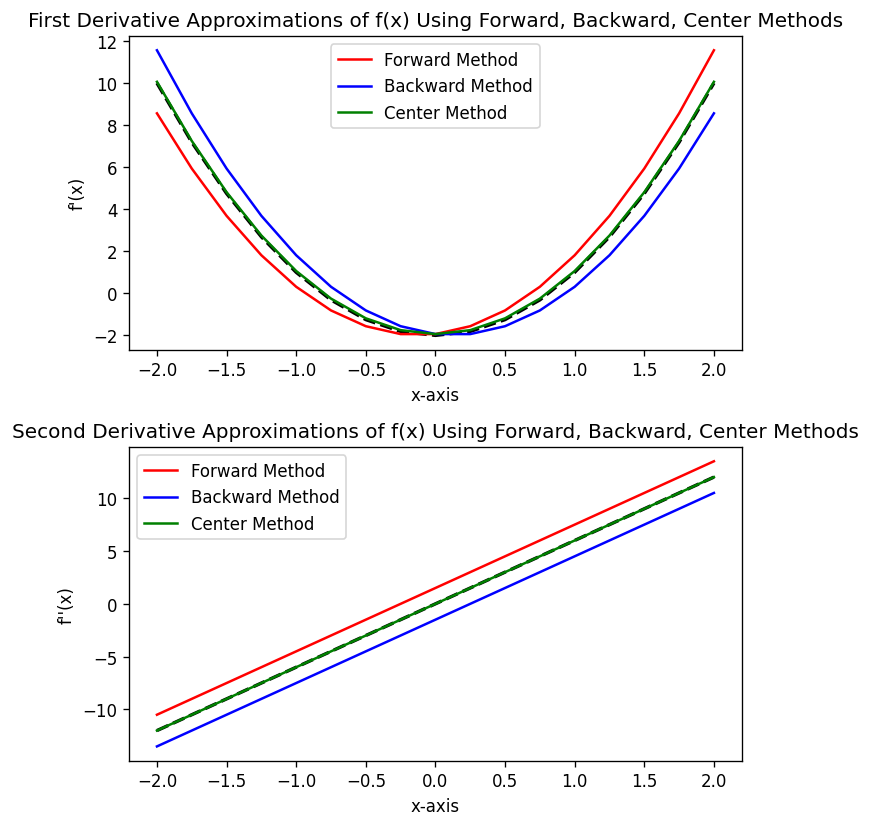

In [71]:
# Chapter 4, (4.19) PRACTICE PROBLEM:

def fun(x):
    return x**3 - 2*x + 4

def fun_prime(x):
    return 3*x**2 - 2

def fun_doubleprime(x):
    return 6*x

x_interval = np.arange(-2, 2.0001, 0.25) # .arange allows you to set the interval size: good for setting stepsizes like h
# First Order Forward FDD Formula - Error = O(dx)
# Approximation for first derivative
def first_FFD(f, x, dx):
    ffd1 = (f(x + dx) - f(x)) / (dx)
    return(ffd1)

# First Order Forward FDD Formula - Error = O(dx)
# Approximation for second derivative
def first_FFD2(f, x, dx):
    ffd_order1_deriv2 = (f(x + 2*dx) - 2*f(x + dx) + f(x)) / (dx**2)
    return(ffd_order1_deriv2)

# First Order Backward FDD Formula - Error = O(dx)
# Approximation for first derivative
def first_BFD(f, x, dx):
    bfd1 = (f(x) - f(x - dx)) / (dx)
    return(bfd1)

# First Order Backward FDD Formula - Error = O(dx)
# Approximation for second derivative
def first_BFD2(f, x, dx):
    bfd_order1_deriv2 = (f(x) - 2*f(x - dx) + f(x-2*dx)) / (dx**2)
    return(bfd_order1_deriv2)

# Second Order Center FDD Formula - Error = O(dx^2)
# Approximation for first derivative
def second_CFD1(f, x, dx):
    cfd2 = (f(x + dx) - f(x - dx)) / (2*dx)
    return(cfd2)

# Second Order Center FDD Formula - Error = O(dx^2)
# Approximation for second derivative
def second_CFD2(f, x, dx):
    cfd_order2_deriv2 = (f(x + dx) - 2*f(x) + f(x - dx)) / (dx**2)
    return(cfd_order2_deriv2)

forward_deriv1 = first_FFD(fun, x_interval, 0.25)
print("Forward First Derivative Approximations: ", forward_deriv1)

forward_deriv2 = first_FFD2(fun, x_interval, 0.25)
print("Forward Second Derivative Approximations: ", forward_deriv2)

backward_deriv1 = first_BFD(fun, x_interval, 0.25)
print("Backward First Derivative Approximations: ", backward_deriv1)

backward_deriv2 = first_BFD2(fun, x_interval, 0.25)
print("Backward Second Derivative Approximations: ", backward_deriv2)

center_deriv1 = second_CFD1(fun, x_interval, 0.25)
print("Center First Derivative Approximations: ", center_deriv1)

center_deriv2 = second_CFD2(fun, x_interval, 0.25)
print("Center Second Derivative Approximations: ", center_deriv2)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6,7), dpi=120)
ax1.plot(x_interval, fun_prime(x_interval), '--', color="black", linewidth="2")
ax1.plot(x_interval, forward_deriv1, color="red", label="Forward Method")
ax1.plot(x_interval, backward_deriv1, color="blue", label="Backward Method")
ax1.plot(x_interval, center_deriv1, color="green", label="Center Method")
ax1.set_title("First Derivative Approximations of f(x) Using Forward, Backward, Center Methods")
ax1.set_xlabel("x-axis")
ax1.set_ylabel("f'(x)")
ax1.legend()

ax2.plot(x_interval, fun_doubleprime(x_interval), '--', color="black", linewidth="2")
ax2.plot(x_interval, forward_deriv2, color="red", label="Forward Method")
ax2.plot(x_interval, backward_deriv2, color="blue", label="Backward Method")
ax2.plot(x_interval, center_deriv2, color="green", label="Center Method")
ax2.set_title("Second Derivative Approximations of f(x) Using Forward, Backward, Center Methods")
ax2.set_xlabel("x-axis")
ax2.set_ylabel("f''(x)")
ax2.legend()

plt.tight_layout()

The Center Method is clearly more accurate for both the first and second derivative based on my graphs. The reason behind its increased accuracy is because its error function is O(h^2) while the forward and backward methods have O(h). The higher the degree for O(h^b), the quicker the error will fall off. For O(h), the error falls off linearly, while for O(h^2), it falls off quadratically. 

Bisection Root Prediction: 15.922994022669624


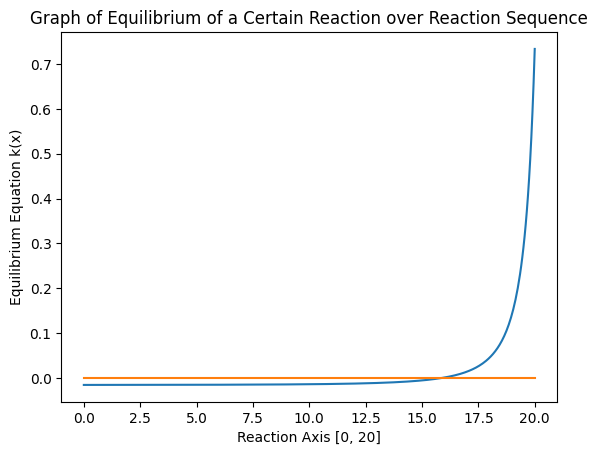

In [72]:
# Chapter 5, (5.19) PRACTICE PROBLEM:

# A reversible chemical reaction 2A + B →← C can be characterized by the 
# equilibrium relationship K = ((c_c) / (c^2_a * c_b))
# where the nomenclature ci represents the concentration of constituent i. 
# Suppose that we define a variable x as representing the number of moles of C 
# that are produced. Conservation of mass can be used to reformulate the equilibrium 
# relationship a K= ((c_(c,0) + x) / (c_(a,0)-2x)^2 * (c_(b,0) - x))
# where the subscript 0 designates the initial concentration of each constituent. 
# If K= 0.016, ca,0 = 42, cb,0 = 28, and cc,0 = 4, determine the value of x. 
# (a) Obtain the solution graphically. (b) On the basis of (a), solve for the root 
# with initial guesses of xl = 0 and xu = 20 to εs 0.5%. Choose either bisection or 
# false position to obtain your solution. Justify your choice.

# PART A:

A = 42
B = 28
C = 4
K_eq = 0.016

def k(x):
    K = (C + x) / ((A - 2*x)**2 * (B - x)) - K_eq
    return K

x_k = np.linspace(0, 20, 400)
horizontal_axis = [0]*len(x_k)
plt.plot(x_k, k(x_k))
plt.plot(x_k, horizontal_axis)
plt.xlabel("Reaction Axis [0, 20]")
plt.ylabel("Equilibrium Equation k(x)")
plt.title("Graph of Equilibrium of a Certain Reaction over Reaction Sequence")

#def false_position_method1(f, lower, upper, tol=0.005, max_iter=100):
    #for i in range(max_iter):
        #x_r = upper - (f(upper) * (lower - upper)) / (f(lower) - f(upper))

        #if np.abs(f(x_r)) < tol:
            #return x_r
        
        # Bracketed Method Condition
        #test = f(lower) * f(x_r)
        #if test < 0:
            #upper = x_r
        #else:
            #lower = x_r
    
    #return x_r


#root = false_position_method1(k, 0, 20)
#print("False Position Method 1 Root:", root)


# False Position Method is bad because the function grows exponentially and is very one-sided. 
# Therefore, Bisection Method is better.

def bisection_method1(f, lower, upper, tol=0.5, max_iter=100):

    # Checking to see if a function passes through zeros within the specified bounds
    # For there to be a zero, according to Intermediate Value Theorem, f(lower) and f(upper) must have opposite signs.
    if f(lower)*f(upper) >= 0:
        return("No roots found within bounds!")
    
    xr_old = lower

    for i in range(max_iter):
        x_r = (lower + upper)/2 # Bisection
        # test checks which subinterval contains the root

        # tolerance defined as when x_r reaches a certain error threshold in this case
        if i > 0:
            ea = np.abs((x_r - xr_old)/x_r) * 100
            if ea < tol:
                return x_r
        
        # Bracketed Method Condition
        test = f(lower) * f(x_r)
        if test < 0:
            upper = x_r
        else:
            lower = x_r

    return x_r

print(f"Bisection Root Prediction:", bisection_method1(k, 0, 20))

In [73]:
# Chapter 6 (6.7) PRACTICE PROBLEM

# Locate the first possible root of the function where x is in radians. 
# Use four iterations of the secant method with initial guesses 
# (a): x_i-1 = 1.0 and x_i = 3.0, (b): x_i-1 = 1.5 and x_i = 2.5,
# (c): x_i-1 = 1.5 and x_i = 2.25, and locate the root.

def ch6_func(x):
    return np.sin(x) + np.cos(1+x**2) - 1

def secant_method(f, x0, x1, tol=1e-6, max_iter=4):
    for i in range(max_iter):
        f0 = f(x0)
        f1 = f(x1)
        x2 = x1 - (f1*(x1 - x0)) / (f1 - f0)

        if np.abs(x2 - x1) < tol:
            return x2
        x0 = x1
        x1 = x2

    return x2


print("(a): ", secant_method(ch6_func, 1, 3), "radians")
print("(b): ", secant_method(ch6_func, 1.5, 2.5), "radians")
print("(c): ", secant_method(ch6_func, 1.5, 2.25), "radians")


(a):  0.39636577372668547 radians
(b):  2.532106931631685 radians
(c):  1.944608425569954 radians


B =  -2.473308765704634
A =  9.661785859642892
Standard Error:  0.08904445551936309
Coefficient of Determination:  0.9973557833517014


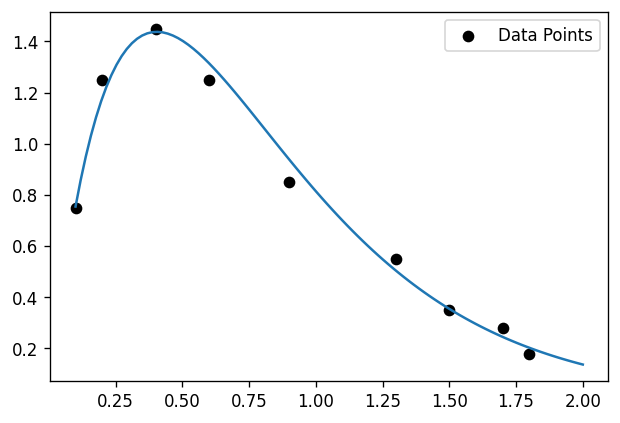

In [74]:
# Chapter 17 (17.11) PRACTICE PROBLEM


# y = A*x*e^(B*x)
def y(x, A, B):
    return A * x * np.exp(B*x)

x_data = [0.1, 0.2, 0.4, 0.6, 0.9, 1.3, 1.5, 1.7, 1.8] # length of 9
y_data = [0.75, 1.25, 1.45, 1.25, 0.85, 0.55, 0.35, 0.28, 0.18] # length of 9

x_data = np.array(x_data)
y_data = np.array(y_data)

ln_y = np.log(y_data)
# Linearized Eqn: ln_y - ln(x) = ln(A) + B*x

true_linearized_form = ln_y - np.log(x_data)

lnA, B, standard_error, r_2 = least_squares_regression(x_data, true_linearized_form)

A = np.exp(lnA)

print("B = ", B)
print("A = ", A)
print("Standard Error: ", standard_error)
print("Coefficient of Determination: ", r_2)

linear_x_data = np.linspace(0.1, 2, 100)
y_fit = y(linear_x_data, A, B)


fig, ax1 = plt.subplots(figsize=(6, 4), dpi=120)
ax1.scatter(x_data, y_data, color="black", label="Data Points")
ax1.plot(linear_x_data, y_fit)
ax1.legend();



B =  0.4994357194994672
A =  2.1729168344126504
Standard Error:  0.01094822257755831
Coefficient of Determination:  0.9999528591068664


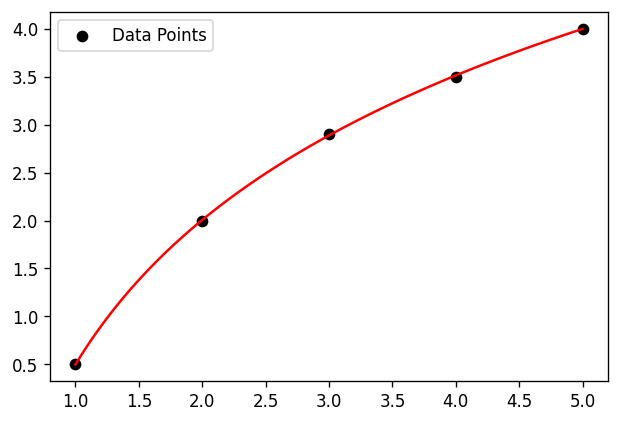

In [75]:
# Chapter 17 (17.13) PRACTICE PROBLEM

# x = e^((y - b)/a)

x_data = [1, 2, 3, 4, 5] # 5 values
y_data = [0.5, 2, 2.9, 3.5, 4] # 5 values

x_data = np.array(x_data)
y_data = np.array(y_data)

def x(y, A, B):
    return np.exp((y - B)/A)

# Linearized Form: y = A*lnx + B
lnx = np.log(x_data)


B, A, standard_error, r_2 = least_squares_regression(lnx, y_data)

linear_eqn = A * lnx + B

print("B = ", B)
print("A = ", A)
print("Standard Error: ", standard_error)
print("Coefficient of Determination: ", r_2)

x_fit = np.linspace(min(x_data), max(x_data), 100)
y_fit = A * np.log(x_fit) + B

fig, ax1 = plt.subplots(figsize=(6, 4), dpi=120)
ax1.scatter(x_data, y_data, color="black", label="Data Points")
ax1.plot(x_fit, y_fit, color = "red")
ax1.legend();

In [76]:
# Chapter 23 (23.9) PRACTICE PROBLEM

# Use numerical differentiation to estimate the rocket’s velocity 
# and acceleration at each time.

t = [0, 25, 50, 75, 100, 125] # length 6
y = [0, 32, 58, 78, 92, 100] # length 6

t = np.array(t)
y= np.array(y)

# First Derivative, Second Order (O(h^2) error)
def deriv1_central(x, y):
    h = x[1] - x[0] #stepsize
    x_dydx = x[1:-1] # Central Method lives on all x values except the first and last one
    # (f(x_i+1) - f(x_i-1))/2h
    return ((y[2:] - y[:-2]) / (2*h))

# Second Derivative, Second Order (O(h^2) error)
def deriv2_central(x, y):
    h = x[1] - x[0] #stepsize
    x_d2ydx2 = x[1:-1] # Central Method lives on all x values except the first and last one
    # (f(x_i+1) - 2f(x_i)+f(x_i-1))/h^2
    return ((y[2:] - 2*y[1:-1] + y[:-2]) / h**2)

print("Central Method for 1st Derivative (Rocket Velocity): ", deriv1_central(t, y), "km/s")
print("Central Method for 2nd Derivative (Rocket Acceleration): ", deriv2_central(t, y), "km/s^2")

Central Method for 1st Derivative (Rocket Velocity):  [1.16 0.92 0.68 0.44] km/s
Central Method for 2nd Derivative (Rocket Acceleration):  [-0.0096 -0.0096 -0.0096 -0.0096] km/s^2


Flow rate per specified time:  [4.  7.7]


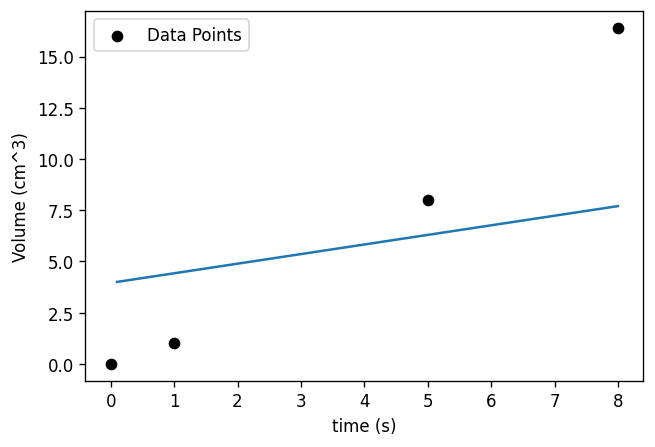

In [77]:
# Chapter 23 (23.25) PRACTICE PROBLEM

t = [0, 1, 5, 8] # len = 4
V = [0, 1, 8, 16.4] # len = 4


t = np.array(t)
V = np.array(V)

# Estimate the bucket's flow rate at x=7 seconds

# Flow rate is the first derivative of volume*

# First Derivative, Second Order (O(h^2) error)
def deriv1_central(x, y):
    h = x[1] - x[0] #stepsize
    x_dydx = x[1:-1] # Central Method lives on all x values except the first and last one
    # (f(x_i+1) - f(x_i-1))/2h
    return ((y[2:] - y[:-2]) / (2*h))

print("Flow rate per specified time: ", deriv1_central(t, V))

t_line = np.linspace(0.1, 8, 2)

fig, ax1 = plt.subplots(figsize=(6, 4), dpi=120)
ax1.scatter(t, V, color="black", label="Data Points")
ax1.plot(t_line, deriv1_central(t, V))
ax1.set_xlabel("time (s)")
ax1.set_ylabel("Volume (cm^3)")
ax1.legend()



## Essential Terms and Identifiable Characteristics

**1. `scipy.stats.linregress`**  
A Python function from the scipy library used for linear regression.  

**2. `scipy.optimize.linprog`**  
A Python function from the scipy library used for Simplex method optimization.  

**3. `scipy.optimize.root_scalar`**  
A Python function from the scipy library used to solve \(f(x) = 0\).  

**4. `scipy.optimize.curve_fit`**  
A Python function from the scipy library used for non-linear regression.  

**5. `scipy.optimize.minimize`**  
A Python function from the scipy library used for general-purpose unconstrained or constrained minimization of scalar functions.  

**6. `scipy.integrate.solve_bvp`**  
A method for solving boundary value problems.  

**7. `scipy.integrate.RK45`**  
A method for integrating initial value problems with \(O(h)\) global error.  

**8. `scipy.linalg.solve`**  
A Python function from the scipy library used for solving systems of linear equations.  

**9. `scipy.linalg.lu`**  
A Python function from the scipy library that decomposes a square matrix into lower and upper triangular matrices for easier solving of linear systems.  

**10. Absolute Error**  
The difference between an approximate value and the exact value, reported as a raw number.  

**11. Relative Error**  
A type of error reported as a percentage.  

**12. Approximate Error**  
The difference between successive approximations in an iterative process, used to judge convergence.  

**13. Truncation Error**  
A source of error that arises due to the limited number of terms used in a Taylor series.  

**14. Roundoff Error**  
A source of error that arises due to the limited precision of numbers stored in a computer.  

**15. Taylor Series**  
A series expansion that represents a function as a sum of its derivatives at a point.  

**16. Initial Value Problem**  
A differential equation problem where the solution is computed from a given starting value.  

**17. Boundary Value Problem**  
A differential equation problem where the solution is constrained at two or more points.  

**18. Stiff system**  
A class of differential equations which exhibits a very rapid initial response, and which can cause many numerical integration methods to be unstable.  

**19. Linear Programming**  
A class of optimization problems that solved using the Simplex algorithm.  

**20. First Forward finite-divided difference**  
A numerical derivative approximation using the function value at a point and the next point only.  

**21. First Central finite-divided difference**  
A method for calculating the first derivative with an error that scales as \(O(h^2)\).  

**22. Trapezoidal Rule**  
A method of numerical integration that approximates the integrand using a series of linear interpolants.  

**23. Simpson’s 1/3 Rule**  
A method of numerical integration that approximates the integrand using a series of parabolic interpolants.  

**24. Gaussian Quadrature**  
A numerical integration method that evaluates the integrand at optimally chosen points for high accuracy.  

**25. Euler’s method**  
A method for integrating initial value problems with \(O(h)\) global error.  

**26. Huen’s method**  
A predictor-corrector method for ODEs that averages the slope at the start and predicted end of a step.  

**27. Runge-Kutta**  
A method for integrating initial value problems with \(O(h)\) global error.  

**28. Shooting method**  
A method for solving boundary value problems.  

**29. Gauss-Seidel method**  
A method for solving systems of linear equations.  

**30. Newton-Raphson method**  
An iterative method for finding roots of a function that uses both the function value and its derivative at each step to converge quickly.

**31. Gradient (steepest) descent**  
A local optimization method that mimics the way water flows downhill.  

**32. Golden section search**  
A bracketed method for numerical optimization.  

**33. Powell’s method**  
A derivative-free optimization method that searches along conjugate directions to minimize a function.  

**34. Least Squares**  
A Python function from the scipy library used to fit a linear model by minimizing the sum of squared differences between observed and predicted values. 

**35. Richardson’s Extrapolation**  
A technique for improving the accuracy of a numerical solution by combining results computed with different step sizes to cancel leading-order error terms. 

**36. Romberg Integration**  
A method for increasing the accuracy of a numerical integral, if integrations for two or more step sizes are already computed.  

**37. LU decomposition**  
A method for solving systems of linear equations.  

**38. Gaussian Elimination**  
A method for solving systems of linear equations.  

**39. Random Search**  
A global optimization method that is particularly ineffective for high-dimension objective functions.  

**40. Simulated Annealing**  
A stochastic global optimization method that probabilistically accepts worse solutions early on to escape local minima, inspired by the annealing process in metallurgy.

**1. `scipy.stats.linregress`**  
A Python function from the scipy library used for linear regression.  
- Performs linear regression using the least-squares method.  
- Returns slope, intercept, r-value, p-value, and standard error.  
- Assumes a linear relationship between two variables.  
- Computational complexity: O(n), where n is the number of data points.  
- Sensitive to outliers; only fits one independent variable.  

**2. `scipy.optimize.linprog`**  
A Python function from the scipy library used for Simplex method optimization.  
- Solves linear programming problems with constraints of the form Ax ≤ b, A_eq x = b_eq, and variable bounds.  
- Can use the Simplex method or interior-point method.  
- Efficient for small to medium-sized problems; large-scale problems may require interior-point.  
- Objective function must be linear.  
- Returns optimized variable values, optimal objective, and status of solution.  

**3. `scipy.optimize.root_scalar`**  
A Python function from the scipy library used to solve f(x) = 0.  
- Finds a root of a scalar function.  
- Supports bracketing methods (e.g., bisection) and open methods (e.g., Newton-Raphson, secant).  
- Requires either a bracket containing the root or an initial guess.  
- Convergence depends on method: Newton-Raphson is fast but requires derivative.  
- Raises error if root is not bracketed or convergence fails.  

**4. `scipy.optimize.curve_fit`**  
A Python function from the scipy library used for non-linear regression.  
- Fits a function y = f(x, params) to data using non-linear least squares.  
- Returns optimal parameters 
- Sensitive to initial guesses for parameters.  
- Minimizes sum of squares of residuals: Σ_i (y_i - f(x_i, params))^2.  

**5. `scipy.optimize.minimize`**  
A Python function from the scipy library used for general-purpose unconstrained or constrained minimization of scalar functions.  
- Supports bounds and constraints (linear and nonlinear).  
- Multiple algorithms available: BFGS, Nelder-Mead, Powell, etc.  
- Gradient-based methods converge faster; derivative-free methods are slower but flexible.  
- Returns final objective value, optimized variables, and convergence status.  
- Can handle multi-dimensional scalar functions.  

**6. `scipy.integrate.solve_bvp`**  
A Python function from the scipy library used to solve boundary value problems for ODEs.  
- Solves y'' = f(x, y, y') with boundary conditions at two or more points.   
- Iteratively refines mesh until solution tolerance is met.  
- Returns solution object with y and y' at mesh points.  
- Can handle systems of ODEs and non-linear problems.  

**7. `scipy.integrate.RK45`**  
A method for integrating initial value problems with O(h) global error.  
- Explicit Runge-Kutta method of order 5 with adaptive step size.  
- Error per step: O(h^5); global error: O(h^4).  
- Good for non-stiff initial value problems.  
- Automatically adjusts step size based on error tolerance.  
- Can solve systems of ODEs efficiently.  

**8. `scipy.linalg.solve`**  
A Python function from the scipy library used for solving systems of linear equations.  
- Solves Ax = b using direct methods.  
- Handles multiple right-hand sides simultaneously.  
- Computational complexity: O(n^3) for dense n × n matrices.  
- Returns exact solution (subject to roundoff errors).  
- Stable for well-conditioned matrices.  

**9. `scipy.linalg.lu`**  
A Python function from the scipy library that decomposes a square matrix into lower and upper triangular matrices for easier solving of linear systems.  
- Decomposes A into P L U, where P is a permutation matrix.  
- Pivoting improves numerical stability.  
- Can be used to solve Ax = b via forward/backward substitution.  
- Complexity: O(n^3) for an n × n matrix.  
- Also useful for computing determinants.  

**10. Absolute Error**  
The difference between an approximate value and the exact value, reported as a raw number.  
- Defined as |x_approx - x_exact|.  
- Simple measure of accuracy; does not account for scale of value.  
- Always non-negative.  
- Useful for comparing numerical approximations in iterative methods.  
- Can be used in stopping criteria for iterative methods.  

**11. Relative Error**  
A type of error reported as a percentage.  
- Defined as Relative Error = |x_approx - x_exact| / |x_exact| × 100%.  
- Measures error relative to the size of the exact value.  
- Useful for comparing errors of numbers with different magnitudes.  
- Always non-negative.  
- Often used as a stopping criterion in iterative methods.  

**12. Approximate Error**  
The difference between successive approximations in an iterative process, used to judge convergence.  
- Defined as |x_new - x_old|.  
- Gives an estimate of how close the iteration is to the true solution.  
- Smaller approximate error indicates better convergence.  
- Often expressed as a percentage.  
- Can be used to terminate iterative methods when a tolerance is reached.  

**13. Truncation Error**  
A source of error that arises due to the limited number of terms used in a Taylor series.  
- Caused by ignoring higher-order terms in a series expansion.  
- Error order depends on the method (e.g., O(h) for Euler, O(h^2) for improved methods).  
- Decreases as step size or series order increases.  
- Important in numerical differentiation and integration.  
- Often estimated using the next term in the series.  

**14. Roundoff Error**  
A source of error that arises due to the limited precision of numbers stored in a computer.  
- Caused by representing numbers with finite floating-point precision.  
- Can accumulate in iterative calculations.  
- Can sometimes dominate truncation error in very small step sizes.  
- Typically bounded by machine epsilon (~10^-16 for double precision).  
- Important to monitor in large matrix computations or long iterative processes.  

**15. Taylor Series**  
A series expansion that represents a function as a sum of its derivatives at a point.  
- f(x) ≈ f(a) + f'(a)(x-a) + f''(a)(x-a)^2 / 2! + ...  
- Basis for many numerical methods (differentiation, integration, ODE solvers).  
- Error is determined by truncation after a finite number of terms.  
- Higher-order expansions give better accuracy near the expansion point.  
- Often used to derive finite difference formulas.  

**16. Initial Value Problem**  
A differential equation problem where the solution is computed from a given starting value.  
- General form: dy/dx = f(x, y), with y(x0) = y0.  
- Solved by marching forward from the initial condition.  
- Euler, Huen, and Runge-Kutta methods are commonly applied.  
- Error depends on step size and method order.  
- Requires only one point of initial data to start the solution.  

**17. Boundary Value Problem**  
A differential equation problem where the solution is constrained at two or more points.  
- General form: y'' = f(x, y, y'), with y(a) = alpha, y(b) = beta.  
- Cannot be solved by simple forward integration.  
- Methods include shooting method and collocation (solve_bvp).  
- Often more sensitive to initial guesses than IVPs.  
- Typically requires iterative or matrix-based solution techniques.  

**18. Stiff system**  
A class of differential equations which exhibits a very rapid initial response, and which can cause many numerical integration methods to be unstable.  
- Characterized by widely varying timescales.  
- Explicit methods (Euler, RK45) may require very small step sizes.  
- Implicit methods are more stable for stiff systems.  
- Common in chemical kinetics and control systems.  
- Detecting stiffness is important to choose appropriate solver.  

**19. Linear Programming**  
A class of optimization problems that solved using the Simplex algorithm.  
- Objective function is linear: maximize or minimize c^T x.  
- Subject to linear constraints: Ax ≤ b or Ax = b, with bounds on x.   
- Optimal solution occurs at a vertex of the feasible region.  
- Solved using Simplex or interior-point methods.  

**20. First Forward finite-divided difference**  
A numerical derivative approximation using the function value at a point and the next point only.  
- Formula: f'(x_i) ≈ (f(x_i+1) - f(x_i)) / h.  
- Error is O(h), first-order accurate.  
- Simple to implement and computationally cheap.  
- Requires uniform step size h.  
- Less accurate than central difference but only needs forward points. 
- Cannot be applied at the last point of the interval because f(x_i+1) would be undefined.

**21. First Central finite-divided difference**  
A method for calculating the first derivative with an error that scales as O(h^2).  
- Formula: f'(x_i) ≈ (f(x_i+1) - f(x_i-1)) / (2h).  
- Second-order accurate (error is O(h^2)), more precise than forward difference.  
- Requires function values at points before and after x_i.  
- Computationally cheap for uniform grids.  
- Commonly used in numerical differentiation for smoother approximations. 
- Cannot be applied at the first or last points of the interval because f(x_i-1) or f(x_i+1) would be undefined. 

**22. Trapezoidal Rule**  
A method of numerical integration that approximates the integrand using a series of linear interpolants.  
- Integral approximation: ∫_a^b f(x) dx ≈ h/2 * [f(a) + 2 Σ f(x_i) + f(b)].  
- Error is O(h^2), decreases with smaller step size h.  
- Easy to implement; works for equally spaced points.  
- Can be extended to composite form for multiple intervals.  
- Provides a balance between simplicity and accuracy for smooth functions.  

**23. Simpson’s 1/3 Rule**  
A method of numerical integration that approximates the integrand using a series of parabolic interpolants.  
- Formula for one interval: ∫_a^b f(x) dx ≈ h/3 * [f(a) + 4f((a+b)/2) + f(b)].  
- Error is O(h^4), more accurate than trapezoidal rule for smooth functions.  
- Requires an even number of intervals for composite form.  
- Uses parabolic approximation, capturing curvature better than linear.  
- Widely used in engineering and physics for definite integrals.  

**24. Gaussian Quadrature**  
A numerical integration method that approximates an integral using specially chosen nodes and weights, providing very high accuracy for polynomials up to a certain degree.  
- Formula: ∫_a^b f(x) dx ≈ Σ w_i f(x_i), where x_i and w_i are chosen optimally.  
- Can integrate polynomials exactly up to degree 2n-1 with n nodes.  
- Very efficient; fewer points needed for high accuracy compared to trapezoidal or Simpson’s.  
- Weights and nodes depend on the type of orthogonal polynomial (e.g., Legendre).  
- Particularly useful for integrals with smooth functions.  

**25. Euler’s method**  
A method for integrating initial value problems with O(h) global error.  
- Formula: y_{i+1} = y_i + h * f(x_i, y_i).  
- First-order method, simple to implement.  
- Error is proportional to step size h (O(h) global error).  
- Can be unstable for stiff systems.  
- Basis for more advanced predictor-corrector methods.  

**26. Huen’s method**  
A predictor-corrector method for ODEs that averages the slope at the start and predicted end of a step.  
- Predictor: y_p = y_i + h * f(x_i, y_i).  
- Corrector: y_{i+1} = y_i + h/2 * [f(x_i, y_i) + f(x_{i+1}, y_p)].  
- Second-order accurate, error O(h^2).  
- More stable and accurate than Euler’s method.  
- Useful for solving non-stiff initial value problems.  

**27. Runge-Kutta**  
- Classical RK4 method: 4-stage method with fourth-order accuracy (O(h^4) global error).  
- Combines multiple slope evaluations to improve accuracy.  
- Does not require derivative of derivative (unlike Taylor series methods).  
- Accurate and simple.  
- Can be applied to systems of ODEs.  

**28. Shooting method**  
A method for solving boundary value problems.  
- Converts BVP into an initial value problem.  
- Iteratively adjusts initial conditions to meet boundary conditions at the other end.  
- Can be combined with RK or other IVP solvers.  
- Sensitive to initial guesses; may require multiple iterations.  
- Effective for linear and non-linear BVPs.  

**29. Gauss-Seidel method**  
A method for solving systems of linear equations.  
- Iterative method updating each variable in sequence using the latest values.  
- Convergence requires matrix to be diagonally dominant or symmetric positive definite.  
- Error decreases with each iteration; can be stopped when approximate error tolerance is met.  
- Computational complexity: O(n^2) per iteration for dense n × n matrices.  
- Often used when direct methods are expensive for large sparse systems.  

**30. Newton-Raphson method**  
An iterative method for finding roots of a function that uses both the function value and its derivative at each step to converge quickly.  
- Formula: x_{n+1} = x_n - f(x_n)/f'(x_n).  
- Quadratic convergence near the root if initial guess is close.  
- Requires derivative of the function.  
- Can fail or diverge if f'(x_n) ≈ 0 or initial guess is poor.  
- Commonly used in solving non-linear equations numerically.  

**31. Gradient (steepest) descent**  
A local optimization method that mimics the way water flows downhill.  
- Iteratively updates variables in the direction of the negative gradient.  
- Formula: x_{k+1} = x_k - α ∇f(x_k), where α is the step size.  
- Convergence is linear; may be slow near shallow minima.  
- Can get trapped in local minima for non-convex functions.  
- Requires computation of the gradient at each step.  

**32. Golden section search**  
A bracketed method for numerical optimization.  
- Minimizes or maximizes a function within a specified interval without derivatives.  
- Uses the golden ratio to reduce interval size efficiently.  
- Converges linearly but is robust and simple.  
- Particularly useful for unimodal functions.  
- Does not require derivative information.  

**33. Powell’s method**  
A derivative-free optimization method that searches along conjugate directions to minimize a function.  
- Does not require gradient information.  
- Updates search directions iteratively to approximate conjugate directions.  
- Effective for smooth, unconstrained problems.  
- Convergence faster than random search but slower than gradient methods.  
- Can be used in multi-dimensional optimization.  

**34. Least Squares**  
A Python function from the scipy library used to fit a linear model by minimizing the sum of squared differences between observed and predicted values.  
- Minimizes the sum of squared residuals: Σ_i (y_i - y_pred_i)^2.  
- Returns best-fit parameters for linear or simple models.  
- Can be extended to multiple regression.  
- Sensitive to outliers.  
- Basis for many curve-fitting and regression applications.  

**35. Richardson’s Extrapolation**  
A technique for improving the accuracy of a numerical solution by combining results computed with different step sizes to cancel leading-order error terms.  
- Uses solutions at h and h/2 (or other ratios) to improve estimate.  
- Can be applied to differentiation or integration.  
- Error order increases compared to base method.  
- Reduces truncation error systematically.  
- Useful for constructing higher-order methods from lower-order formulas.  

**36. Romberg Integration**  
A method for increasing the accuracy of a numerical integral, if integrations for two or more step sizes are already computed.  
A method of numerical integration that systematically applies Richardson’s extrapolation to trapezoidal rule estimates to achieve high-precision results.  
- Uses a recursive table of trapezoidal approximations.  
- Error decreases rapidly with each extrapolation step.  
- Very efficient for smooth functions.  
- Can achieve high-order accuracy without additional function evaluations.  
- Particularly useful when function evaluations are expensive.  

**37. LU decomposition**  
A method for solving systems of linear equations.  
- Decomposes matrix A into L (lower) and U (upper) triangular matrices.  
- Can solve Ax = b by forward and backward substitution.  
- Pivoting improves numerical stability.  
- Computational complexity: O(n^3) for dense n × n matrices.  
- Often used as a pre-processing step for multiple right-hand sides.  

**38. Gaussian Elimination**  
A method for solving systems of linear equations.  
- Systematically eliminates variables to reduce matrix to upper triangular form.  
- Back substitution gives the solution.  
- Pivoting improves numerical stability.  
- Computational complexity: O(n^3) for dense matrices.  
- Can be applied to any square system of linear equations.  

**39. Random Search**  
A global optimization method that randomly samples the search space and selects the best solution, generally inefficient for high-dimensional problems.  
- Does not require derivative information.  
- Performance degrades rapidly as dimensionality increases.  
- Simple to implement.  
- Useful for rough, global exploration or very noisy functions.  
- Often combined with local search methods for refinement.  

**40. Simulated Annealing**  
A stochastic global optimization method that probabilistically accepts worse solutions early on to escape local minima, inspired by the annealing process in metallurgy.  
- Uses a “temperature” parameter to control probability of accepting worse solutions.  
- Cooling schedule affects convergence speed and quality.  
- Can escape local minima unlike steepest descent.  
- Effective for discrete or combinatorial optimization problems.  
- Computationally more expensive than local methods but can find near-global optima.

<a id="debugging"></a>
## Debugging Checklist

| Error / Bug | Cause | Quick Fix / Debug Tip |
|------------|-------|----------------------|
| SyntaxError | Missing colon, parentheses mismatch, wrong indentation | Check line number. Use auto-formatting in VS Code (`Shift+Alt+F`). Ensure correct indentation. |
| NameError | Variable or function name not defined | Ensure variable/function is declared before use. Watch for typos and capitalization. |
| TypeError | Using wrong data types (e.g., string + float) | Check types with `type()`. Convert if needed, e.g., `float(x)`. |
| IndexError | Accessing array/list out of bounds | Print `len(array)` and the index. Ensure loops do not overshoot array size. |
| ValueError | Wrong shape of arrays or invalid values | Check `.shape` of arrays. Ensure function signatures match expected input (1D vs 2D). |
| Overflow / Underflow | Exponentials or very small numbers | Scale variables. Use `np.exp`, `np.log` carefully. Avoid extremely small step sizes in ODEs. |
| Floating-point / Roundoff | Comparing floats for equality, tiny errors accumulate | Use tolerance-based checks: `abs(a-b) < 1e-12`. |
| Infinite loop | Loop stopping condition not met | Print iteration counts. Use a `max_iter` cap as fail-safe. |
| Non-convergence in iterative methods | Step size too large or poor initial guess | Reduce step size, improve initial guess, monitor approximate/relative error. |
| Wrong output dimensions | Matrix/vector operations misaligned | Use `.reshape()`, `.T`, or `.flatten()` to fix shapes. Print shapes to debug. |
| Library function misuse | Using functions like `solve_bvp`, `curve_fit` incorrectly | Verify function signature, initial guesses, bounds. Check official scipy examples. |
| Logical errors (method misapplied) | Algorithm implemented incorrectly | Print intermediate values (derivative arrays, matrix after LU). Step through manually with small test cases. |

## Methods "By Hand"

## Practice Final



(5 pts) Plot f(T)=−0.05T3+0.8T-
3
T
+
5
f(T)=−0.05T 
3
 +0.8T 
2
 −3T+5 for 
T
∈
[
0
,
10
]
T∈[0,10]. Identify intervals where the slope is positive/negative.

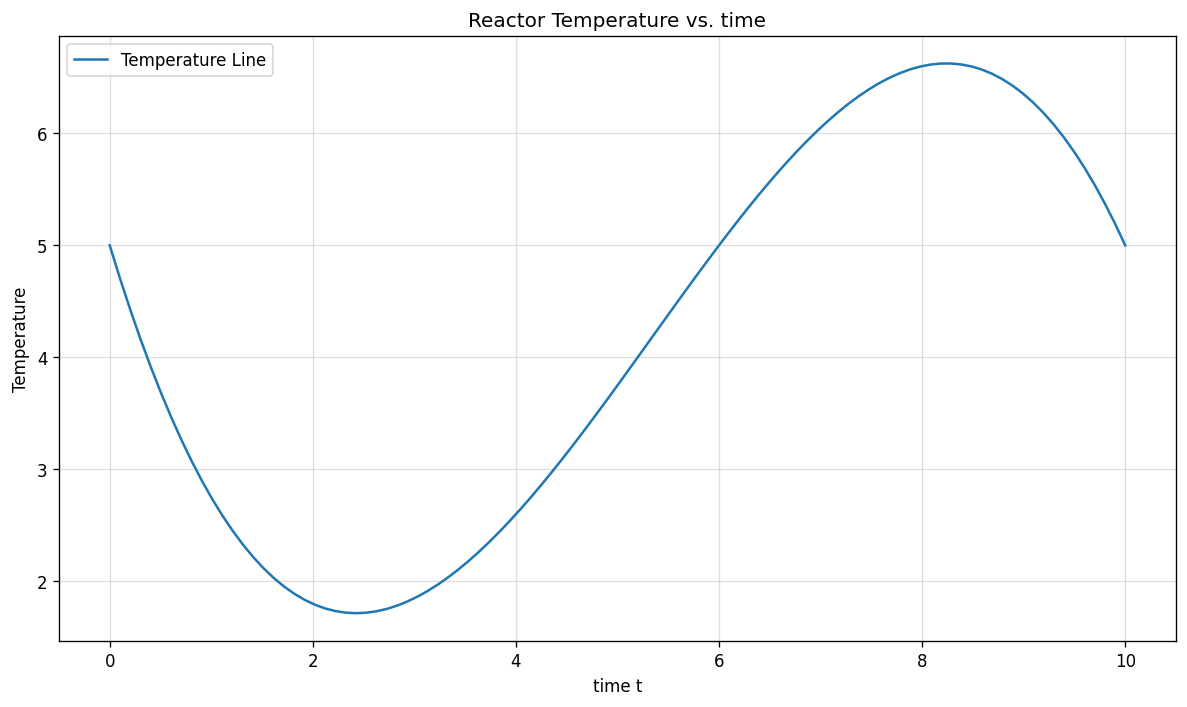

In [175]:
def dT_dt(T):
    return -0.05*T**3 +0.8*T**2 - 3*T + 5

t = np.linspace(0, 10, 100)

plt.figure(figsize=(10, 6), dpi=120)
plt.plot(t, dT_dt(t), label="Temperature Line")
plt.xlabel("time t")
plt.ylabel("Temperature")
plt.title("Reactor Temperature vs. time")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()

In [174]:
t = np.linspace(0, 10, 10)

def d2T_dt2(T):
    return -0.15*T**2 + 1.6*T - 3

negative_list = []
positive_list = []

for i in range(len(t)):
    if d2T_dt2(i) < 0:
        negative_list.append(i)
    else:
        positive_list.append(i)

print("Intervals where slope is negative:", np.array(negative_list))
print("Intervals where slope is positive:", np.array(positive_list))


Intervals where slope is negative: [0 1 2 9]
Intervals where slope is positive: [3 4 5 6 7 8]


(6 pts) Find all real roots of
f(T)=0 using both bisection and Newton-Raphson. Compare iterations needed.

In [176]:
# There should just be one root based on the graph around 11

def bisection(f, lower, upper, tol=1e-6, max_iter=100):

    # Checking to see if a function passes through zeros within the specified bounds
    # For there to be a zero, according to Intermediate Value Theorem, f(lower) and f(upper) must have opposite signs.
    if f(lower)*f(upper) >= 0:
        return("No roots found within bounds!")
    
    for i in range(max_iter):
        x_r = (lower + upper)/2 # Bisection
        # test checks which subinterval contains the root

        if np.abs(f(x_r)) < tol:
            return x_r
        
        # Bracketed Method Condition
        test = f(lower) * f(x_r)
        if test < 0:
            upper = x_r
        else:
            lower = x_r

    return x_r
# -----------------------------------------------------------------------------------------------------------------------------
# Must define a function for it to look through

def dT_dt(T):
    return -0.05*T**3 +0.8*T**2 - 3*T + 5

print(f"Version 1 Bisection Root Prediction:", bisection(dT_dt, 0, 30))



# -----------------------------------------------------------------------------------------------------------------------------



def newton_raphson_method(guess, max_iter):

    # Example Function
    def dT_dt(T):
        return -0.05*T**3 +0.8*T**2 - 3*T + 5
    
    def d2T_dt2(T):
        return -0.15*T**2 + 1.6*T - 3
    
    count = 0
    iterable_guess = []
    while count < max_iter:
        #oldguess is x_i in terms of the N_R Equation, stores previous guess
        oldguess = guess
        new = oldguess - (dT_dt(oldguess) / d2T_dt2(oldguess)) #Newton-Raphson Formula
        guess = new
        iterable_guess.append(new) #storing current guess
        count += 1 #update iteration counter

    return guess, iterable_guess

# -----------------------------------------------------------------------------------------------------------------------------
    
print("Newton-Raphson Method at Root 1: ", newton_raphson_method(11, 100)[0])

Version 1 Bisection Root Prediction: 11.557065546512604
Newton-Raphson Method at Root 1:  11.557065569592657


- Both answers are close to my prediction and make sense based on the graph.

(6 pts) Use Runge-Kutta 4 to integrate T(t) from
T(0)=2 s over 0 ≤ t ≤ 20 s with Δt = 0.5 s. Plot T(t).

[ 2.          2.87164304  3.91327487  5.5974644   8.49966021 10.85627787
 11.26754727 11.42379018 11.49482443 11.52801557 11.54353522 11.5507725
 11.55414081 11.55570676 11.5564344  11.55677241 11.55692941 11.55700233
 11.5570362  11.55705193 11.55705923 11.55706263 11.5570642  11.55706493
 11.55706527 11.55706543 11.55706551 11.55706554 11.55706556 11.55706556
 11.55706557 11.55706557 11.55706557 11.55706557 11.55706557 11.55706557
 11.55706557 11.55706557 11.55706557 11.55706557 11.55706557]


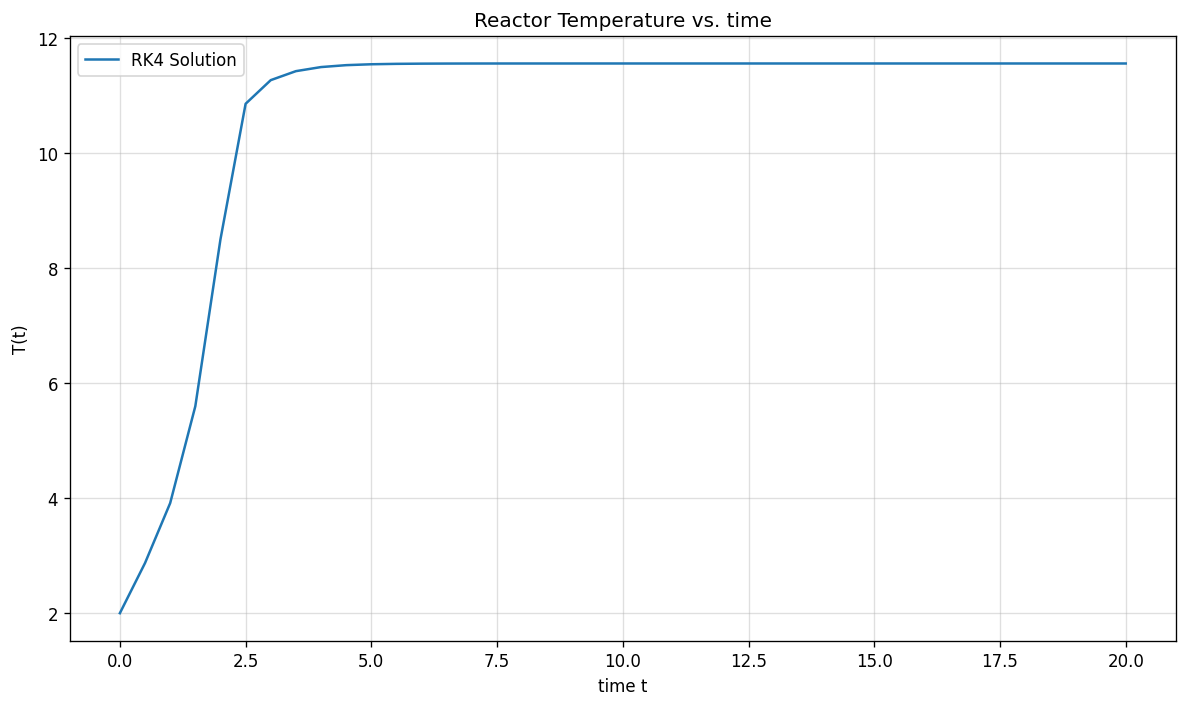

In [181]:
# RK4: y_i+1 = y_i + 1/6(k1 + 2*k2 + 2*k3 + k4)*h

def RK4(f, T0, t):
    # initializing a list of h values
    T_vals = [T0]
    T = T0
    dt = t[1] - t[0] # time stepsize = 0.5
    for i in range(1, len(t)):
        k1 = f(T) # slope at beginning of interval
        k2 = f(T + (dt/2*k1))
        k3 = f(T + (dt/2*k2))
        k4 = f(T + (dt*k3)) # slope at end of interval
        T = T + (dt/6)*(k1 + 2*k2 + 2*k3 + k4) # recalculate h values with avg slope
        T_vals.append(T)
    T_vals = np.array(T_vals)
    return T_vals
T0 = 2
t = np.linspace(0, 20, 41)

print(RK4(dT_dt, 2, t))
solver = RK4(dT_dt, T0, t)

plt.figure(figsize=(10, 6), dpi=120)
plt.plot(t, solver, label="RK4 Solution")
plt.xlabel("time t")
plt.ylabel("T(t)")
plt.title("Reactor Temperature vs. time")
plt.legend()
plt.grid(alpha=0.4)
plt.tight_layout()


(5 pts) Determine which equilibria are stable by examining the sign of 
f
′
(
T
)
f 
′
 (T) at the roots

In [ ]:
negative_list = []
positive_list = []
T_t = RK4(2, t)

for i in range(len(t)):
    if T_t(i) < 0:
        negative_list.append(i)
    else:
        positive_list.append(i)

### Final Practice Problem 2

$$ \frac{d^2 T}{dx^2} + \alpha(T-T_a) + \beta T^3 = q(x) $$

Solved into a system of ODES:

$$ y_1' = y_2 $$

$$ y_2' = q(x) - \alpha(T-T_a) - \beta T^3 $$



In [212]:
alpha = 2
beta = 0.01
Ta = 20

def q(x):
    return 5*np.sin(3*x)

def rod_system(x, y):
    y1, y2 = y
    # define ODES:
    dy1_dx = y2
    dy2_dx = q(x) - alpha*(y1-Ta) - beta*y1**3
    return np.vstack((dy1_dx, dy2_dx))


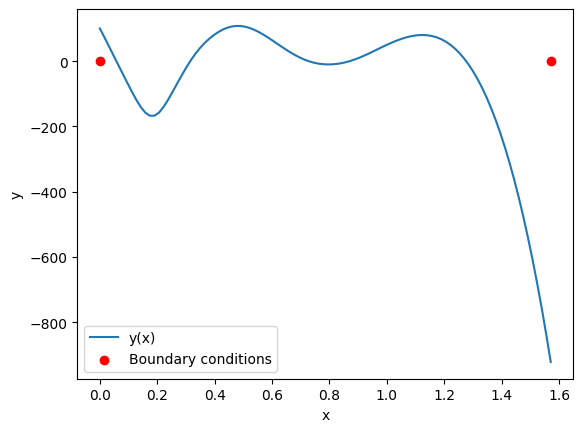

In [213]:
# 2. Define boundary conditions
def bc(ya, yb):
    return np.array([ya[0]-100, yb[0]-50])

# 3. Provide an initial mesh and guess
x = np.linspace(0, 1, 40)
y_guess = np.zeros((2, x.size))  # 2 rows for y0, y1

# 4. Solve the BVP
sol = solve_bvp(rod_system, bc, x, y_guess)

# 5. Evaluate solution
x_plot = np.linspace(0, np.pi/2, 100)
y_plot = sol.sol(x_plot)[0]

# 6. Plot
plt.plot(x_plot, y_plot, label='y(x)')
plt.scatter([0, np.pi/2], [0, 1], color='red', label='Boundary conditions')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Contour Plots:

In [205]:
# 1. Create a 3D meshgrid
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = np.sin(np.sqrt(X**2 + Y**2))

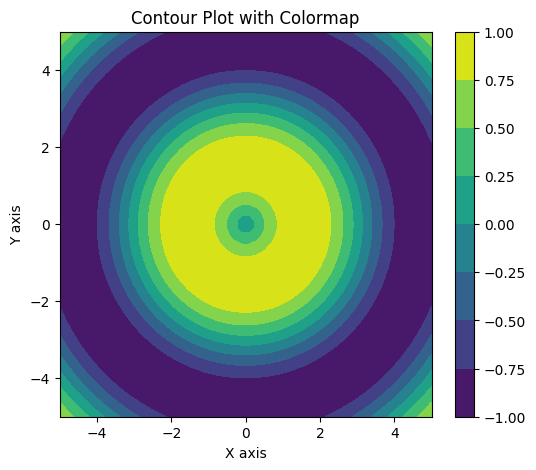

In [206]:
# 2. Create a contour plot
plt.figure(figsize=(6,5))
contour = plt.contourf(X, Y, Z, cmap='viridis')  # Colormap 'viridis'
plt.colorbar(contour)
plt.title("Contour Plot with Colormap")
plt.xlabel("X axis")
plt.ylabel("Y axis")
plt.show()

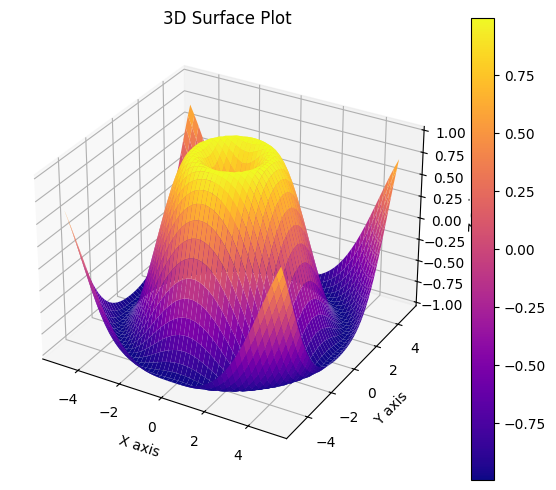

In [207]:
# 3. 3D surface plot
fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z, cmap='plasma')  # Another colormap
fig.colorbar(surf)
ax.set_title("3D Surface Plot")
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
ax.set_zlabel("Z axis")
plt.show()